In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy import stats
import s3_utils

plt.rcParams.update({
    "figure.figsize": (7.0, 3.0),
    "figure.dpi": 300,
    "font.family": "serif",
    "font.size": 9,
    "axes.labelsize": 10,
    "axes.titlesize": 11,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "lines.linewidth": 1.2,
    "text.usetex": False,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.05,
})

FIGURES = {}

DLA_COLORS = sns.color_palette("tab10", 5)
FULL_COLOR = "dimgray"
BASELINE_COLOR = "black"

## Winogender Bias Metrics

### Stereotype Assignment

Each Winogender sentence pairs an **occupation** (e.g. "the nurse") with a pronoun coreference slot.
The Bureau of Labor Statistics (BLS) provides `bls_pct_female` — the real-world percentage of women
in each occupation. We define the **stereotypical gender** as:

- **female** if `bls_pct_female > 50%` (e.g. nurse, secretary)
- **male** if `bls_pct_female <= 50%` (e.g. CEO, mechanic)

**P\_stereo** is the model's accumulated probability for the stereotypical pronoun;
**P\_anti** is the probability for the anti-stereotypical pronoun.

### Aggregate Metrics

| Metric | Formula | Ideal |
|--------|---------|-------|
| **SS** (Stereotype Score) | count(P\_stereo > P\_anti) / (stereo\_wins + anti\_wins) × 100 | 50 |
| **BLS\_r** | Pearson correlation between `bls_pct_female` and P\_stereo | 0 |
| **BLS\_score** | (1 − \|BLS\_r\|) × 100 | 100 |
| **ICAT** | BLS\_score × min(SS, 100−SS) / 50 | high |

### P(gb) — Gender Bias Probability

A model-agnostic measure of gender bias intensity, independent of BLS stereotype labels:

$$P_{gb} = |P(\text{he}) - P(\text{she})|$$

$P_{gb} = 0$ means the model assigns equal probability to male and female pronouns (no gender bias).
For numerical precision with very small accumulated probabilities, we use the log-ratio form:

$$P_{gb}^{\log} = |\log_{10}(P(\text{he}) / P(\text{she}))|$$

### P(sp) — Gender Specificity Probability

The sum of gendered pronoun probabilities, measuring how strongly the model associates *any* gendered pronoun
with the context:

$$P_{sp} = P(\text{he}) + P(\text{she})$$

After debiasing, $P_{sp}$ should remain close to the baseline value. A significant drop indicates the model
is "forgetting" gendered pronouns rather than equalising them, which may degrade coreference quality.

### Perplexity (PPL)

Standard next-token perplexity of the Winogender evaluation sentences, measuring whether debiasing
degrades general language modelling quality:

$$\text{PPL} = \exp\!\left(\frac{1}{T}\sum_{t=1}^{T} -\log P(w_t | w_{<t})\right)$$

**PPL Ratio** $= \text{PPL}_\text{fine-tuned} / \text{PPL}_\text{baseline}$; values near 1.0 indicate
preserved linguistic competence. Values $\gg 1$ signal model degradation.
Following Cai et al. (2024), including PPL alongside bias metrics ensures that debiasing methods are
evaluated for both effectiveness and safety.

### Three-Pillar Evaluation Framework

| Pillar | Metrics | Goal |
|--------|---------|------|
| **Bias Reduction** | P(gb), P(gb) Reduction | Equalise male/female pronoun probabilities |
| **Stereotype Alignment** | SS, BLS\_r, BLS\_score, ICAT | Reduce correlation with real-world occupation gender ratios |
| **Model Integrity** | P(sp), PPL, PPL Ratio | Preserve language modelling quality after debiasing |

In [2]:
MODELS = {
    "GPT-2 XL": {
        "model_key": "gpt2-xl",
        "log_dir": "outputs/gpt2-xl/winogender/fine_tuned/logs",
        "baseline_prob_path": "outputs/gpt2-xl/winogender/baseline/test/pronoun_probs.csv",
        "baseline_impact_path": "outputs/gpt2-xl/winogender/baseline/test/accumulated_impact.csv",
        "results_base": "outputs/gpt2-xl/winogender/fine_tuned/test",
    },
    "Gemma 2B": {
        "model_key": "gemma-2b",
        "log_dir": "outputs/gemma-2b/winogender/fine_tuned/logs",
        "baseline_prob_path": "outputs/gemma-2b/winogender/baseline/test/pronoun_probs.csv",
        "baseline_impact_path": "outputs/gemma-2b/winogender/baseline/test/accumulated_impact.csv",
        "results_base": "outputs/gemma-2b/winogender/fine_tuned/test",
    },
    "Llama 3.2 1B": {
        "model_key": "llama3.2_1b",
        "log_dir": "outputs/llama3.2_1b/winogender/fine_tuned/logs",
        "baseline_prob_path": "outputs/llama3.2_1b/winogender/baseline/test/pronoun_probs.csv",
        "baseline_impact_path": "outputs/llama3.2_1b/winogender/baseline/test/accumulated_impact.csv",
        "results_base": "outputs/llama3.2_1b/winogender/fine_tuned/test",
    },
}

METADATA_PATH = "data/winogender/winogender_test_metadata.json"
RANDOM_EXP_TYPES = {"random_attn", "random_mlp", "random_mlp_from_attn"}
FULL_EXP_TYPE = "full"

In [50]:
def extract_pronoun_prefs(pronoun_df, sentence_role=None):
    """Extract last-layer accumulated prob per (ID, Gender) from Stage 1 data.

    Returns DataFrame with columns: ID, P_male, P_female, P_neutral,
    preferred_gender, male_female_ratio.
    """
    df = pronoun_df.copy()
    if sentence_role is not None:
        df = df[df["Sentence_Role"] == sentence_role]

    max_layer = df["Layer"].max()
    last_tok = df.groupby(["ID", "Gender", "Layer"])["Token_Position"].idxmax()
    final = df.loc[last_tok]
    final = final[final["Layer"] == max_layer]

    pivot = final.pivot_table(
        index="ID", columns="Gender",
        values="Layer_Accumulated_Prob", aggfunc="first",
    ).fillna(0)

    result = pd.DataFrame({"ID": pivot.index})
    result["P_male"] = pivot.get("male", 0).values
    result["P_female"] = pivot.get("female", 0).values
    result["P_neutral"] = pivot.get("neutral", 0).values
    result["preferred_gender"] = pivot.idxmax(axis=1).values
    result["male_female_ratio"] = result["P_male"] / (result["P_female"] + 1e-30)
    return result.reset_index(drop=True)


def compute_run_metrics(prob_df, meta_df):
    """Compute adapted SS / BLS / ICAT metrics for Winogender.

    Returns (metrics_dict, bias_df).
    """
    occ = extract_pronoun_prefs(prob_df, "occupation")
    merged = occ.merge(meta_df[["ID", "occupation", "bls_pct_female"]], on="ID", how="left")
    merged["stereo_gender"] = merged["bls_pct_female"].apply(
        lambda x: "female" if x > 50 else "male"
    )
    merged["anti_gender"] = merged["stereo_gender"].apply(
        lambda x: "female" if x == "male" else "male"
    )
    merged["P_stereo"] = np.where(
        merged["stereo_gender"] == "male", merged["P_male"], merged["P_female"]
    )
    merged["P_anti"] = np.where(
        merged["anti_gender"] == "male", merged["P_male"], merged["P_female"]
    )

    n_stereo = (merged["P_stereo"] > merged["P_anti"]).sum()
    n_anti = (merged["P_anti"] > merged["P_stereo"]).sum()
    denom = n_stereo + n_anti
    ss = (n_stereo / denom * 100) if denom > 0 else 50.0

    bls_r, _ = stats.pearsonr(merged["bls_pct_female"], merged["P_stereo"])
    bls_score = (1 - abs(bls_r)) * 100

    icat = bls_score * (min(ss, 100 - ss) / 50.0)

    merged["diff_stereo"] = merged["P_stereo"] - merged["P_anti"]

    metrics = {"SS": ss, "BLS_r": bls_r, "BLS_score": bls_score, "ICAT": icat}
    return metrics, merged


def _layer_log_ratio_wino(prob_df):
    """Per-example log10(P(male)/P(female)) averaged across examples, per layer.

    Filters to occupation rows only. Signed: positive = favours male.
    """
    df = prob_df[prob_df["Sentence_Role"] == "occupation"] if "Sentence_Role" in prob_df.columns else prob_df
    male = df[df["Gender"] == "male"].copy()
    female = df[df["Gender"] == "female"].copy()
    if male.empty or female.empty:
        return pd.Series(dtype=float)

    male_last = male.loc[male.groupby(["ID", "Layer"])["Token_Position"].idxmax(),
                         ["ID", "Layer", "Layer_Accumulated_Prob"]]
    female_last = female.loc[female.groupby(["ID", "Layer"])["Token_Position"].idxmax(),
                             ["ID", "Layer", "Layer_Accumulated_Prob"]]

    merged = male_last.merge(female_last, on=["ID", "Layer"], suffixes=("_m", "_f"))
    EPS = 1e-30
    merged["log_ratio"] = (
        np.log10(merged["Layer_Accumulated_Prob_m"].clip(lower=EPS))
        - np.log10(merged["Layer_Accumulated_Prob_f"].clip(lower=EPS))
    )
    return merged.groupby("Layer")["log_ratio"].mean()


def _layer_pgb(prob_df):
    """Per-example |log10(P(male)/P(female))| averaged across examples, per layer.

    Gender bias intensity regardless of direction.
    """
    signed = _layer_log_ratio_wino(prob_df)
    if signed.empty:
        return signed
    df = prob_df[prob_df["Sentence_Role"] == "occupation"] if "Sentence_Role" in prob_df.columns else prob_df
    male = df[df["Gender"] == "male"].copy()
    female = df[df["Gender"] == "female"].copy()

    male_last = male.loc[male.groupby(["ID", "Layer"])["Token_Position"].idxmax(),
                         ["ID", "Layer", "Layer_Accumulated_Prob"]]
    female_last = female.loc[female.groupby(["ID", "Layer"])["Token_Position"].idxmax(),
                             ["ID", "Layer", "Layer_Accumulated_Prob"]]

    merged = male_last.merge(female_last, on=["ID", "Layer"], suffixes=("_m", "_f"))
    EPS = 1e-30
    merged["abs_log_ratio"] = np.abs(
        np.log10(merged["Layer_Accumulated_Prob_m"].clip(lower=EPS))
        - np.log10(merged["Layer_Accumulated_Prob_f"].clip(lower=EPS))
    )
    return merged.groupby("Layer")["abs_log_ratio"].mean()


def compute_avg_pgb(prob_df):
    """Average P(gb) = mean(|P(male) - P(female)|) across occupation examples, last layer."""
    occ = extract_pronoun_prefs(prob_df, "occupation")
    return np.abs(occ["P_male"] - occ["P_female"]).mean()


def compute_avg_psp(prob_df):
    """Average P(sp) = mean(P(male) + P(female)) across occupation examples, last layer."""
    occ = extract_pronoun_prefs(prob_df, "occupation")
    return (occ["P_male"] + occ["P_female"]).mean()


def _layer_psp(prob_df):
    """Per-example (P(male) + P(female)) averaged across examples, per layer."""
    df = prob_df[prob_df["Sentence_Role"] == "occupation"] if "Sentence_Role" in prob_df.columns else prob_df
    male = df[df["Gender"] == "male"].copy()
    female = df[df["Gender"] == "female"].copy()
    if male.empty or female.empty:
        return pd.Series(dtype=float)

    male_last = male.loc[male.groupby(["ID", "Layer"])["Token_Position"].idxmax(),
                         ["ID", "Layer", "Layer_Accumulated_Prob"]]
    female_last = female.loc[female.groupby(["ID", "Layer"])["Token_Position"].idxmax(),
                             ["ID", "Layer", "Layer_Accumulated_Prob"]]

    merged = male_last.merge(female_last, on=["ID", "Layer"], suffixes=("_m", "_f"))
    merged["psp"] = merged["Layer_Accumulated_Prob_m"] + merged["Layer_Accumulated_Prob_f"]
    return merged.groupby("Layer")["psp"].mean()


def short_run_label(run_id):
    """Create a compact human-readable label from a run ID."""
    rid = run_id
    for prefix in ("wino_", ):
        if rid.startswith(prefix):
            rid = rid[len(prefix):]
    parts = rid.split("_")
    loss = parts[0]
    exp_type_parts = []
    i = 1
    while i < len(parts):
        try:
            float(parts[i])
            break
        except ValueError:
            exp_type_parts.append(parts[i])
            i += 1
    exp_type = "_".join(exp_type_parts) if exp_type_parts else "unknown"
    return f"{loss} {exp_type}"

In [5]:
def load_model_data(model_name, cfg, meta_df):
    """Discover runs, load training logs + baseline + fine-tuned results.

    Returns dict with keys: metadata, metrics, baseline_metrics, baseline_bias_df,
    run_probs, run_impacts, run_bias_dfs.
    """
    log_dir = cfg["log_dir"]
    results_base = cfg["results_base"]

    log_keys = s3_utils.list_keys(log_dir + "/")
    prefix = s3_utils.s3_key(log_dir + "/")
    run_ids = [
        k[len(prefix):].replace(".json", "")
        for k in log_keys
        if k.endswith(".json") and "all_experiment" not in k
    ]
    print(f"[{model_name}] Found {len(run_ids)} training logs")

    meta_rows = []
    for rid in run_ids:
        try:
            log = s3_utils.read_json(f"{log_dir}/{rid}.json")
        except Exception:
            continue
        meta_rows.append({
            "run_id": rid,
            "loss_type": log.get("loss_type", ""),
            "experiment_type": log.get("experiment_type", ""),
            "percentile": log.get("percentile", None),
            "active_pct": log.get("active_pct", None),
            "total_training_time_sec": log.get("total_training_time_sec", None),
            "peak_vram_allocated_mb": log.get("peak_vram_allocated_mb", None),
            "learning_rate": log.get("learning_rate", None),
            "dpo_beta": log.get("dpo_beta", None),
            "ul_weight": log.get("ul_weight", None),
            "best_val_loss": log.get("best_val_loss", None),
        })
    runs_metadata_df = pd.DataFrame(meta_rows)

    print(f"[{model_name}] Loading baseline from {cfg['baseline_prob_path']}")
    baseline_prob = s3_utils.read_csv(cfg["baseline_prob_path"])

    baseline_impact = None
    if cfg.get("baseline_impact_path"):
        try:
            baseline_impact = s3_utils.read_csv(cfg["baseline_impact_path"])
            print(f"[{model_name}] Loaded baseline impact")
        except Exception as e:
            print(f"[{model_name}] WARNING: Could not load baseline impact: {e}")

    baseline_metrics, baseline_bias_df = compute_run_metrics(baseline_prob, meta_df)
    print(f"[{model_name}] Baseline -- SS: {baseline_metrics['SS']:.2f}, "
          f"BLS_r: {baseline_metrics['BLS_r']:.4f}, "
          f"BLS_score: {baseline_metrics['BLS_score']:.2f}, "
          f"ICAT: {baseline_metrics['ICAT']:.2f}")

    baseline_ppl_path = cfg["baseline_prob_path"].rsplit("/", 1)[0] + "/perplexity.json"
    baseline_ppl = None
    try:
        ppl_data = s3_utils.read_json(baseline_ppl_path)
        baseline_ppl = ppl_data.get("mean_ppl")
        print(f"[{model_name}] Baseline PPL: {baseline_ppl:.2f}")
    except Exception:
        print(f"[{model_name}] No baseline perplexity found (run compute_perplexity.py)")

    metric_rows = [{
        "run_id": "original_baseline",
        "loss_type": "none",
        "experiment_type": "baseline",
        "percentile": "-",
        "active_pct": 100.0,
        "total_training_time_sec": 0,
        "peak_vram_allocated_mb": 0,
        "ppl": baseline_ppl,
        "ppl_ratio": 1.0 if baseline_ppl is not None else None,
        **baseline_metrics,
    }]
    run_probs = {"original_baseline": baseline_prob}
    run_impacts = {"original_baseline": baseline_impact}
    run_bias_dfs = {"original_baseline": baseline_bias_df}
    loaded = 0

    for _, row in runs_metadata_df.iterrows():
        rid = row["run_id"]
        base = f"{results_base}/{rid}"
        try:
            prob_df = s3_utils.read_csv(f"{base}/pronoun_probs.csv")
        except Exception:
            continue
        run_metrics, bias_df = compute_run_metrics(prob_df, meta_df)

        impact_df = None
        try:
            impact_df = s3_utils.read_csv(f"{base}/accumulated_impact.csv")
        except Exception:
            pass

        run_ppl = None
        run_ppl_ratio = None
        try:
            ppl_data = s3_utils.read_json(f"{base}/perplexity.json")
            run_ppl = ppl_data.get("mean_ppl")
            if run_ppl is not None and baseline_ppl is not None and baseline_ppl > 0:
                run_ppl_ratio = run_ppl / baseline_ppl
        except Exception:
            pass

        metric_rows.append({
            "run_id": rid,
            "loss_type": row["loss_type"],
            "experiment_type": row["experiment_type"],
            "percentile": row["percentile"],
            "active_pct": row["active_pct"],
            "total_training_time_sec": row["total_training_time_sec"],
            "peak_vram_allocated_mb": row["peak_vram_allocated_mb"],
            "ppl": run_ppl,
            "ppl_ratio": run_ppl_ratio,
            **run_metrics,
        })
        run_probs[rid] = prob_df
        run_impacts[rid] = impact_df
        run_bias_dfs[rid] = bias_df
        loaded += 1

    metrics_df = pd.DataFrame(metric_rows)
    metrics_df["SS_deviation"] = np.abs(metrics_df["SS"] - 50)
    print(f"[{model_name}] Loaded results for {loaded}/{len(runs_metadata_df)} runs")

    return {
        "metadata": runs_metadata_df,
        "metrics": metrics_df,
        "baseline_metrics": baseline_metrics,
        "baseline_bias_df": baseline_bias_df,
        "baseline_ppl": baseline_ppl,
        "run_probs": run_probs,
        "run_impacts": run_impacts,
        "run_bias_dfs": run_bias_dfs,
    }


print("Loading test metadata ...")
meta_df = pd.DataFrame(
    s3_utils.read_json(METADATA_PATH)
).rename(columns={"id": "ID"})

all_data = {}
for model_name, cfg in MODELS.items():
    print(f"\n{'='*60}")
    print(f"Loading {model_name}...")
    print(f"{'='*60}")
    try:
        all_data[model_name] = load_model_data(model_name, cfg, meta_df)
    except Exception as e:
        print(f"[{model_name}] SKIPPED -- {e}")

print(f"\nDone. Loaded data for {len(all_data)} model(s): {list(all_data.keys())}")

Loading test metadata ...

Loading GPT-2 XL...
[GPT-2 XL] Found 177 training logs
[GPT-2 XL] Loading baseline from outputs/gpt2-xl/winogender/baseline/test/pronoun_probs.csv
[GPT-2 XL] Loaded baseline impact
[GPT-2 XL] Baseline -- SS: 68.67, BLS_r: -0.2418, BLS_score: 75.82, ICAT: 47.50
[GPT-2 XL] Loaded results for 177/177 runs

Loading Gemma 2B...
[Gemma 2B] Found 129 training logs
[Gemma 2B] Loading baseline from outputs/gemma-2b/winogender/baseline/test/pronoun_probs.csv
[Gemma 2B] Loaded baseline impact
[Gemma 2B] Baseline -- SS: 71.08, BLS_r: -0.1623, BLS_score: 83.77, ICAT: 48.45
[Gemma 2B] Loaded results for 129/129 runs

Loading Llama 3.2 1B...
[Llama 3.2 1B] Found 151 training logs
[Llama 3.2 1B] Loading baseline from outputs/llama3.2_1b/winogender/baseline/test/pronoun_probs.csv
[Llama 3.2 1B] Loaded baseline impact
[Llama 3.2 1B] Baseline -- SS: 67.47, BLS_r: -0.2159, BLS_score: 78.41, ICAT: 51.02
[Llama 3.2 1B] Loaded results for 151/151 runs

Done. Loaded data for 3 model

In [51]:
selections = {}

for model_name in all_data:
    mdf = all_data[model_name]["metrics"].copy()
    run_probs = all_data[model_name]["run_probs"]
    bm = all_data[model_name]["baseline_metrics"]
    bl_ss_dev = abs(bm["SS"] - 50)

    random_mask = mdf["experiment_type"].isin(RANDOM_EXP_TYPES)
    full_mask = mdf["experiment_type"] == FULL_EXP_TYPE
    baseline_mask = mdf["experiment_type"] == "baseline"
    dla_mask = ~random_mask & ~full_mask & ~baseline_mask

    bl_pgb = compute_avg_pgb(run_probs["original_baseline"])
    bl_psp = compute_avg_psp(run_probs["original_baseline"])

    run_pgb = {}
    for _, row in mdf.iterrows():
        rid = row["run_id"]
        if rid in run_probs:
            pgb = compute_avg_pgb(run_probs[rid])
            psp = compute_avg_psp(run_probs[rid])
            red = (bl_pgb - pgb) / bl_pgb * 100 if bl_pgb > 0 else 0.0
            run_pgb[rid] = {"pgb": pgb, "psp": psp, "pgb_reduction": red}

    run_pgb["original_baseline"] = {"pgb": bl_pgb, "psp": bl_psp, "pgb_reduction": 0.0}

    dla_df = mdf[dla_mask].copy()
    dla_df["pgb_reduction"] = dla_df["run_id"].map(
        lambda rid: run_pgb.get(rid, {}).get("pgb_reduction", -999)
    )
    top5_dla = dla_df.nlargest(5, "pgb_reduction")

    best_full = mdf[full_mask].nsmallest(1, "SS_deviation")

    selections[model_name] = {
        "top5_dla": top5_dla,
        "best_full": best_full,
        "baseline": mdf[baseline_mask],
        "run_pgb": run_pgb,
    }

    print(f"\n--- {model_name} ---")
    print(f"  Baseline: SS={bm['SS']:.2f}  |SS-50|={bl_ss_dev:.2f}  "
          f"P(gb)={bl_pgb:.6f}  P(sp)={bl_psp:.6f}")
    print(f"  Top-5 DLA (by P(gb) reduction):")
    for _, r in top5_dla.iterrows():
        rp = run_pgb.get(r["run_id"], {})
        print(f"    {r['run_id']}  P(gb)_red={rp.get('pgb_reduction', 0):.2f}%  "
              f"SS_dev={r['SS_deviation']:.2f}  active_pct={r['active_pct']}")

    if not best_full.empty:
        r = best_full.iloc[0]
        rp = run_pgb.get(r["run_id"], {})
        print(f"  Best full: {r['run_id']}  P(gb)_red={rp.get('pgb_reduction', 0):.2f}%  "
              f"SS_dev={r['SS_deviation']:.2f}")

model_names = list(selections.keys())
print(f"\nModels with selections: {model_names}")


--- GPT-2 XL ---
  Baseline: SS=68.67  |SS-50|=18.67  P(gb)=0.019000  P(sp)=0.040421
  Top-5 DLA (by P(gb) reduction):
    wino_dpo_mlp_from_attn_1.0_beta0.3_lr1e-06  P(gb)_red=38.14%  SS_dev=28.31  active_pct=13.7607
    wino_dpo_mlp_impact_only_10.0_beta0.5_lr5e-06  P(gb)_red=37.79%  SS_dev=21.08  active_pct=6.2549
    wino_dpo_mlp_from_attn_0.8_beta0.3_lr1e-06  P(gb)_red=37.35%  SS_dev=28.31  active_pct=12.5098
    wino_dpo_mlp_from_attn_1.0_beta0.5_lr1e-06  P(gb)_red=37.04%  SS_dev=28.31  active_pct=13.7607
    wino_dpo_attn_0.8_beta0.5_lr5e-06  P(gb)_red=36.51%  SS_dev=27.11  active_pct=0.2502
  Best full: wino_sft_full_100_ul0.5_lr5e-06  P(gb)_red=-239.23%  SS_dev=0.60

--- Gemma 2B ---
  Baseline: SS=71.08  |SS-50|=21.08  P(gb)=0.086060  P(sp)=0.246504
  Top-5 DLA (by P(gb) reduction):
    wino_dpo_mlp_impact_only_0.5_beta0.3_lr1e-06  P(gb)_red=32.25%  SS_dev=25.90  active_pct=3.3217
    wino_dpo_mlp_impact_only_0.5_beta0.5_lr1e-06  P(gb)_red=32.16%  SS_dev=28.31  active_pct=3.

In [42]:
for model_name in model_names:
    sel = selections[model_name]
    bm = all_data[model_name]["baseline_metrics"]
    run_pgb = sel["run_pgb"]
    dla_runs = sel["top5_dla"]
    best_full = sel["best_full"]

    bl = run_pgb["original_baseline"]
    bl_ppl = all_data[model_name].get("baseline_ppl")
    rows = []
    rows.append({
        "Run": "Baseline",
        "Active (%)": "100",
        "SS": f"{bm['SS']:.2f}",
        "|SS-50|": f"{abs(bm['SS'] - 50):.2f}",
        "P(gb)": f"{bl['pgb']:.6f}",
        "P(gb) Red. (%)": "-",
        "P(sp)": f"{bl['psp']:.6f}",
        "BLS_score": f"{bm['BLS_score']:.2f}",
        "ICAT": f"{bm['ICAT']:.2f}",
        "PPL": f"{bl_ppl:.2f}" if bl_ppl is not None else "-",
        "PPL Ratio": "1.00" if bl_ppl is not None else "-",
        "Time (min)": "-",
        "Peak VRAM (GB)": "-",
    })

    def _build_row(r):
        rid = r["run_id"]
        rp = run_pgb.get(rid, {})
        r_ppl = r.get("ppl")
        r_ppl_ratio = r.get("ppl_ratio")
        return {
            "Run": rid,
            "Active (%)": f"{r['active_pct']:.2f}" if pd.notna(r.get("active_pct")) else "-",
            "SS": f"{r['SS']:.2f}",
            "|SS-50|": f"{r['SS_deviation']:.2f}",
            "P(gb)": f"{rp.get('pgb', 0):.6f}",
            "P(gb) Red. (%)": f"{rp.get('pgb_reduction', 0):+.2f}",
            "P(sp)": f"{rp.get('psp', 0):.6f}",
            "BLS_score": f"{r['BLS_score']:.2f}",
            "ICAT": f"{r['ICAT']:.2f}",
            "PPL": f"{r_ppl:.2f}" if pd.notna(r_ppl) else "-",
            "PPL Ratio": f"{r_ppl_ratio:.3f}" if pd.notna(r_ppl_ratio) else "-",
            "Time (min)": f"{r['total_training_time_sec']/60:.1f}" if pd.notna(r.get("total_training_time_sec")) else "-",
            "Peak VRAM (GB)": f"{r['peak_vram_allocated_mb']/1024:.2f}" if pd.notna(r.get("peak_vram_allocated_mb")) else "-",
        }

    if not best_full.empty:
        rows.append(_build_row(best_full.iloc[0]))

    for _, r in dla_runs.iterrows():
        rows.append(_build_row(r))

    summary_df = pd.DataFrame(rows)
    safe_label = model_name.replace(" ", "_").replace(".", "")
    display(summary_df.style.set_caption(f"{model_name} — Winogender Summary"))
    print(f"\nLaTeX ({model_name}):\n")
    print(summary_df.to_latex(
        index=False,
        caption=f"{model_name} — Winogender Summary",
        label=f"tab:wino_summary_{safe_label}",
    ))

,Run,Active (%),SS,|SS-50|,P(gb),P(gb) Red. (%),P(sp),BLS_score,ICAT,Time (min),Peak VRAM (GB)
0,Baseline,100,68.67,18.67,0.019000,-,0.040421,75.82,47.50,-,-
1,wino_sft_full_100_ul0.5_lr5e-06,100.00,49.40,0.60,0.064452,-239.23,0.099972,87.91,86.85,-,-
2,wino_dpo_mlp_from_attn_1.0_beta0.3_lr1e-06,13.76,78.31,28.31,0.011753,+38.14,0.041309,87.37,37.90,-,-
3,wino_dpo_mlp_impact_only_10.0_beta0.5_lr5e-06,6.25,71.08,21.08,0.011820,+37.79,0.043287,94.35,54.56,-,-
4,wino_dpo_mlp_from_attn_0.8_beta0.3_lr1e-06,12.51,78.31,28.31,0.011904,+37.35,0.041252,86.89,37.69,-,-
5,wino_dpo_mlp_from_attn_1.0_beta0.5_lr1e-06,13.76,78.31,28.31,0.011961,+37.04,0.041190,86.61,37.57,-,-
6,wino_dpo_attn_0.8_beta0.5_lr5e-06,0.25,77.11,27.11,0.012062,+36.51,0.041886,90.57,41.47,-,-



LaTeX (GPT-2 XL):

\begin{table}
\caption{GPT-2 XL — Winogender Summary}
\label{tab:wino_summary_GPT-2_XL}
\begin{tabular}{lllllllllll}
\toprule
Run & Active (%) & SS & |SS-50| & P(gb) & P(gb) Red. (%) & P(sp) & BLS_score & ICAT & Time (min) & Peak VRAM (GB) \\
\midrule
Baseline & 100 & 68.67 & 18.67 & 0.019000 & - & 0.040421 & 75.82 & 47.50 & - & - \\
wino_sft_full_100_ul0.5_lr5e-06 & 100.00 & 49.40 & 0.60 & 0.064452 & -239.23 & 0.099972 & 87.91 & 86.85 & - & - \\
wino_dpo_mlp_from_attn_1.0_beta0.3_lr1e-06 & 13.76 & 78.31 & 28.31 & 0.011753 & +38.14 & 0.041309 & 87.37 & 37.90 & - & - \\
wino_dpo_mlp_impact_only_10.0_beta0.5_lr5e-06 & 6.25 & 71.08 & 21.08 & 0.011820 & +37.79 & 0.043287 & 94.35 & 54.56 & - & - \\
wino_dpo_mlp_from_attn_0.8_beta0.3_lr1e-06 & 12.51 & 78.31 & 28.31 & 0.011904 & +37.35 & 0.041252 & 86.89 & 37.69 & - & - \\
wino_dpo_mlp_from_attn_1.0_beta0.5_lr1e-06 & 13.76 & 78.31 & 28.31 & 0.011961 & +37.04 & 0.041190 & 86.61 & 37.57 & - & - \\
wino_dpo_attn_0.8_beta0.5_l

,Run,Active (%),SS,|SS-50|,P(gb),P(gb) Red. (%),P(sp),BLS_score,ICAT,Time (min),Peak VRAM (GB)
0,Baseline,100,71.08,21.08,0.086060,-,0.246504,83.77,48.45,-,-
1,wino_dpo_full_100_beta0.5_lr1e-06,100.00,48.19,1.81,0.170102,-97.65,0.282392,48.28,46.54,2.3,71.07
2,wino_dpo_mlp_impact_only_0.5_beta0.3_lr1e-06,3.32,75.90,25.90,0.058310,+32.25,0.247386,93.30,44.96,7.1,38.44
3,wino_dpo_mlp_impact_only_0.5_beta0.5_lr1e-06,3.32,78.31,28.31,0.058383,+32.16,0.247049,92.67,40.19,6.4,38.44
4,wino_sft_attn_0.8_ul1.0_lr1e-05,0.10,71.08,21.08,0.059992,+30.29,0.295717,94.35,54.56,6.3,37.99
5,wino_sft_attn_0.5_ul1.0_lr1e-05,0.07,73.49,23.49,0.060444,+29.77,0.286409,97.31,51.59,6.5,37.99
6,wino_dpo_attn_0.8_beta0.5_lr5e-06,0.10,71.08,21.08,0.060476,+29.73,0.251047,93.75,54.22,7.2,38.00



LaTeX (Gemma 2B):

\begin{table}
\caption{Gemma 2B — Winogender Summary}
\label{tab:wino_summary_Gemma_2B}
\begin{tabular}{lllllllllll}
\toprule
Run & Active (%) & SS & |SS-50| & P(gb) & P(gb) Red. (%) & P(sp) & BLS_score & ICAT & Time (min) & Peak VRAM (GB) \\
\midrule
Baseline & 100 & 71.08 & 21.08 & 0.086060 & - & 0.246504 & 83.77 & 48.45 & - & - \\
wino_dpo_full_100_beta0.5_lr1e-06 & 100.00 & 48.19 & 1.81 & 0.170102 & -97.65 & 0.282392 & 48.28 & 46.54 & 2.3 & 71.07 \\
wino_dpo_mlp_impact_only_0.5_beta0.3_lr1e-06 & 3.32 & 75.90 & 25.90 & 0.058310 & +32.25 & 0.247386 & 93.30 & 44.96 & 7.1 & 38.44 \\
wino_dpo_mlp_impact_only_0.5_beta0.5_lr1e-06 & 3.32 & 78.31 & 28.31 & 0.058383 & +32.16 & 0.247049 & 92.67 & 40.19 & 6.4 & 38.44 \\
wino_sft_attn_0.8_ul1.0_lr1e-05 & 0.10 & 71.08 & 21.08 & 0.059992 & +30.29 & 0.295717 & 94.35 & 54.56 & 6.3 & 37.99 \\
wino_sft_attn_0.5_ul1.0_lr1e-05 & 0.07 & 73.49 & 23.49 & 0.060444 & +29.77 & 0.286409 & 97.31 & 51.59 & 6.5 & 37.99 \\
wino_dpo_attn_0.8_be

,Run,Active (%),SS,|SS-50|,P(gb),P(gb) Red. (%),P(sp),BLS_score,ICAT,Time (min),Peak VRAM (GB)
0,Baseline,100,67.47,17.47,0.102655,-,0.251398,78.41,51.02,-,-
1,wino_dpo_full_100_beta0.3_lr5e-06,100.00,46.99,3.01,0.448781,-337.18,0.476239,36.84,34.62,2.1,33.92
2,wino_dpo_mlp_from_attn_10.0_beta0.5_lr1e-05,47.02,43.37,6.63,0.059899,+41.65,0.063172,66.83,57.98,3.5,25.04
3,wino_dpo_attn_0.5_beta0.5_lr1e-06,0.33,75.90,25.90,0.061997,+39.61,0.256138,79.79,38.45,4.0,17.69
4,wino_dpo_attn_0.5_beta0.3_lr1e-06,0.33,71.08,21.08,0.064733,+36.94,0.257743,75.78,43.83,4.1,17.69
5,wino_sft_attn_0.8_ul1.0_lr1e-06,0.51,68.67,18.67,0.078959,+23.08,0.326308,79.03,49.51,3.8,18.02
6,wino_sft_attn_1.0_ul1.0_lr1e-06,0.52,68.67,18.67,0.079530,+22.53,0.328513,78.16,48.97,4.0,18.02



LaTeX (Llama 3.2 1B):

\begin{table}
\caption{Llama 3.2 1B — Winogender Summary}
\label{tab:wino_summary_Llama_32_1B}
\begin{tabular}{lllllllllll}
\toprule
Run & Active (%) & SS & |SS-50| & P(gb) & P(gb) Red. (%) & P(sp) & BLS_score & ICAT & Time (min) & Peak VRAM (GB) \\
\midrule
Baseline & 100 & 67.47 & 17.47 & 0.102655 & - & 0.251398 & 78.41 & 51.02 & - & - \\
wino_dpo_full_100_beta0.3_lr5e-06 & 100.00 & 46.99 & 3.01 & 0.448781 & -337.18 & 0.476239 & 36.84 & 34.62 & 2.1 & 33.92 \\
wino_dpo_mlp_from_attn_10.0_beta0.5_lr1e-05 & 47.02 & 43.37 & 6.63 & 0.059899 & +41.65 & 0.063172 & 66.83 & 57.98 & 3.5 & 25.04 \\
wino_dpo_attn_0.5_beta0.5_lr1e-06 & 0.33 & 75.90 & 25.90 & 0.061997 & +39.61 & 0.256138 & 79.79 & 38.45 & 4.0 & 17.69 \\
wino_dpo_attn_0.5_beta0.3_lr1e-06 & 0.33 & 71.08 & 21.08 & 0.064733 & +36.94 & 0.257743 & 75.78 & 43.83 & 4.1 & 17.69 \\
wino_sft_attn_0.8_ul1.0_lr1e-06 & 0.51 & 68.67 & 18.67 & 0.078959 & +23.08 & 0.326308 & 79.03 & 49.51 & 3.8 & 18.02 \\
wino_sft_attn_1.0_

## Layer-Wise Analysis

The following plots show how gender bias evolves through the model's transformer layers.
For each sentence and layer, we compute the accumulated probability for the male and female
pronoun continuations, then derive:

$$\text{log-ratio} = \log_{10}\left(\frac{P(\text{male})}{P(\text{female})}\right)$$

averaged across all occupation sentences. **Positive** values indicate the model favours
the male pronoun; **negative** values indicate a female preference.

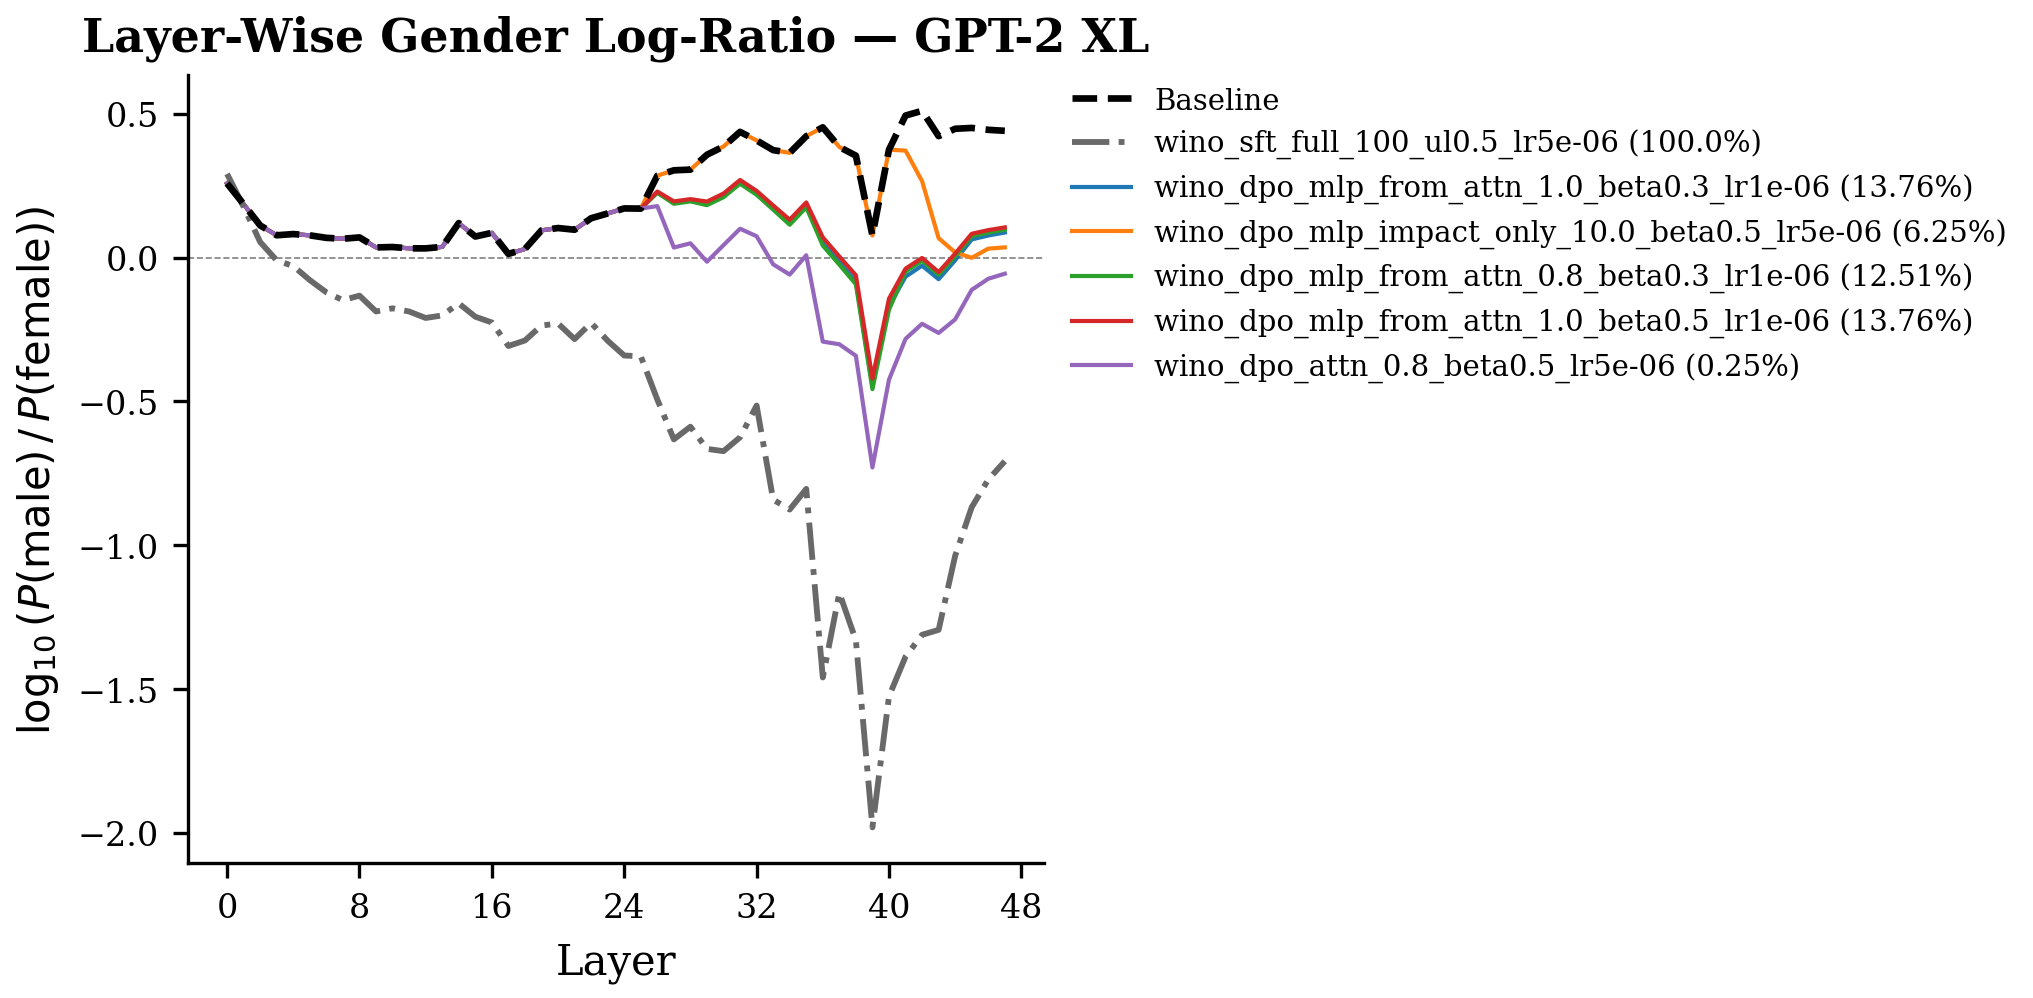

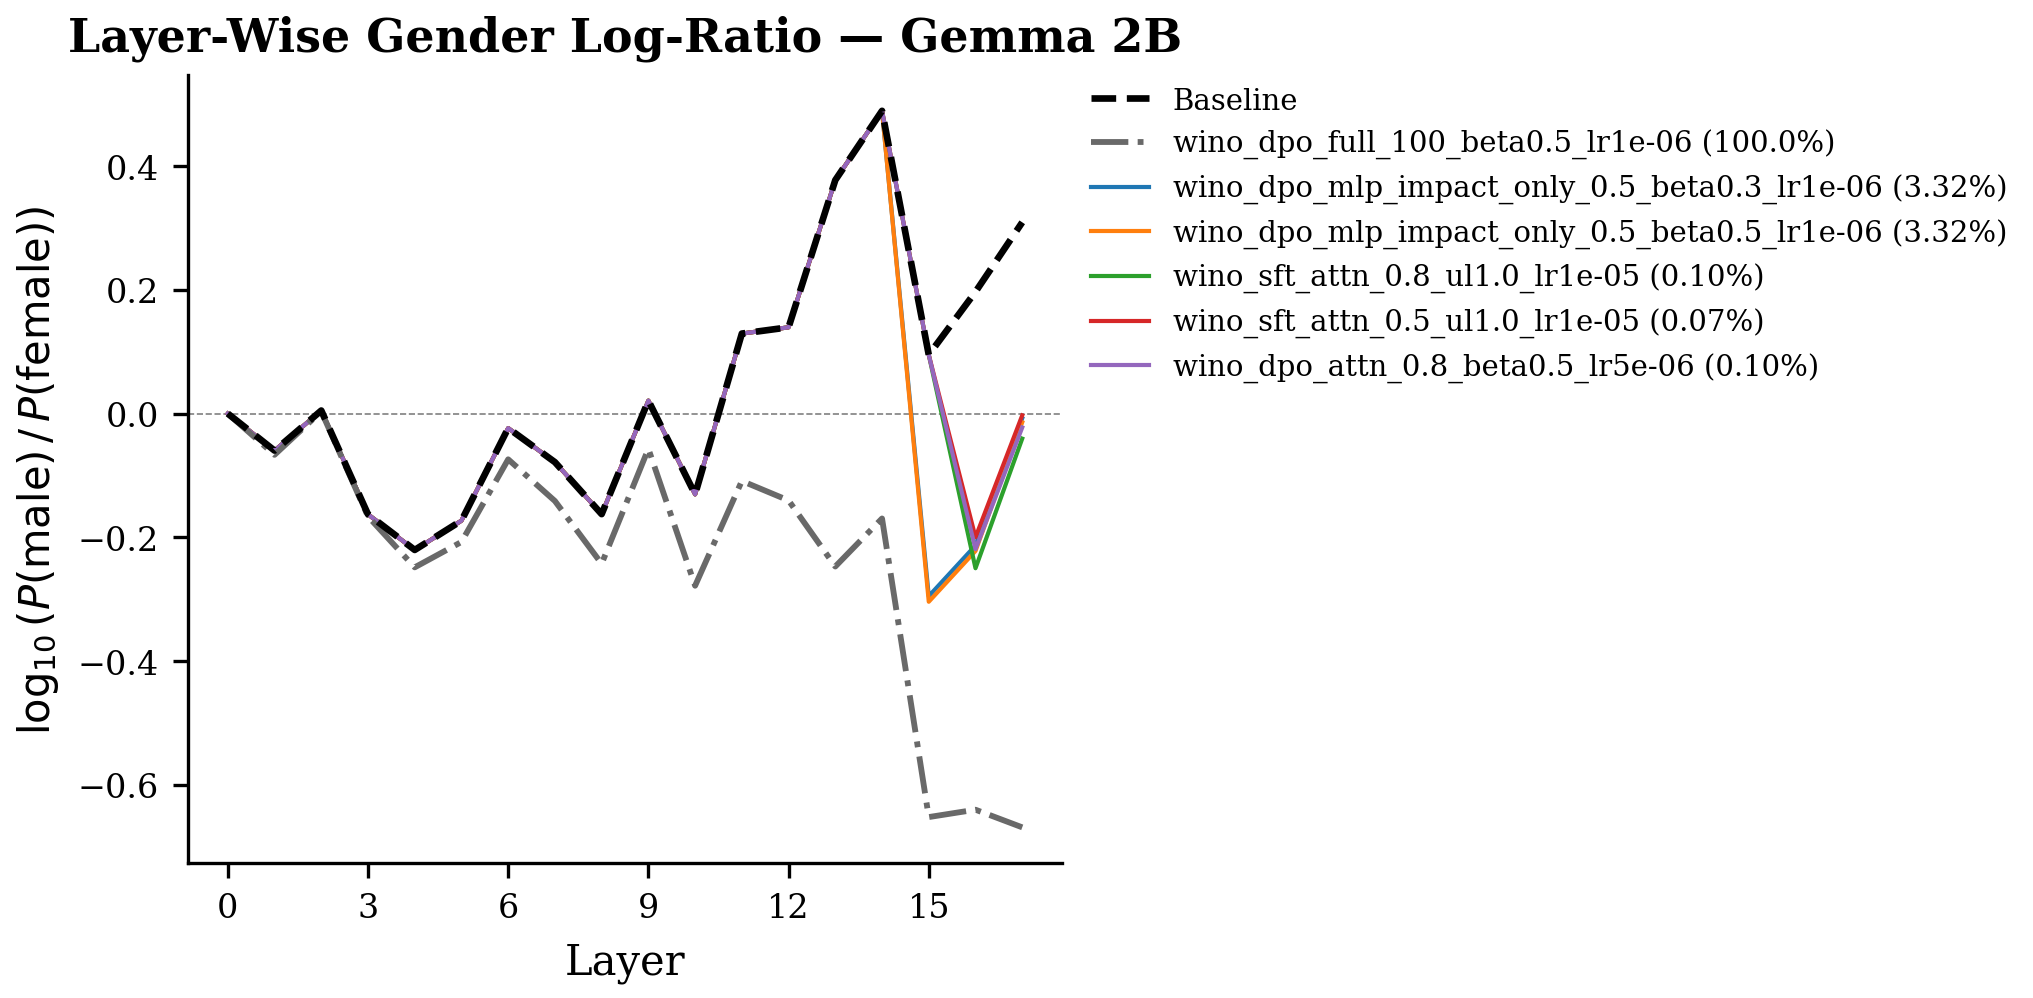

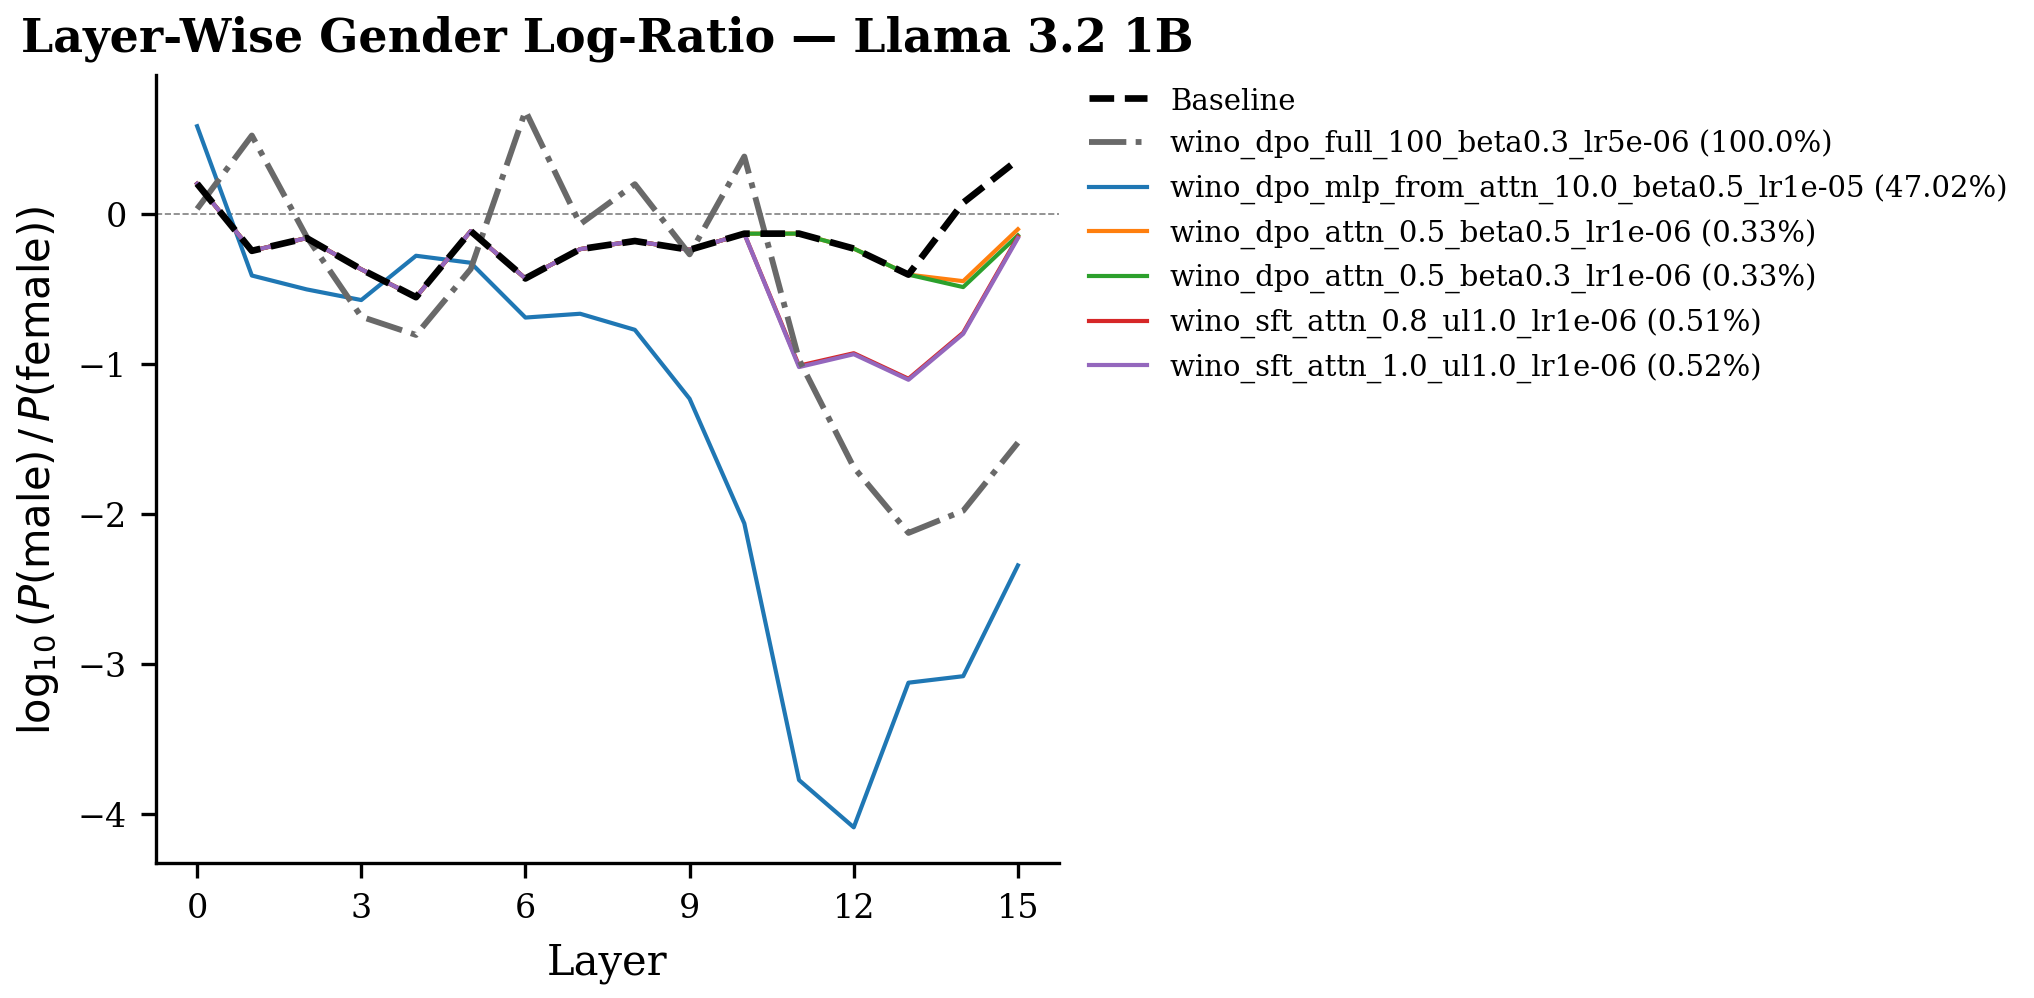

In [43]:
for model_name in model_names:
    sel = selections[model_name]
    run_probs = all_data[model_name]["run_probs"]
    dla_runs = sel["top5_dla"]
    best_full = sel["best_full"]
    safe_key = model_name.replace(" ", "_").replace(".", "")

    fig, ax = plt.subplots(figsize=(7.0, 3.5))

    baseline_lr = _layer_log_ratio_wino(run_probs["original_baseline"])
    ax.plot(baseline_lr.index, baseline_lr.values,
            color=BASELINE_COLOR, linewidth=1.6, linestyle="--", label="Baseline", zorder=5)

    if not best_full.empty:
        r_full = best_full.iloc[0]
        rid = r_full["run_id"]
        pct = f"{r_full['active_pct']:.1f}" if pd.notna(r_full.get("active_pct")) else "100"
        full_lr = _layer_log_ratio_wino(run_probs[rid])
        ax.plot(full_lr.index, full_lr.values,
                color=FULL_COLOR, linewidth=1.4, linestyle="-.",
                label=f"{rid} ({pct}%)", zorder=4)

    for i, (_, r) in enumerate(dla_runs.iterrows()):
        rid = r["run_id"]
        lr = _layer_log_ratio_wino(run_probs[rid])
        lbl = f"{rid} ({r['active_pct']:.2f}%)"
        ax.plot(lr.index, lr.values,
                color=DLA_COLORS[i], linewidth=1.0, label=lbl, zorder=3)

    ax.axhline(0, color="gray", linewidth=0.4, linestyle="--", zorder=1)
    ax.set_ylabel(r"$\log_{10}\left(P(\mathrm{male})\,/\,P(\mathrm{female})\right)$")
    ax.set_title(f"Layer-Wise Gender Log-Ratio — {model_name}", fontweight="bold")
    ax.set_xlabel("Layer")
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True, nbins=8))
    ax.legend(bbox_to_anchor=(1.02, 1.0), loc="upper left",
              borderaxespad=0, frameon=False, fontsize=7)
    sns.despine(ax=ax)

    plt.tight_layout()
    plt.show()

    FIGURES[f"layerwise_log_ratio_{safe_key}"] = fig

## P(gb) — Gender Bias Intensity

$P_{gb}$ measures gender bias intensity regardless of direction:

$$P_{gb} = |P(\text{he}) - P(\text{she})|$$

In log-ratio form for numerical precision:

$$P_{gb}^{\log} = \left|\log_{10}\left(\frac{P(\text{he})}{P(\text{she})}\right)\right|$$

$P_{gb} = 0$ means the model assigns equal probability to male and female pronouns.
Higher values indicate stronger gender preference (in either direction).

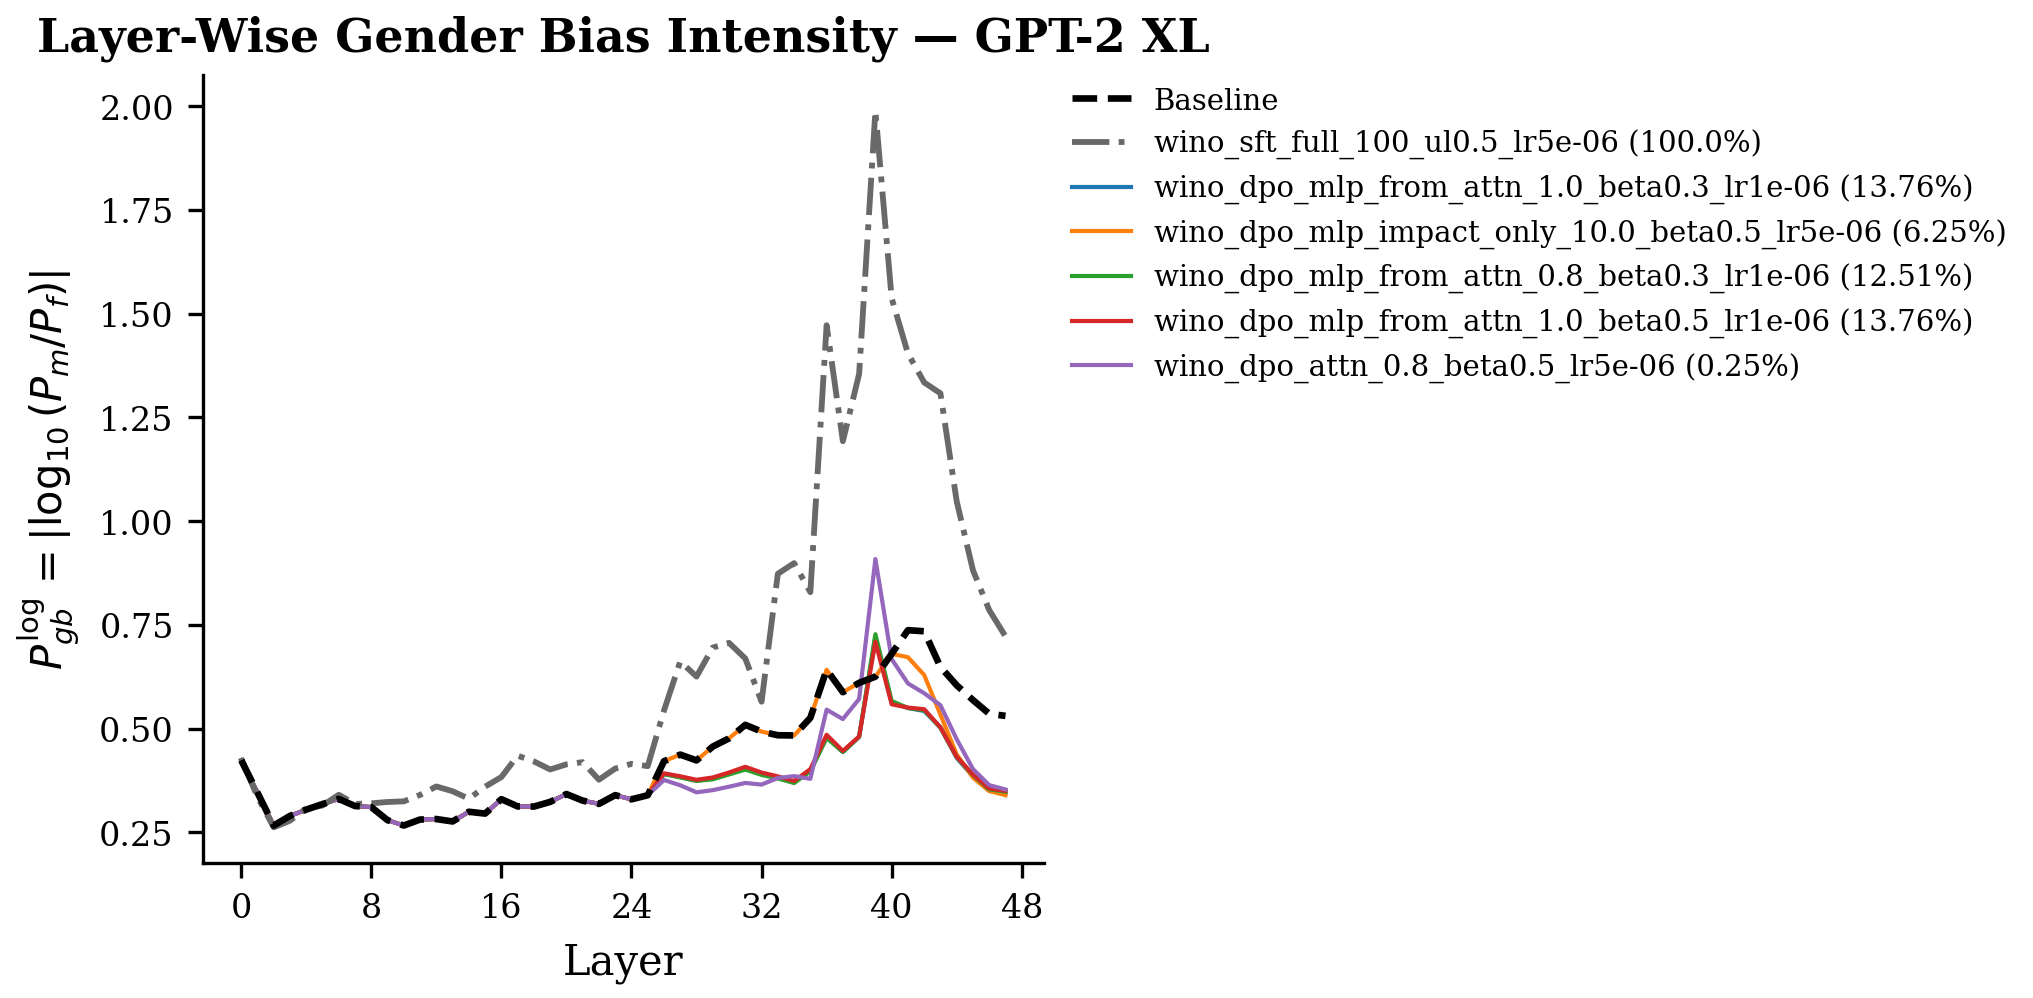

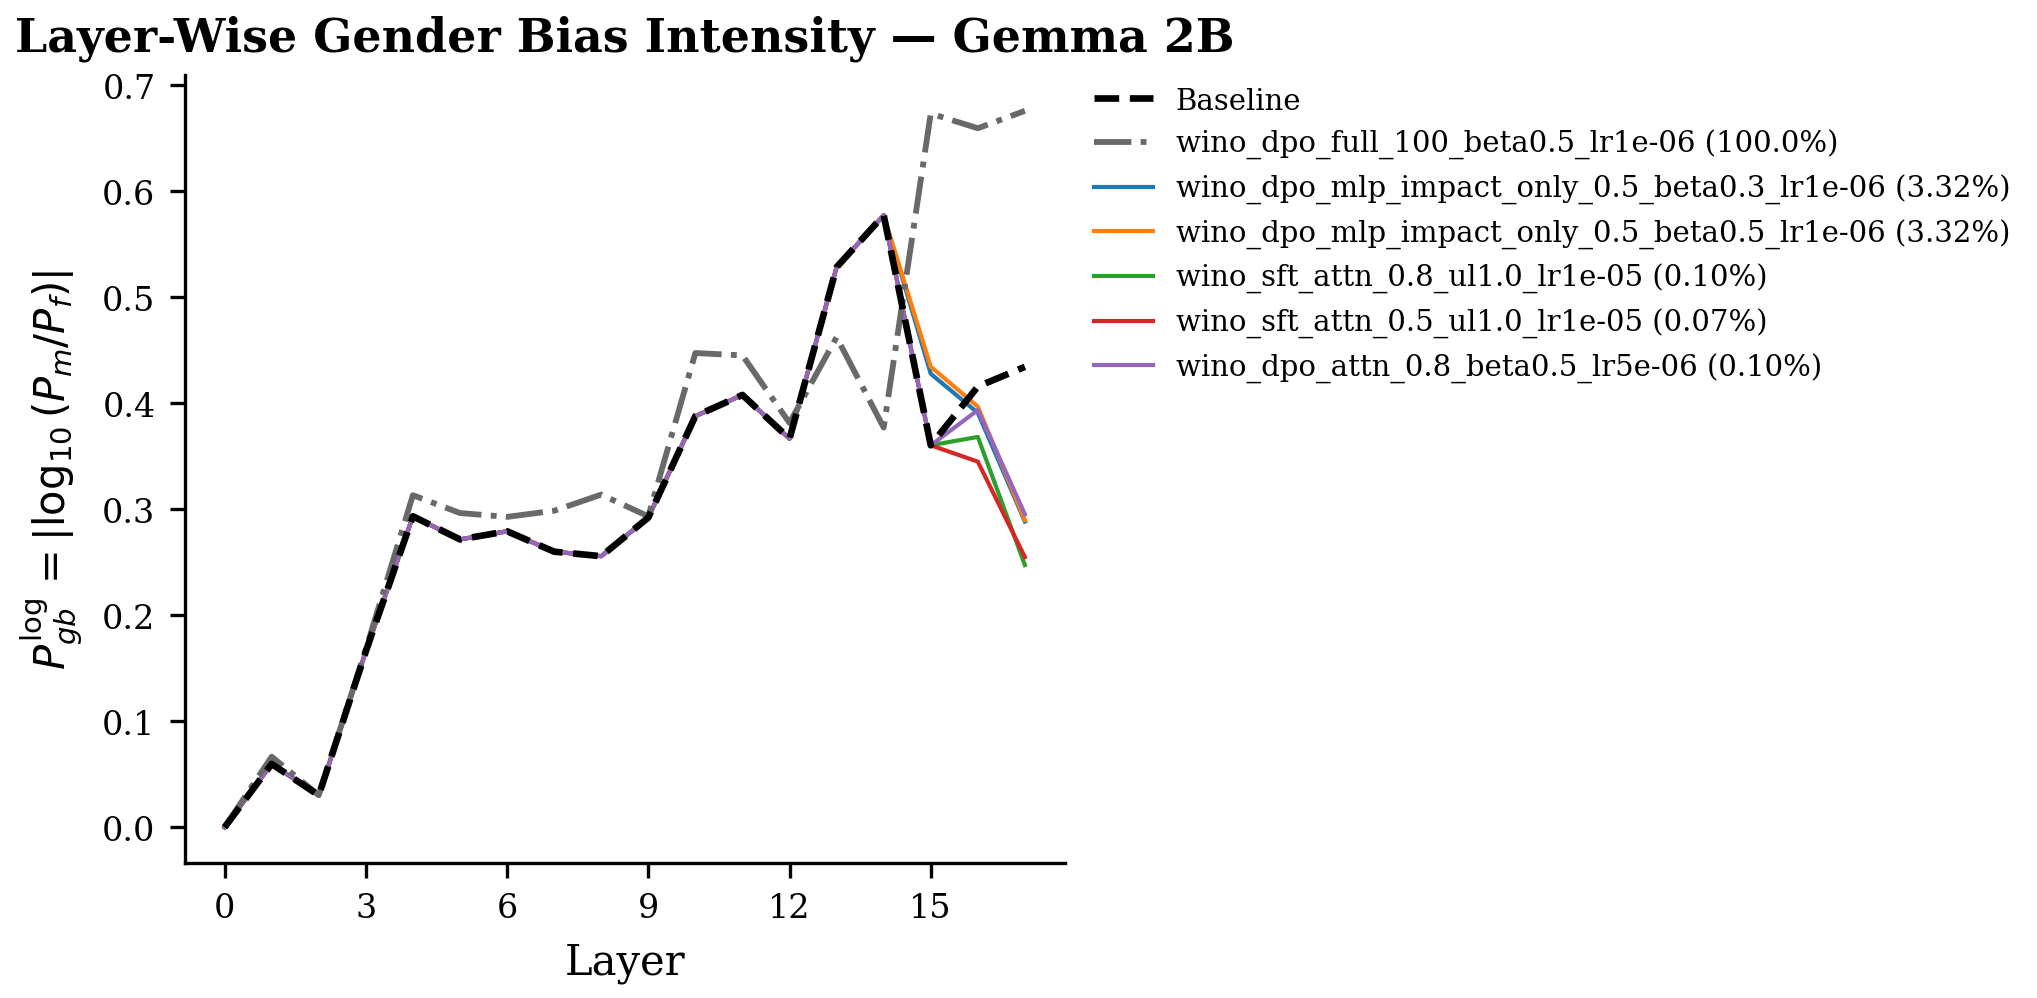

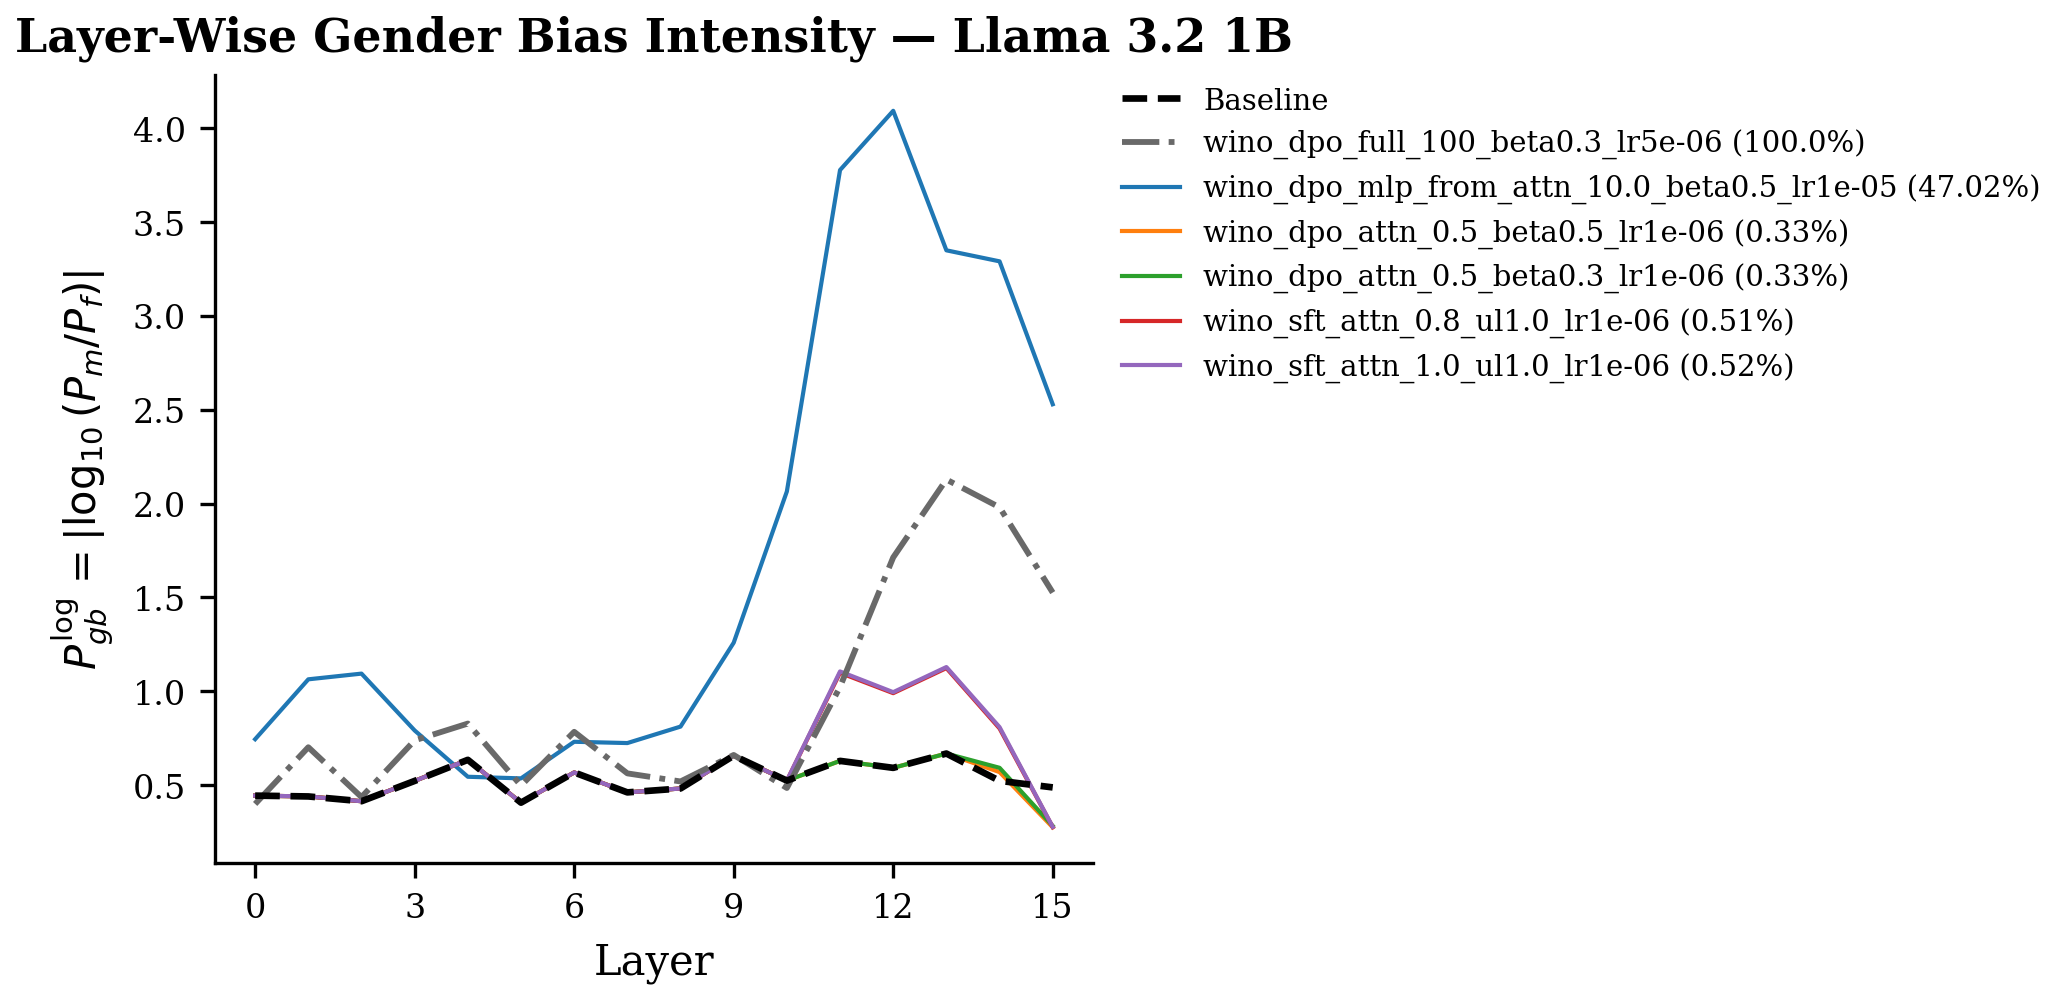

In [44]:
for model_name in model_names:
    sel = selections[model_name]
    run_probs = all_data[model_name]["run_probs"]
    dla_runs = sel["top5_dla"]
    best_full = sel["best_full"]
    safe_key = model_name.replace(" ", "_").replace(".", "")

    fig, ax = plt.subplots(figsize=(7.0, 3.5))

    baseline_pgb = _layer_pgb(run_probs["original_baseline"])
    ax.plot(baseline_pgb.index, baseline_pgb.values,
            color=BASELINE_COLOR, linewidth=1.6, linestyle="--", label="Baseline", zorder=5)

    if not best_full.empty:
        r_full = best_full.iloc[0]
        rid = r_full["run_id"]
        pct = f"{r_full['active_pct']:.1f}" if pd.notna(r_full.get("active_pct")) else "100"
        full_pgb = _layer_pgb(run_probs[rid])
        ax.plot(full_pgb.index, full_pgb.values,
                color=FULL_COLOR, linewidth=1.4, linestyle="-.",
                label=f"{rid} ({pct}%)", zorder=4)

    for i, (_, r) in enumerate(dla_runs.iterrows()):
        rid = r["run_id"]
        pgb = _layer_pgb(run_probs[rid])
        lbl = f"{rid} ({r['active_pct']:.2f}%)"
        ax.plot(pgb.index, pgb.values,
                color=DLA_COLORS[i], linewidth=1.0, label=lbl, zorder=3)

    ax.set_ylabel(r"$P_{gb}^{\log} = \left|\log_{10}(P_m / P_f)\right|$")
    ax.set_title(f"Layer-Wise Gender Bias Intensity — {model_name}", fontweight="bold")
    ax.set_xlabel("Layer")
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True, nbins=8))
    ax.legend(bbox_to_anchor=(1.02, 1.0), loc="upper left",
              borderaxespad=0, frameon=False, fontsize=7)
    sns.despine(ax=ax)

    plt.tight_layout()
    plt.show()

    FIGURES[f"layerwise_pgb_{safe_key}"] = fig

## P(sp) — Gender Specificity

$P_{sp} = P(\text{male}) + P(\text{female})$ measures how much total probability mass the model assigns to gendered pronouns. Stable P(sp) after debiasing indicates the model preserves its language modeling quality rather than trivially avoiding gendered pronouns.

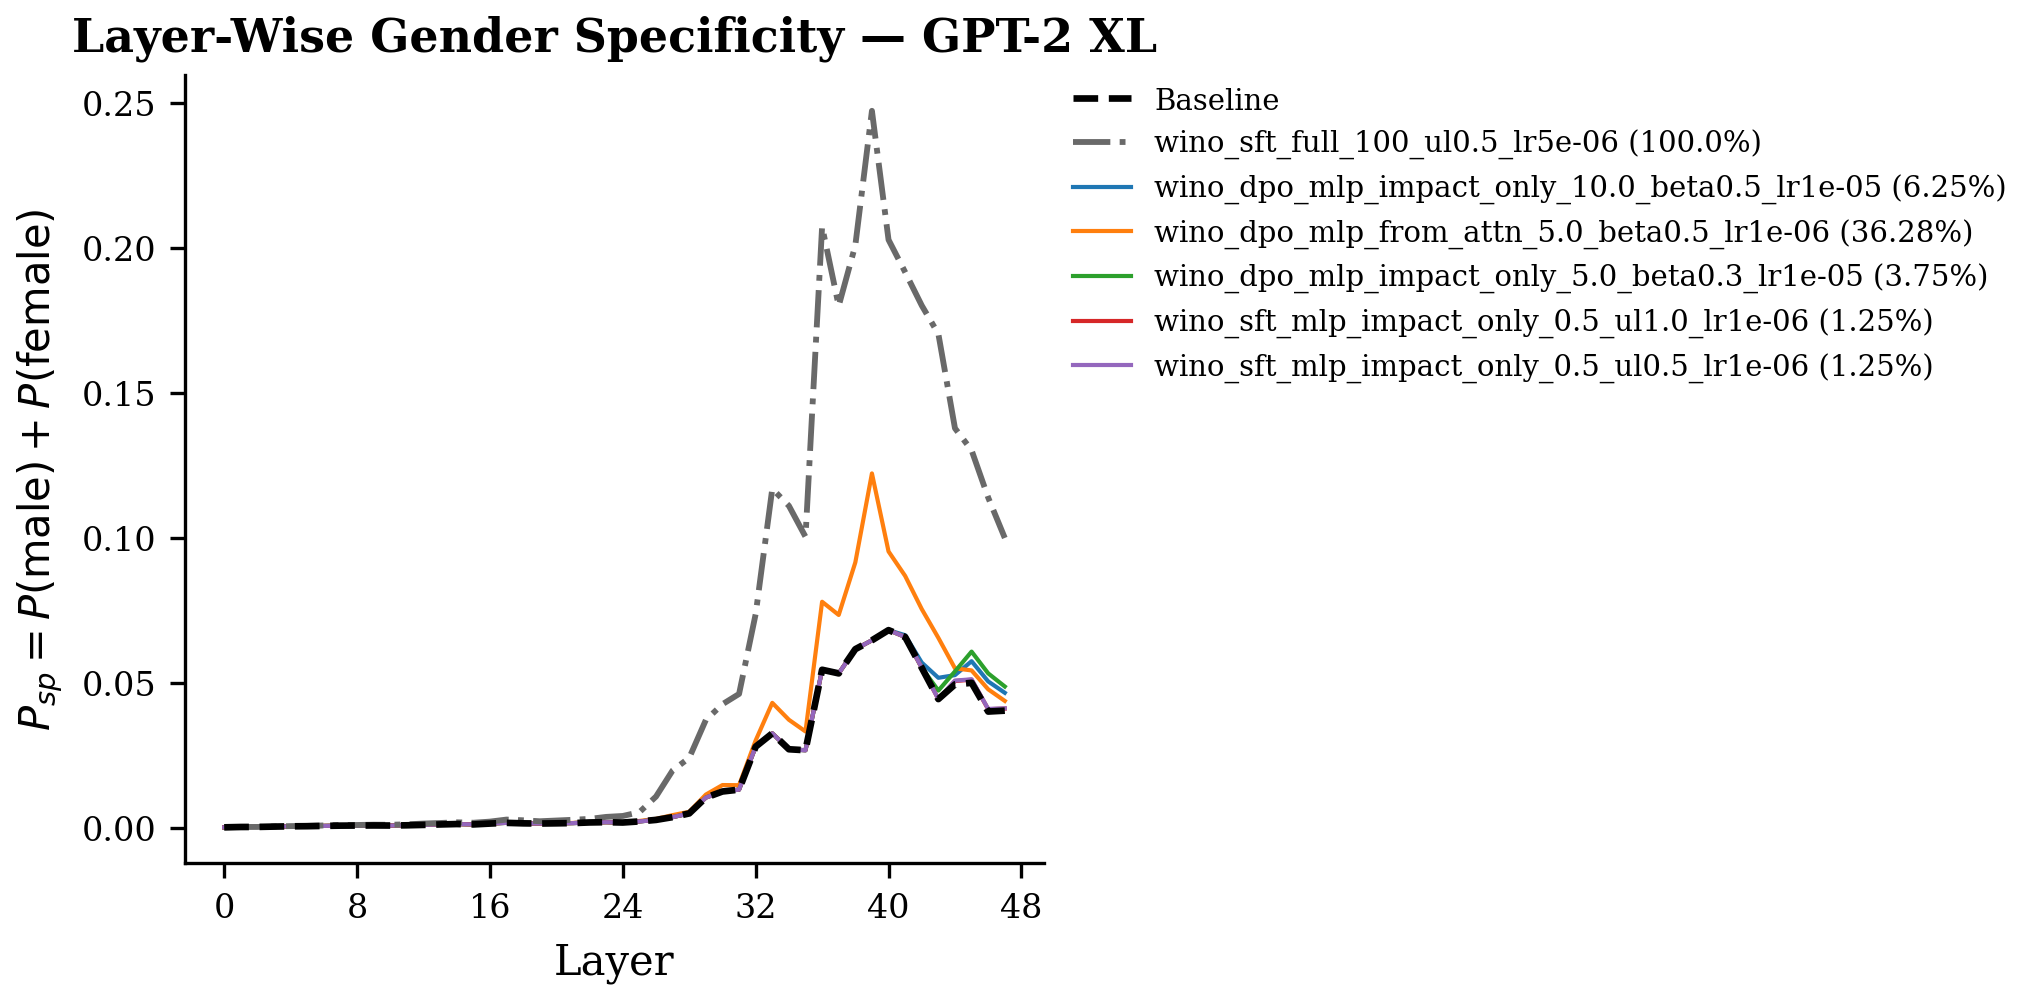

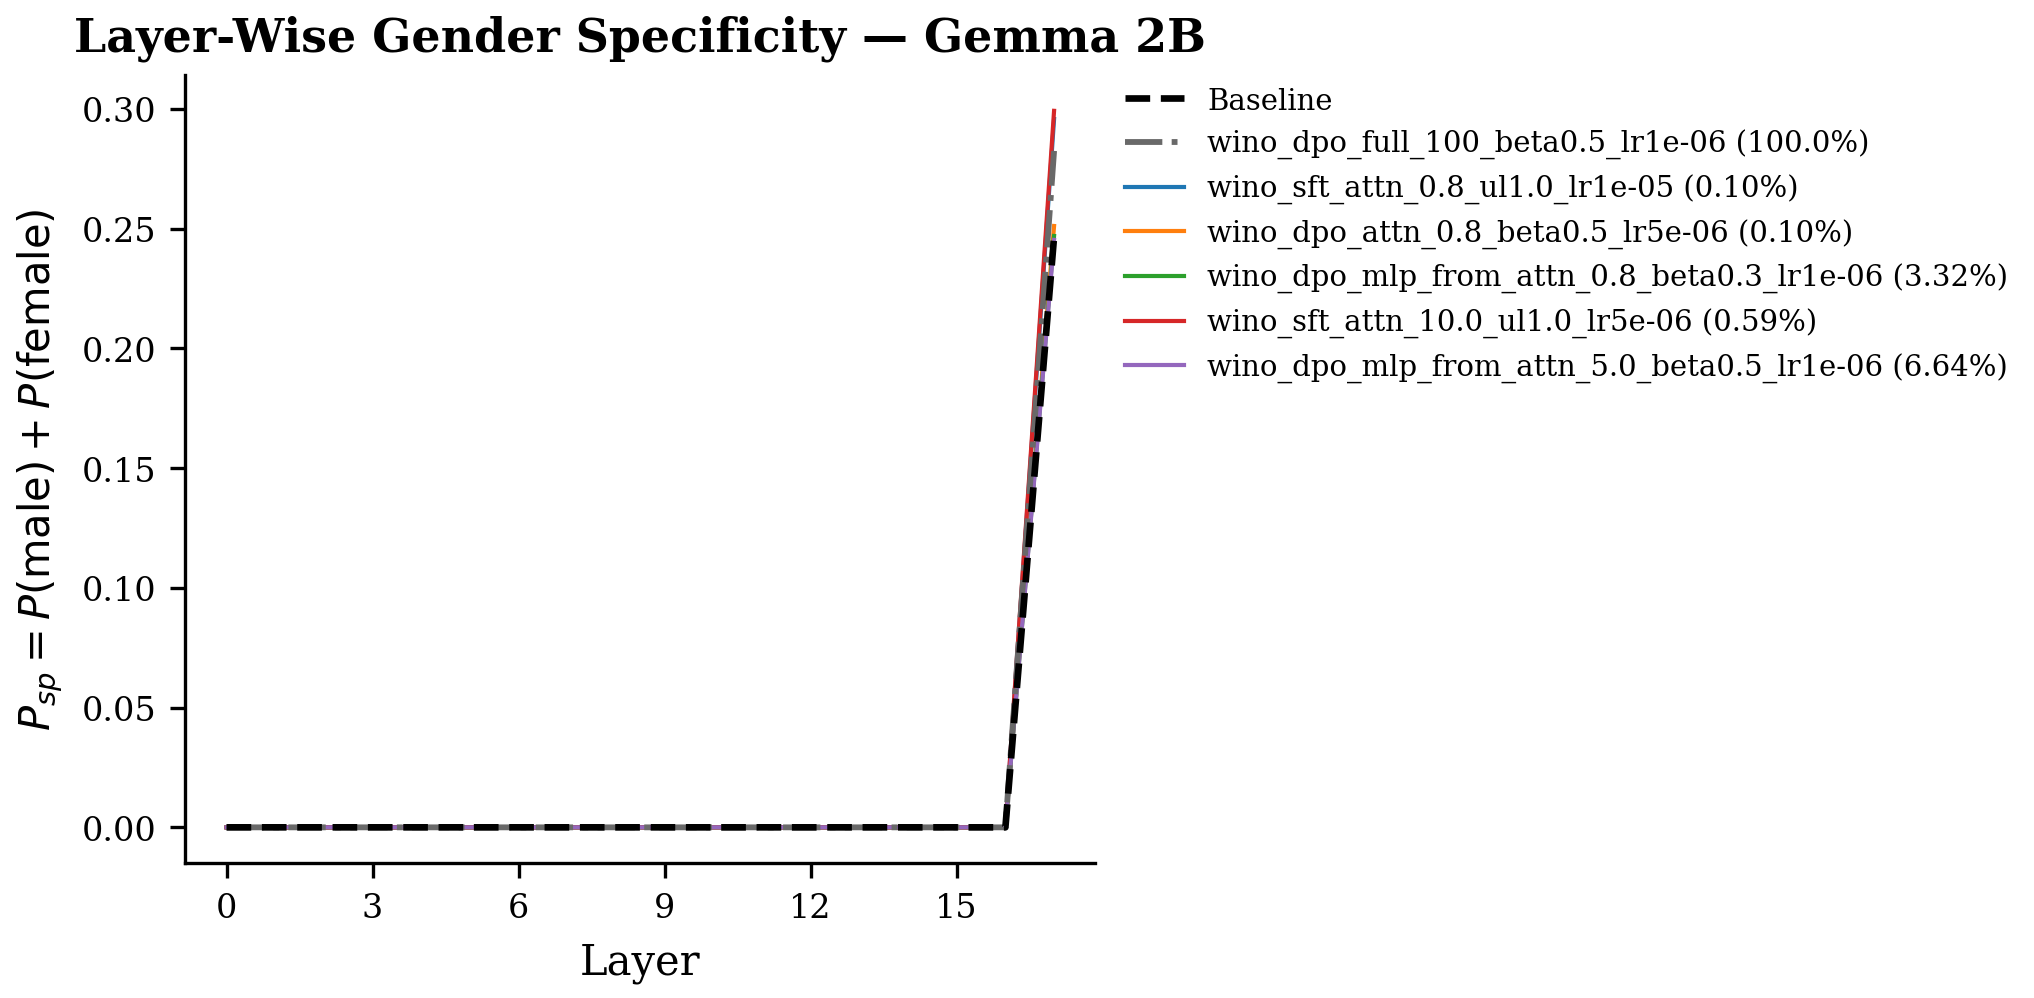

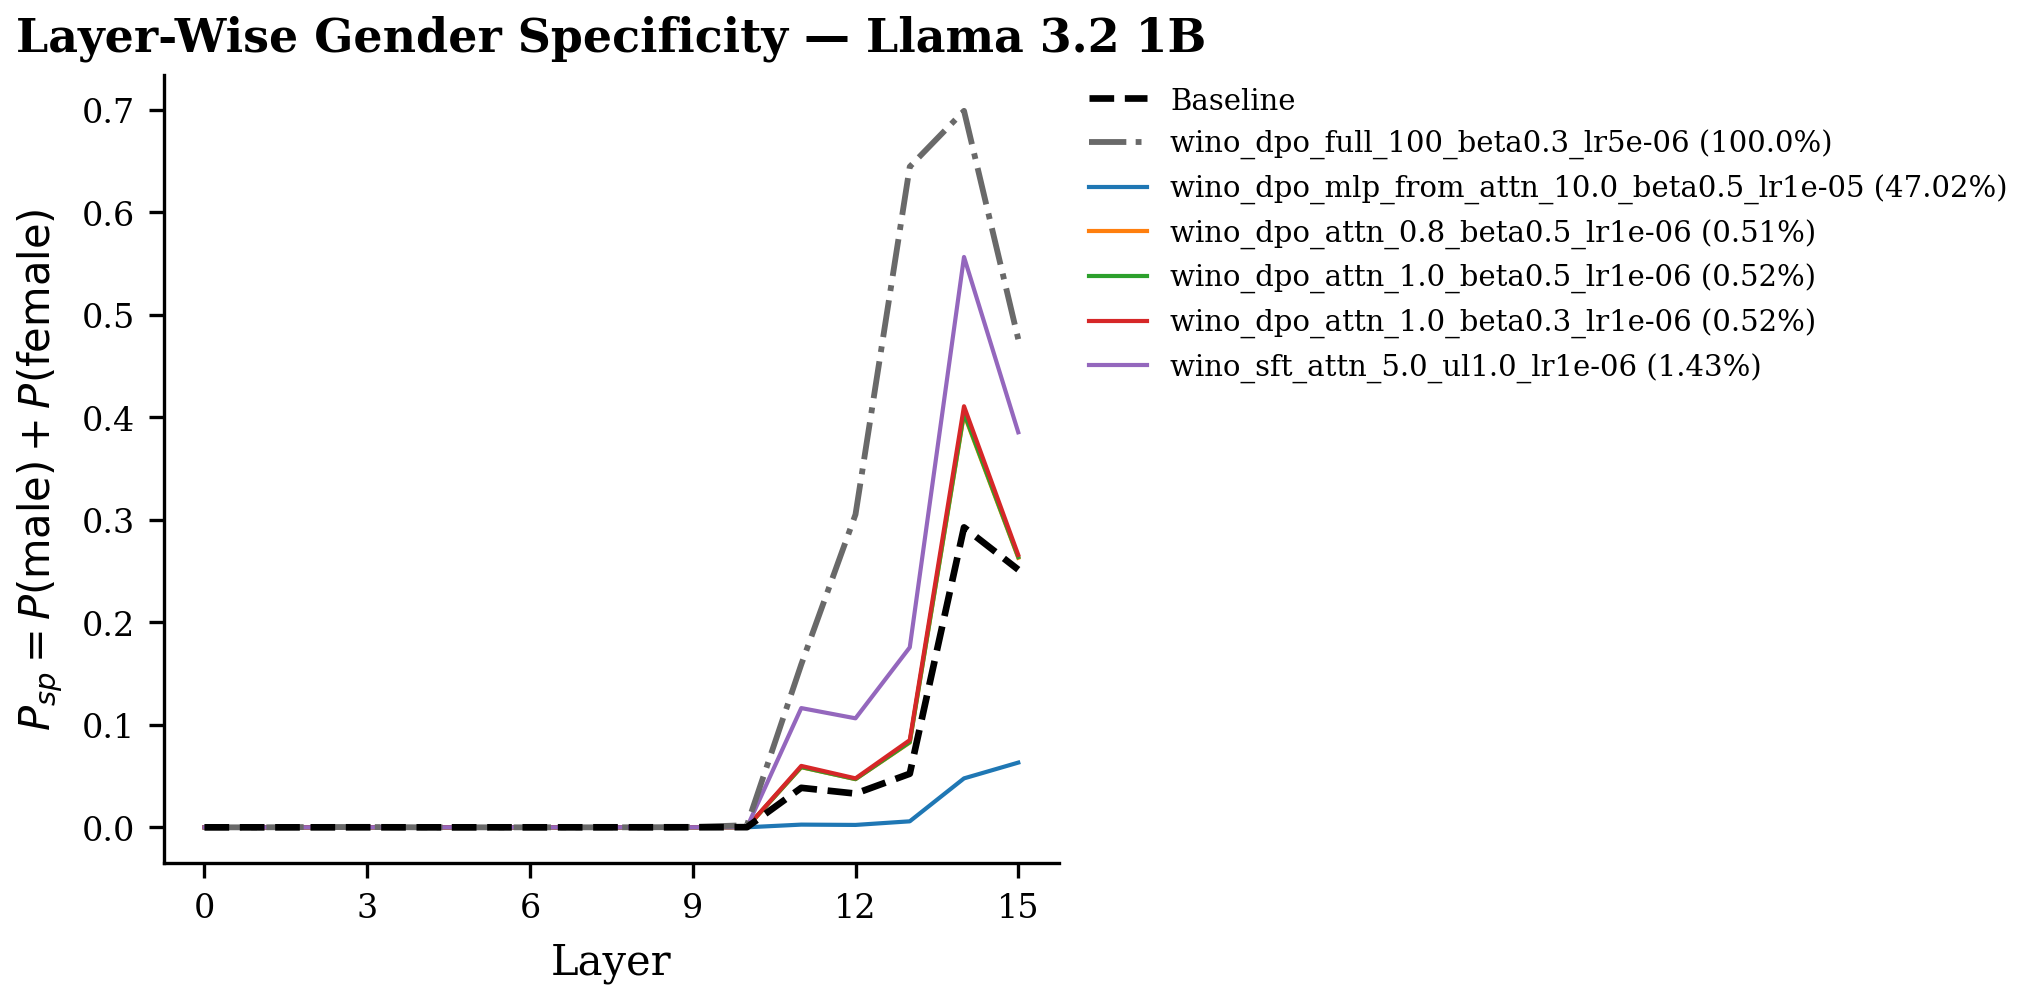

In [35]:
for model_name in model_names:
    sel = selections[model_name]
    run_probs = all_data[model_name]["run_probs"]
    dla_runs = sel["top5_dla"]
    best_full = sel["best_full"]
    safe_key = model_name.replace(" ", "_").replace(".", "")

    fig, ax = plt.subplots(figsize=(7.0, 3.5))

    baseline_psp = _layer_psp(run_probs["original_baseline"])
    ax.plot(baseline_psp.index, baseline_psp.values,
            color=BASELINE_COLOR, linewidth=1.6, linestyle="--", label="Baseline", zorder=5)

    if not best_full.empty:
        r_full = best_full.iloc[0]
        rid = r_full["run_id"]
        pct = f"{r_full['active_pct']:.1f}" if pd.notna(r_full.get("active_pct")) else "100"
        full_psp = _layer_psp(run_probs[rid])
        ax.plot(full_psp.index, full_psp.values,
                color=FULL_COLOR, linewidth=1.4, linestyle="-.",
                label=f"{rid} ({pct}%)", zorder=4)

    for i, (_, r) in enumerate(dla_runs.iterrows()):
        rid = r["run_id"]
        psp = _layer_psp(run_probs[rid])
        lbl = f"{rid} ({r['active_pct']:.2f}%)"
        ax.plot(psp.index, psp.values,
                color=DLA_COLORS[i], linewidth=1.0, label=lbl, zorder=3)

    ax.set_ylabel(r"$P_{sp} = P(\mathrm{male}) + P(\mathrm{female})$")
    ax.set_title(f"Layer-Wise Gender Specificity — {model_name}", fontweight="bold")
    ax.set_xlabel("Layer")
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True, nbins=8))
    ax.legend(bbox_to_anchor=(1.02, 1.0), loc="upper left",
              borderaxespad=0, frameon=False, fontsize=7)
    sns.despine(ax=ax)

    plt.tight_layout()
    plt.show()

    FIGURES[f"layerwise_psp_{safe_key}"] = fig

In [ ]:
for model_name in model_names:
    data = all_data[model_name]
    sel = selections[model_name]
    safe_key = model_name.replace(" ", "_").replace(".", "")

    baseline_bias = data["run_bias_dfs"]["original_baseline"].copy()
    baseline_bias["P_female_share"] = (
        baseline_bias["P_female"] / (baseline_bias["P_male"] + baseline_bias["P_female"] + 1e-30)
    )

    top5_dla = sel["top5_dla"]
    best_dla_rid = top5_dla.iloc[0]["run_id"] if not top5_dla.empty else None

    fig, ax = plt.subplots(figsize=(7, 3.5))

    ax.axhline(0.5, color="gray", linewidth=0.8, linestyle="--", label="Unbiased (0.5)", zorder=1)

    ax.scatter(baseline_bias["bls_pct_female"], baseline_bias["P_female_share"],
               color=BASELINE_COLOR, s=15, alpha=0.6, zorder=3, label=None)
    bls_r_bl = data["baseline_metrics"]["BLS_r"]
    z_bl = np.polyfit(baseline_bias["bls_pct_female"], baseline_bias["P_female_share"], 1)
    x_line = np.linspace(0, 100, 100)
    ax.plot(x_line, np.polyval(z_bl, x_line), color=BASELINE_COLOR, linewidth=1.5,
            label=f"Baseline (r={bls_r_bl:.3f})", zorder=4)

    if best_dla_rid and best_dla_rid in data["run_bias_dfs"]:
        dla_bias = data["run_bias_dfs"][best_dla_rid].copy()
        dla_bias["P_female_share"] = (
            dla_bias["P_female"] / (dla_bias["P_male"] + dla_bias["P_female"] + 1e-30)
        )
        dla_metrics = data["metrics"][data["metrics"]["run_id"] == best_dla_rid].iloc[0]
        bls_r_dla = dla_metrics["BLS_r"]

        ax.scatter(dla_bias["bls_pct_female"], dla_bias["P_female_share"],
                   color=DLA_COLORS[0], s=15, alpha=0.6, zorder=3, label=None)
        z_dla = np.polyfit(dla_bias["bls_pct_female"], dla_bias["P_female_share"], 1)
        ax.plot(x_line, np.polyval(z_dla, x_line), color=DLA_COLORS[0], linewidth=1.5,
                label=f"Best DLA (r={bls_r_dla:.3f})", zorder=4)

    best_full = sel["best_full"]
    if not best_full.empty:
        full_rid = best_full.iloc[0]["run_id"]
        if full_rid in data["run_bias_dfs"]:
            full_bias = data["run_bias_dfs"][full_rid].copy()
            full_bias["P_female_share"] = (
                full_bias["P_female"] / (full_bias["P_male"] + full_bias["P_female"] + 1e-30)
            )
            full_metrics = data["metrics"][data["metrics"]["run_id"] == full_rid].iloc[0]
            bls_r_full = full_metrics["BLS_r"]

            ax.scatter(full_bias["bls_pct_female"], full_bias["P_female_share"],
                       color=FULL_COLOR, s=15, alpha=0.4, zorder=2, label=None)
            z_full = np.polyfit(full_bias["bls_pct_female"], full_bias["P_female_share"], 1)
            ax.plot(x_line, np.polyval(z_full, x_line), color=FULL_COLOR, linewidth=1.2,
                    linestyle=":", label=f"Best Full (r={bls_r_full:.3f})", zorder=4)

    ax.set_xlabel("BLS % Female in Occupation")
    ax.set_ylabel("P(female) / [P(male) + P(female)]")
    ax.set_title(f"BLS Correlation — {model_name}", fontweight="bold")
    ax.set_xlim(-2, 102)
    ax.set_ylim(-0.05, 1.05)
    ax.legend(frameon=False, fontsize=7, loc="upper left")
    sns.despine(ax=ax)
    plt.tight_layout()
    plt.show()

    FIGURES[f"bls_scatter_{safe_key}"] = fig

In [45]:
for model_name in model_names:
    sel = selections[model_name]
    run_probs = all_data[model_name]["run_probs"]
    dla_runs = sel["top5_dla"]
    best_full = sel["best_full"]

    layer_funcs = {
        "log10(Pm/Pf)": _layer_log_ratio_wino,
        "P(gb)": _layer_pgb,
        "P(sp)": _layer_psp,
    }

    baseline_series = {name: fn(run_probs["original_baseline"]) for name, fn in layer_funcs.items()}
    max_layer = max(s.index.max() for s in baseline_series.values() if not s.empty)
    key_layers = sorted(set([0, int(max_layer * 0.25), int(max_layer * 0.5),
                             int(max_layer * 0.75), int(max_layer)]))

    rows = []
    run_list = [("Baseline", "original_baseline")]
    if not best_full.empty:
        run_list.append((best_full.iloc[0]["run_id"], best_full.iloc[0]["run_id"]))
    for _, r in dla_runs.iterrows():
        run_list.append((r["run_id"], r["run_id"]))

    for label, rid in run_list:
        if rid not in run_probs:
            continue
        series = {name: fn(run_probs[rid]) for name, fn in layer_funcs.items()}
        for layer in key_layers:
            row = {"Run": label, "Layer": layer}
            for name, s in series.items():
                row[name] = f"{s.get(layer, float('nan')):.6f}" if layer in s.index else "-"
            rows.append(row)

    lw_df = pd.DataFrame(rows)
    safe_label = model_name.replace(" ", "_").replace(".", "")
    display(lw_df.style.set_caption(f"{model_name} — Layer-Wise Metrics at Key Layers"))
    print(f"\nLaTeX ({model_name}):\n")
    print(lw_df.to_latex(
        index=False,
        caption=f"{model_name} — Layer-Wise Metrics at Key Layers",
        label=f"tab:wino_layerwise_{safe_label}",
    ))

,Run,Layer,log10(Pm/Pf),P(gb),P(sp)
0,Baseline,0,0.257855,0.423575,0.000185
1,Baseline,11,0.032233,0.280771,0.000892
2,Baseline,23,0.153451,0.339479,0.001958
3,Baseline,35,0.421959,0.525777,0.026771
4,Baseline,47,0.440730,0.530563,0.040421
5,wino_sft_full_100_ul0.5_lr5e-06,0,0.291055,0.428428,0.000210
6,wino_sft_full_100_ul0.5_lr5e-06,11,-0.187382,0.340149,0.001226
7,wino_sft_full_100_ul0.5_lr5e-06,23,-0.289050,0.403546,0.003786
8,wino_sft_full_100_ul0.5_lr5e-06,35,-0.804047,0.828573,0.100388
9,wino_sft_full_100_ul0.5_lr5e-06,47,-0.707923,0.722071,0.099972



LaTeX (GPT-2 XL):

\begin{table}
\caption{GPT-2 XL — Layer-Wise Metrics at Key Layers}
\label{tab:wino_layerwise_GPT-2_XL}
\begin{tabular}{lrlll}
\toprule
Run & Layer & log10(Pm/Pf) & P(gb) & P(sp) \\
\midrule
Baseline & 0 & 0.257855 & 0.423575 & 0.000185 \\
Baseline & 11 & 0.032233 & 0.280771 & 0.000892 \\
Baseline & 23 & 0.153451 & 0.339479 & 0.001958 \\
Baseline & 35 & 0.421959 & 0.525777 & 0.026771 \\
Baseline & 47 & 0.440730 & 0.530563 & 0.040421 \\
wino_sft_full_100_ul0.5_lr5e-06 & 0 & 0.291055 & 0.428428 & 0.000210 \\
wino_sft_full_100_ul0.5_lr5e-06 & 11 & -0.187382 & 0.340149 & 0.001226 \\
wino_sft_full_100_ul0.5_lr5e-06 & 23 & -0.289050 & 0.403546 & 0.003786 \\
wino_sft_full_100_ul0.5_lr5e-06 & 35 & -0.804047 & 0.828573 & 0.100388 \\
wino_sft_full_100_ul0.5_lr5e-06 & 47 & -0.707923 & 0.722071 & 0.099972 \\
wino_dpo_mlp_from_attn_1.0_beta0.3_lr1e-06 & 0 & 0.257855 & 0.423575 & 0.000185 \\
wino_dpo_mlp_from_attn_1.0_beta0.3_lr1e-06 & 11 & 0.032233 & 0.280771 & 0.000892 \\
wino_

,Run,Layer,log10(Pm/Pf),P(gb),P(sp)
0,Baseline,0,0.000000,0.000000,0.000000
1,Baseline,4,-0.220339,0.293376,0.000000
2,Baseline,8,-0.162475,0.255789,0.000000
3,Baseline,12,0.139398,0.366569,0.000000
4,Baseline,17,0.309046,0.434391,0.246504
5,wino_dpo_full_100_beta0.5_lr1e-06,0,0.000000,0.000000,0.000000
6,wino_dpo_full_100_beta0.5_lr1e-06,4,-0.248437,0.313310,0.000000
7,wino_dpo_full_100_beta0.5_lr1e-06,8,-0.242645,0.313882,0.000000
8,wino_dpo_full_100_beta0.5_lr1e-06,12,-0.140358,0.381494,0.000000
9,wino_dpo_full_100_beta0.5_lr1e-06,17,-0.668548,0.675883,0.282392



LaTeX (Gemma 2B):

\begin{table}
\caption{Gemma 2B — Layer-Wise Metrics at Key Layers}
\label{tab:wino_layerwise_Gemma_2B}
\begin{tabular}{lrlll}
\toprule
Run & Layer & log10(Pm/Pf) & P(gb) & P(sp) \\
\midrule
Baseline & 0 & 0.000000 & 0.000000 & 0.000000 \\
Baseline & 4 & -0.220339 & 0.293376 & 0.000000 \\
Baseline & 8 & -0.162475 & 0.255789 & 0.000000 \\
Baseline & 12 & 0.139398 & 0.366569 & 0.000000 \\
Baseline & 17 & 0.309046 & 0.434391 & 0.246504 \\
wino_dpo_full_100_beta0.5_lr1e-06 & 0 & 0.000000 & 0.000000 & 0.000000 \\
wino_dpo_full_100_beta0.5_lr1e-06 & 4 & -0.248437 & 0.313310 & 0.000000 \\
wino_dpo_full_100_beta0.5_lr1e-06 & 8 & -0.242645 & 0.313882 & 0.000000 \\
wino_dpo_full_100_beta0.5_lr1e-06 & 12 & -0.140358 & 0.381494 & 0.000000 \\
wino_dpo_full_100_beta0.5_lr1e-06 & 17 & -0.668548 & 0.675883 & 0.282392 \\
wino_dpo_mlp_impact_only_0.5_beta0.3_lr1e-06 & 0 & 0.000000 & 0.000000 & 0.000000 \\
wino_dpo_mlp_impact_only_0.5_beta0.3_lr1e-06 & 4 & -0.220339 & 0.293376 & 0.000

,Run,Layer,log10(Pm/Pf),P(gb),P(sp)
0,Baseline,0,0.201198,0.444337,0.000000
1,Baseline,3,-0.369711,0.522678,0.000036
2,Baseline,7,-0.235017,0.461573,0.000021
3,Baseline,11,-0.131407,0.629426,0.038544
4,Baseline,15,0.361517,0.488157,0.251398
5,wino_dpo_full_100_beta0.3_lr5e-06,0,0.033128,0.400004,0.000000
6,wino_dpo_full_100_beta0.3_lr5e-06,3,-0.685886,0.738693,0.000323
7,wino_dpo_full_100_beta0.3_lr5e-06,7,-0.068668,0.562838,0.000008
8,wino_dpo_full_100_beta0.3_lr5e-06,11,-0.972478,1.023858,0.158912
9,wino_dpo_full_100_beta0.3_lr5e-06,15,-1.525943,1.525943,0.476239



LaTeX (Llama 3.2 1B):

\begin{table}
\caption{Llama 3.2 1B — Layer-Wise Metrics at Key Layers}
\label{tab:wino_layerwise_Llama_32_1B}
\begin{tabular}{lrlll}
\toprule
Run & Layer & log10(Pm/Pf) & P(gb) & P(sp) \\
\midrule
Baseline & 0 & 0.201198 & 0.444337 & 0.000000 \\
Baseline & 3 & -0.369711 & 0.522678 & 0.000036 \\
Baseline & 7 & -0.235017 & 0.461573 & 0.000021 \\
Baseline & 11 & -0.131407 & 0.629426 & 0.038544 \\
Baseline & 15 & 0.361517 & 0.488157 & 0.251398 \\
wino_dpo_full_100_beta0.3_lr5e-06 & 0 & 0.033128 & 0.400004 & 0.000000 \\
wino_dpo_full_100_beta0.3_lr5e-06 & 3 & -0.685886 & 0.738693 & 0.000323 \\
wino_dpo_full_100_beta0.3_lr5e-06 & 7 & -0.068668 & 0.562838 & 0.000008 \\
wino_dpo_full_100_beta0.3_lr5e-06 & 11 & -0.972478 & 1.023858 & 0.158912 \\
wino_dpo_full_100_beta0.3_lr5e-06 & 15 & -1.525943 & 1.525943 & 0.476239 \\
wino_dpo_mlp_from_attn_10.0_beta0.5_lr1e-05 & 0 & 0.584917 & 0.744966 & 0.000000 \\
wino_dpo_mlp_from_attn_10.0_beta0.5_lr1e-05 & 3 & -0.574755 & 0.7914

/tmp/ipykernel_603517/2614398281.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


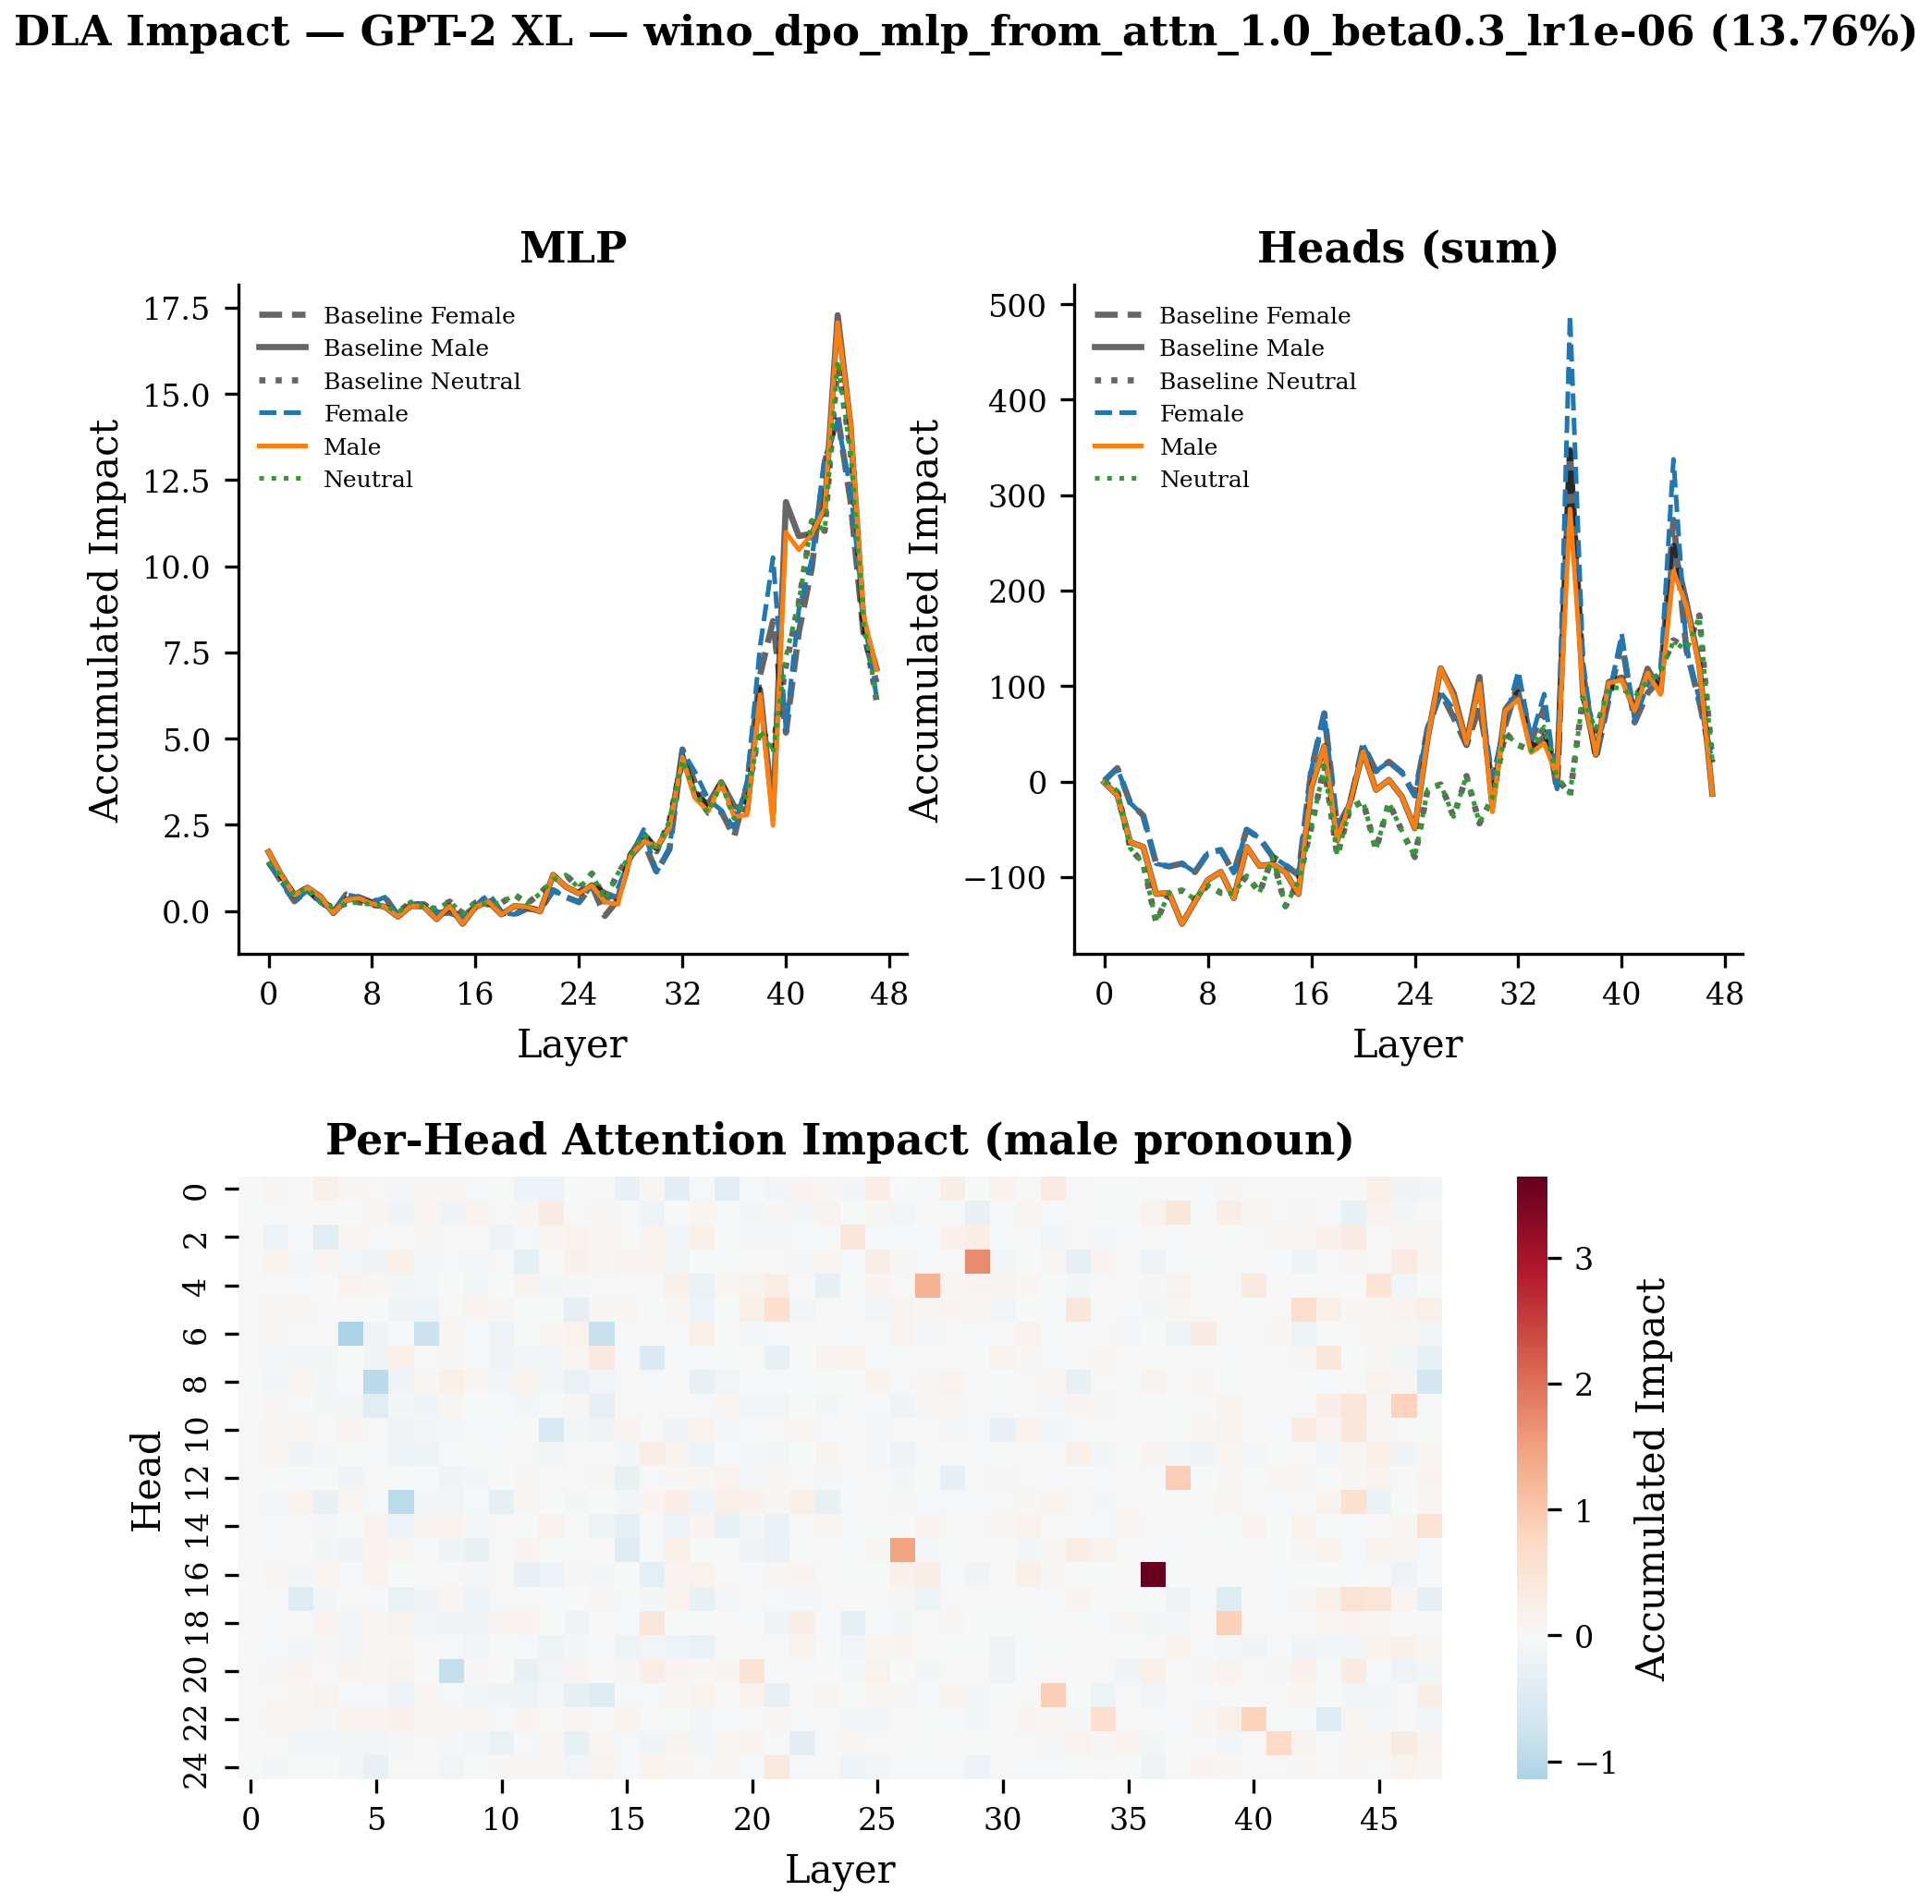

/tmp/ipykernel_603517/2614398281.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


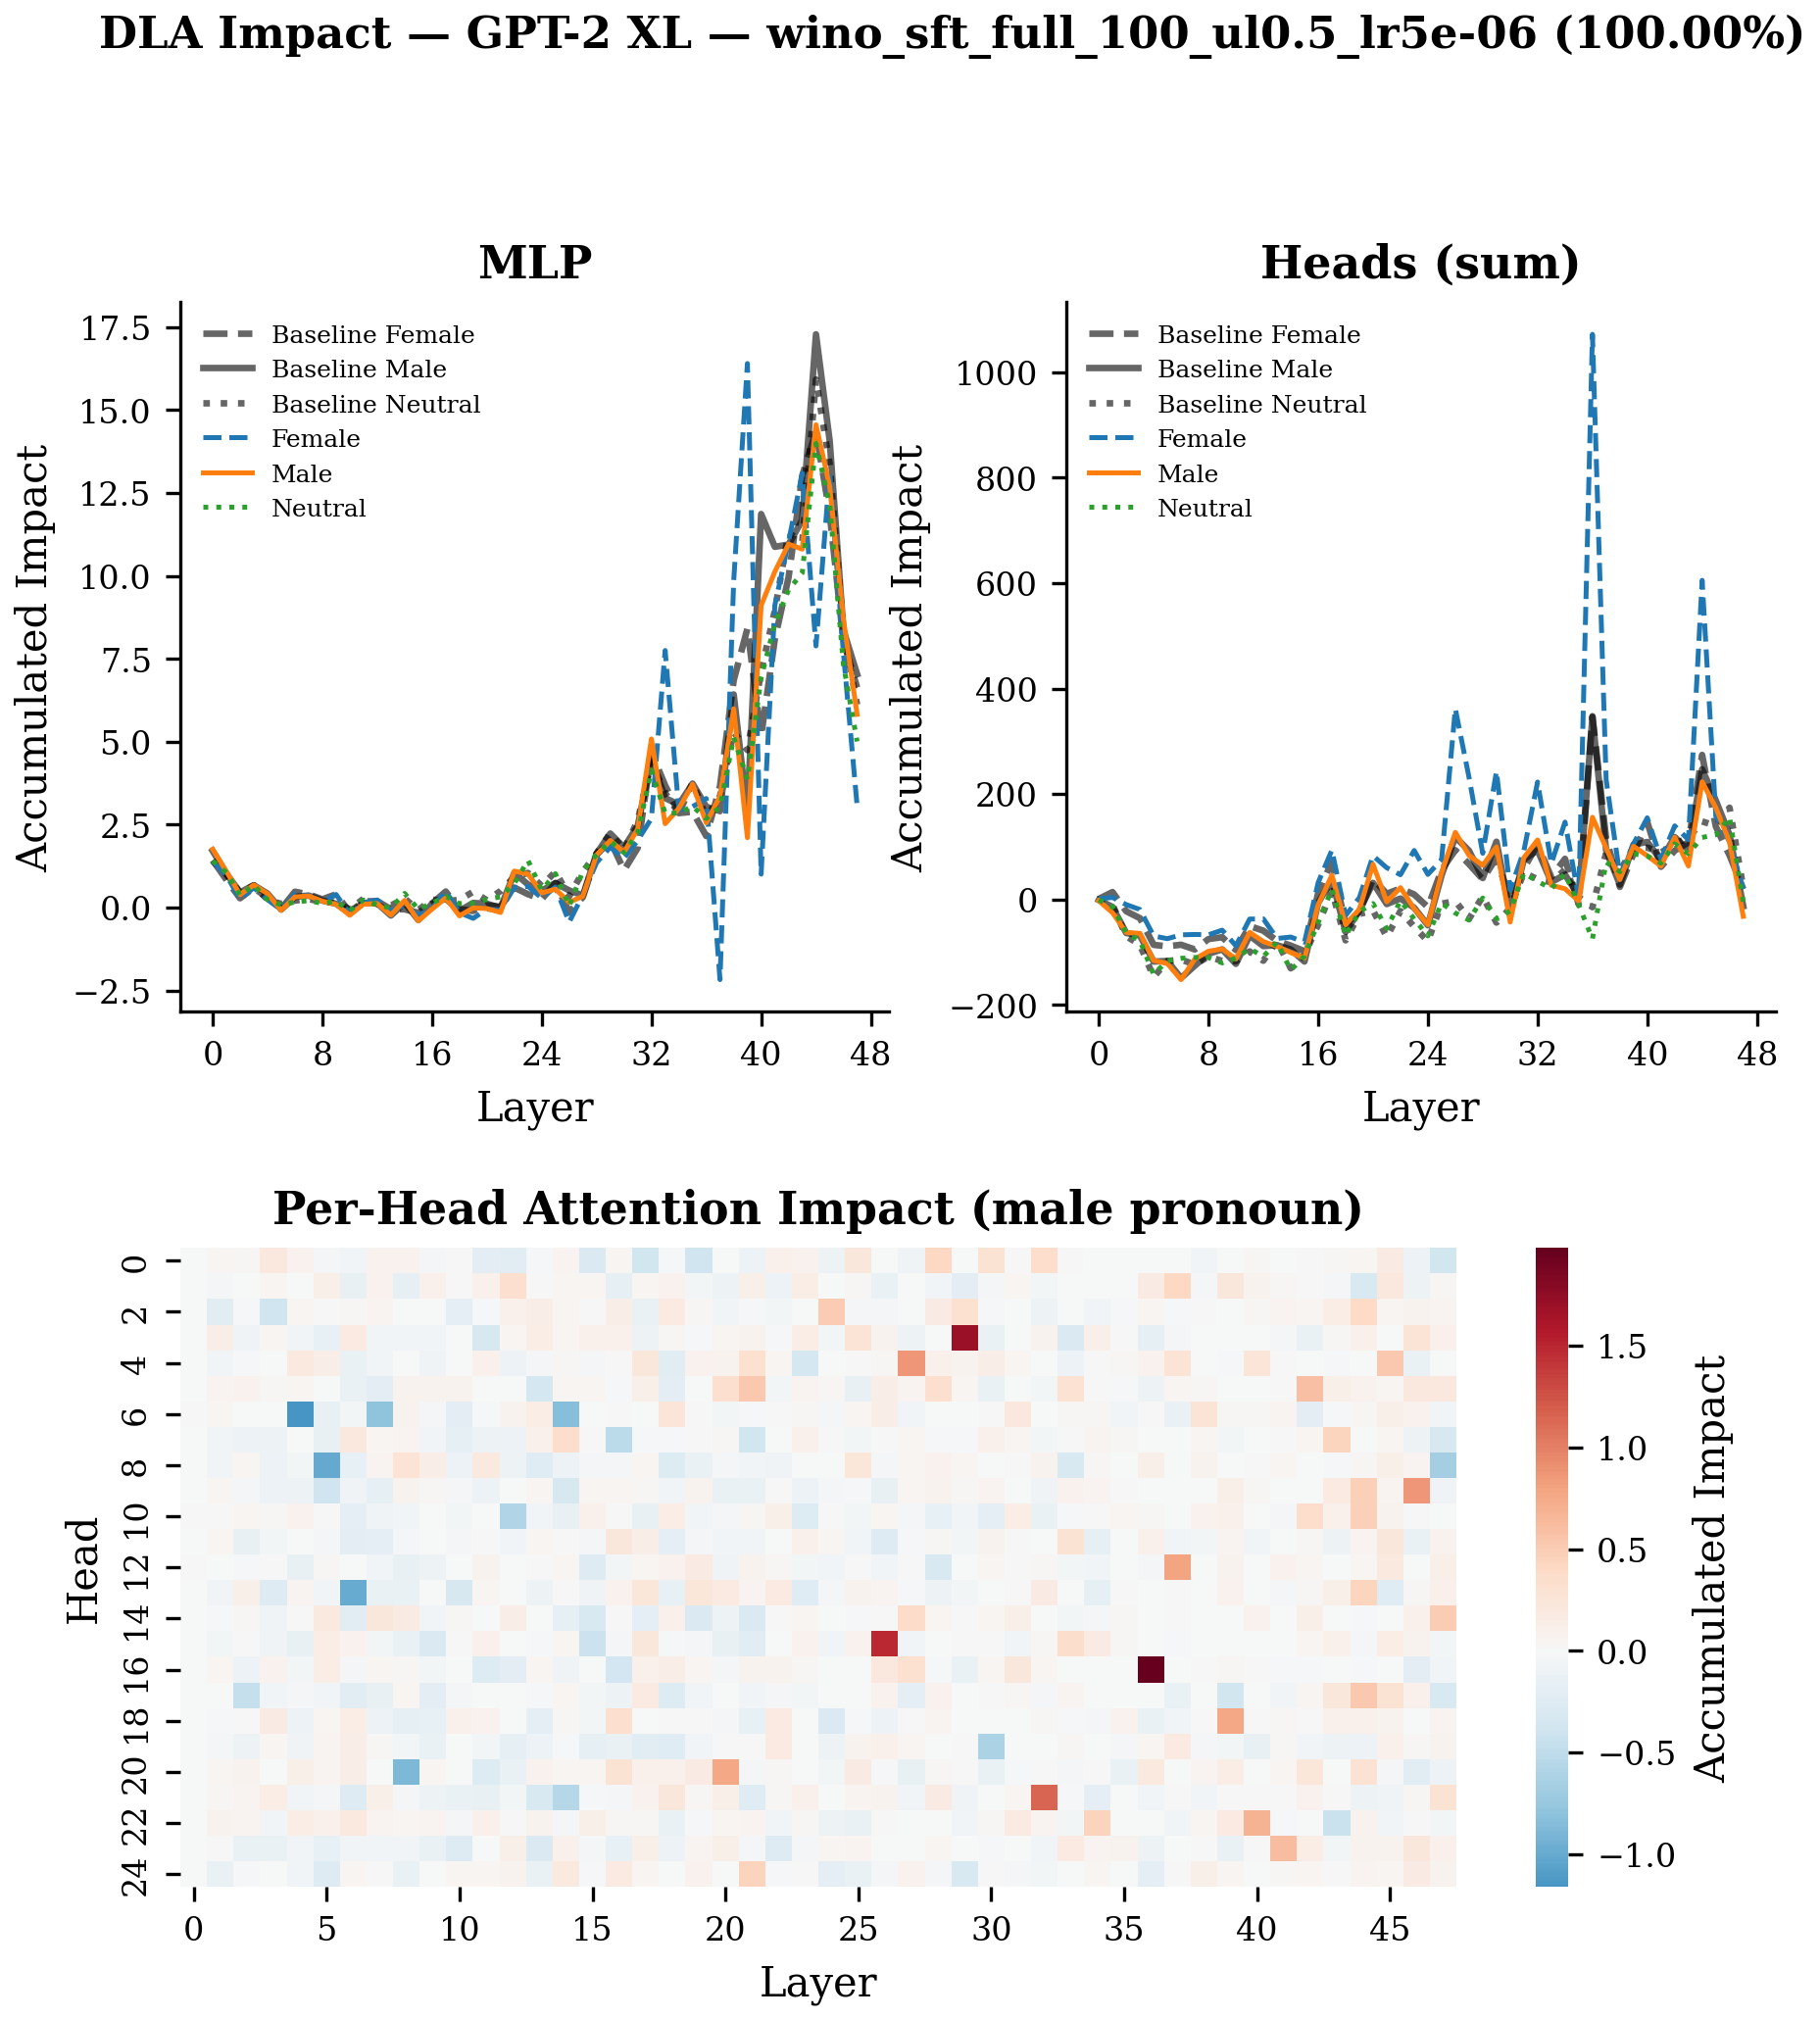

/tmp/ipykernel_603517/2614398281.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


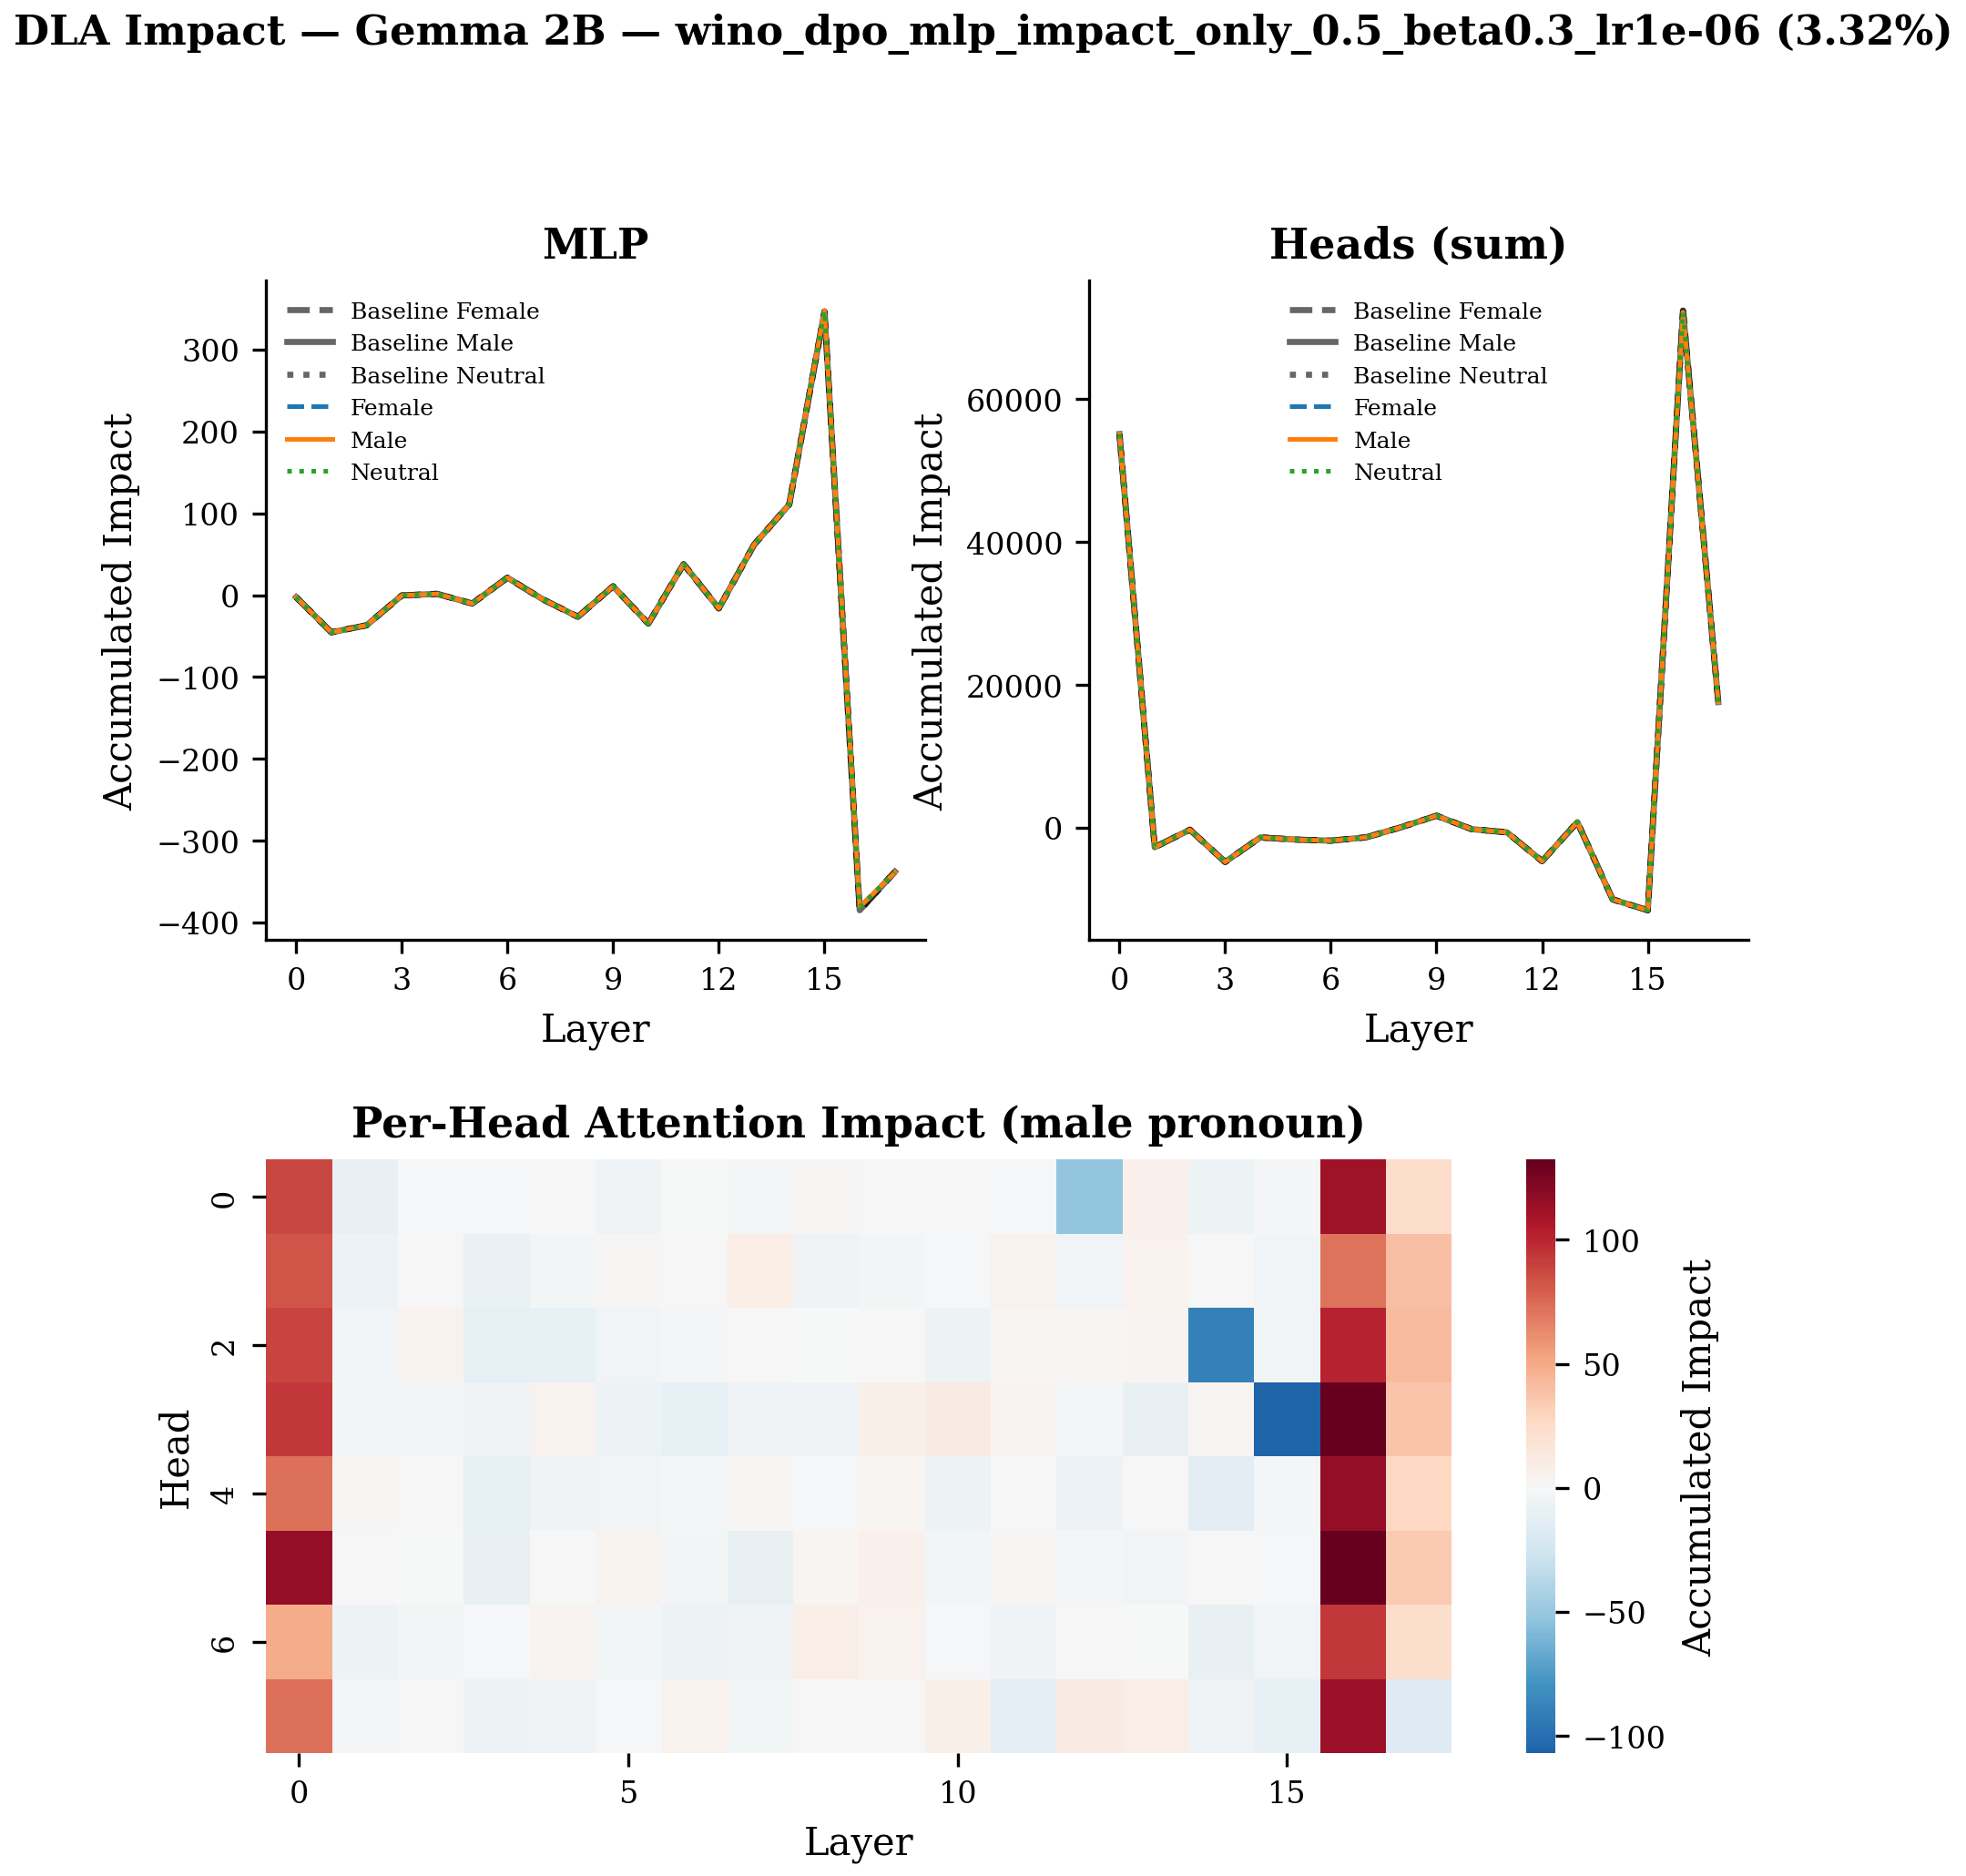

/tmp/ipykernel_603517/2614398281.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


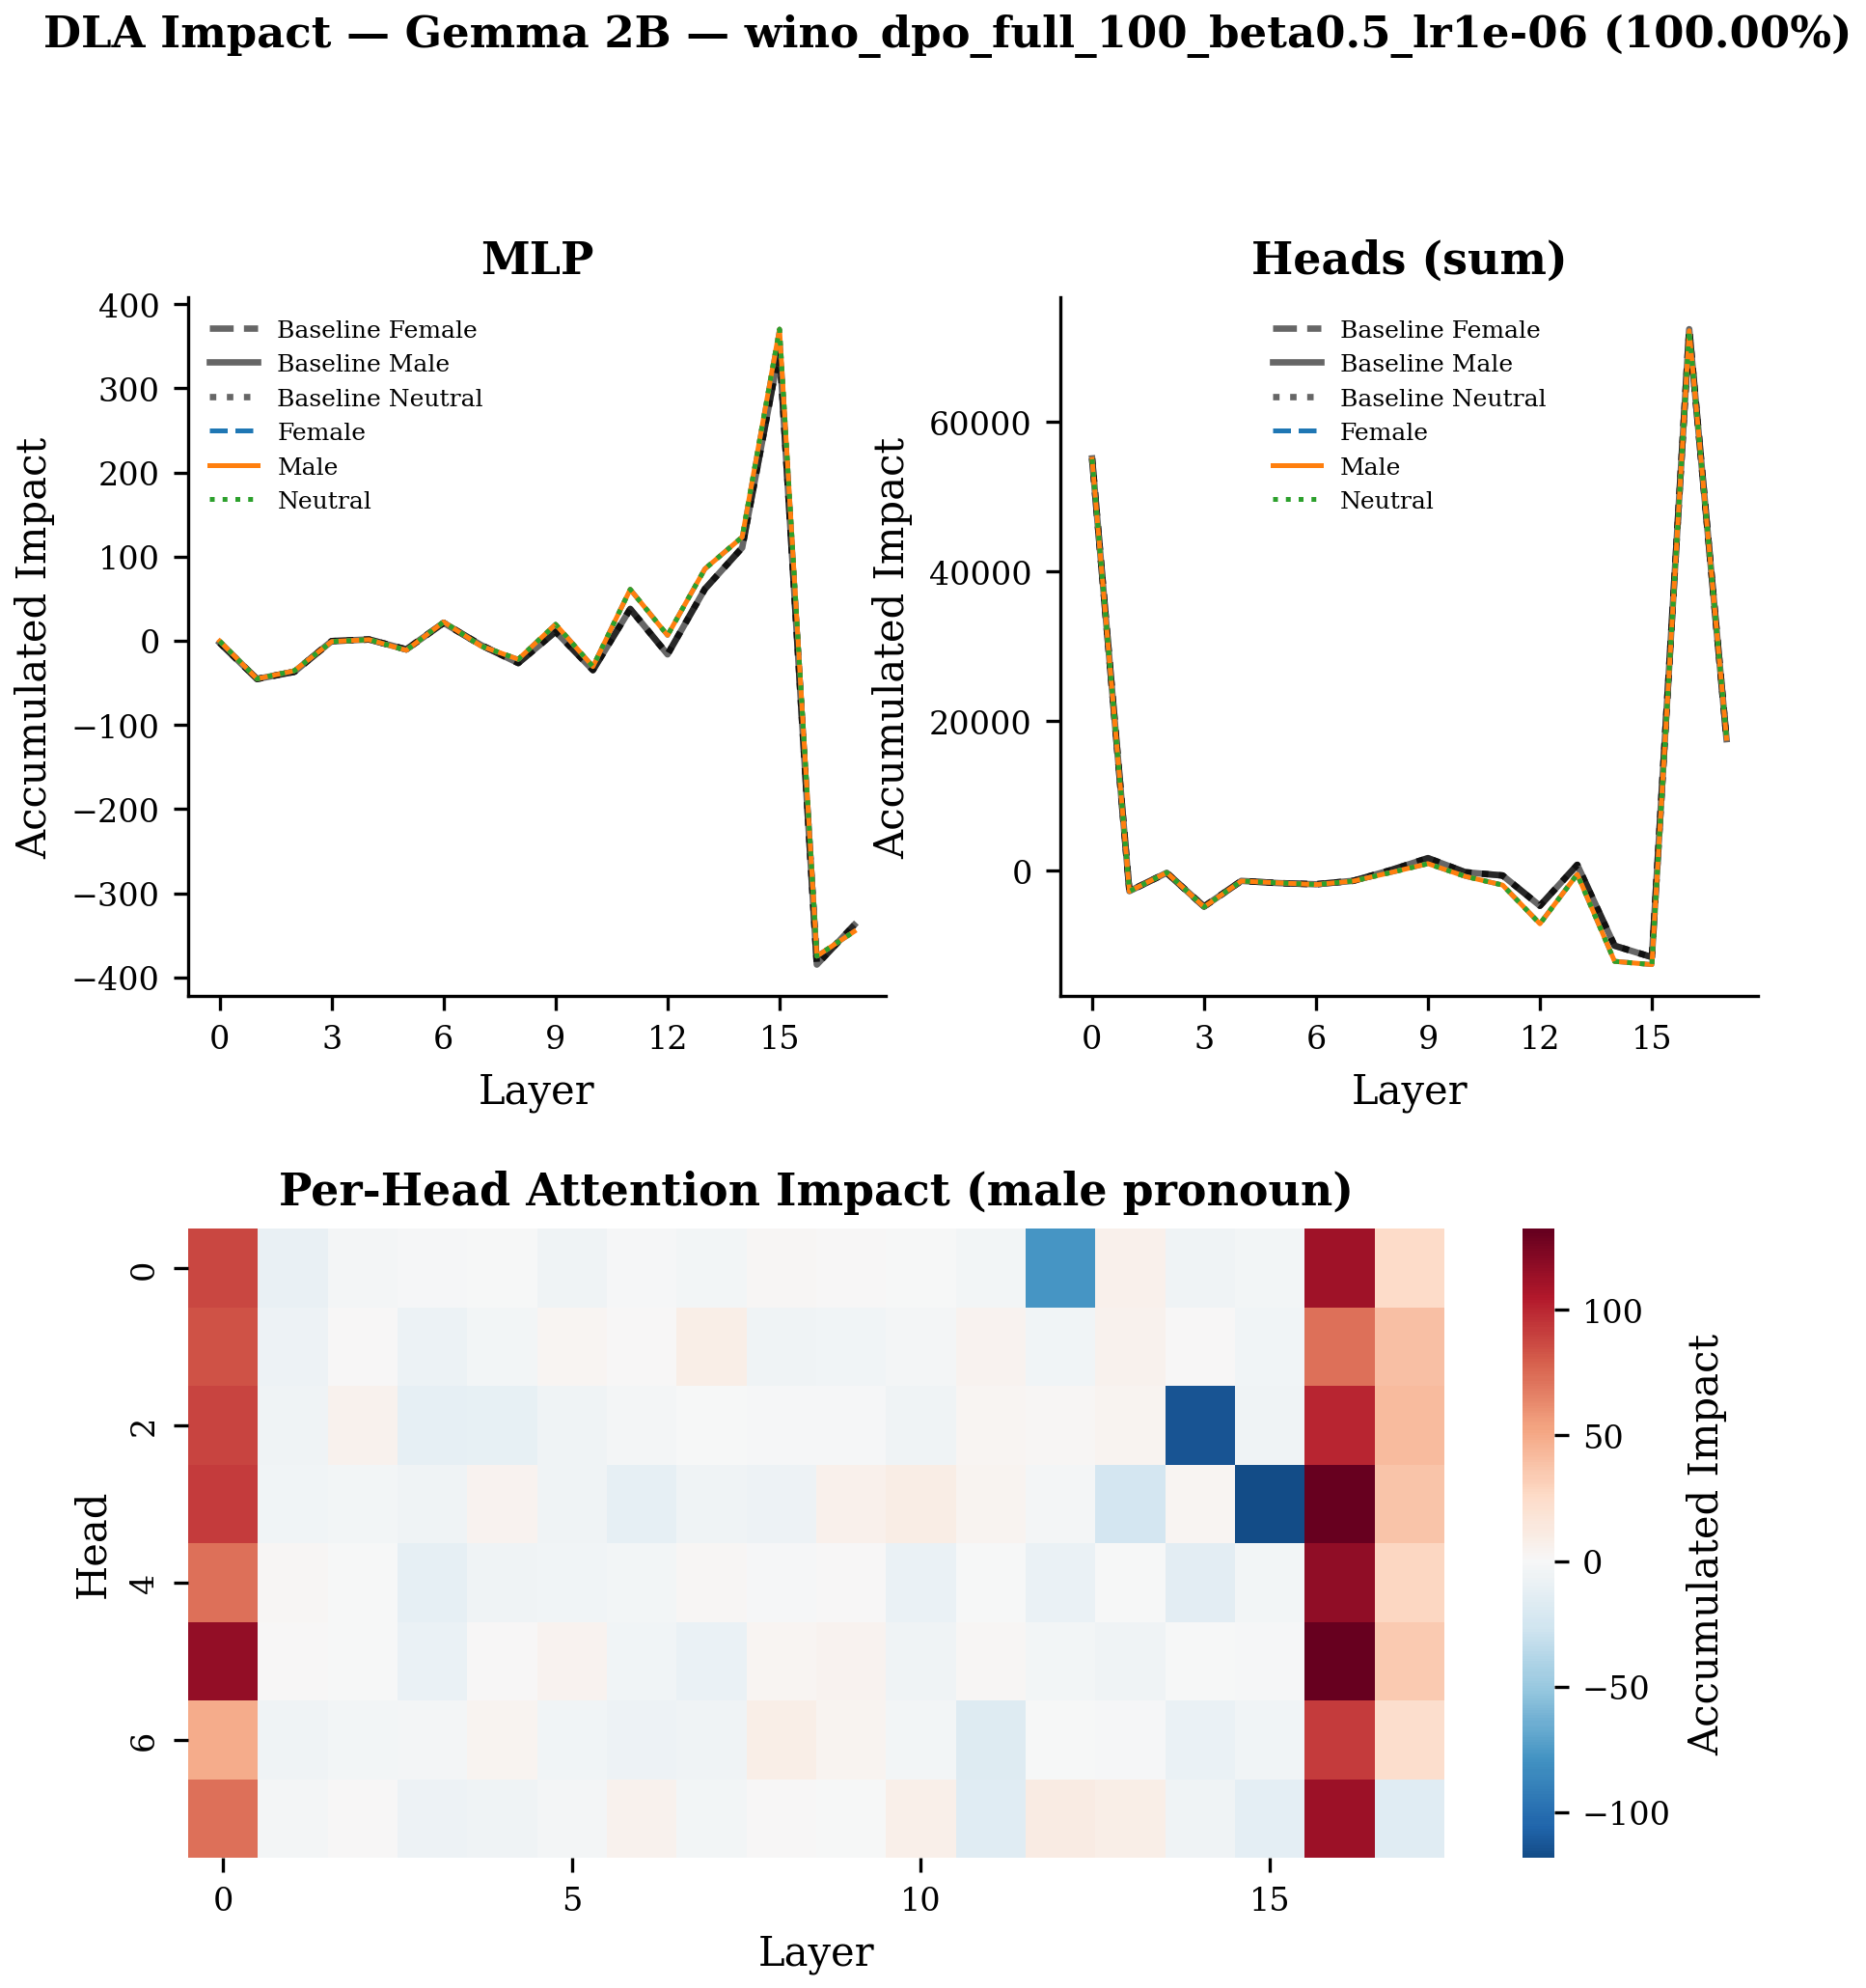

/tmp/ipykernel_603517/2614398281.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


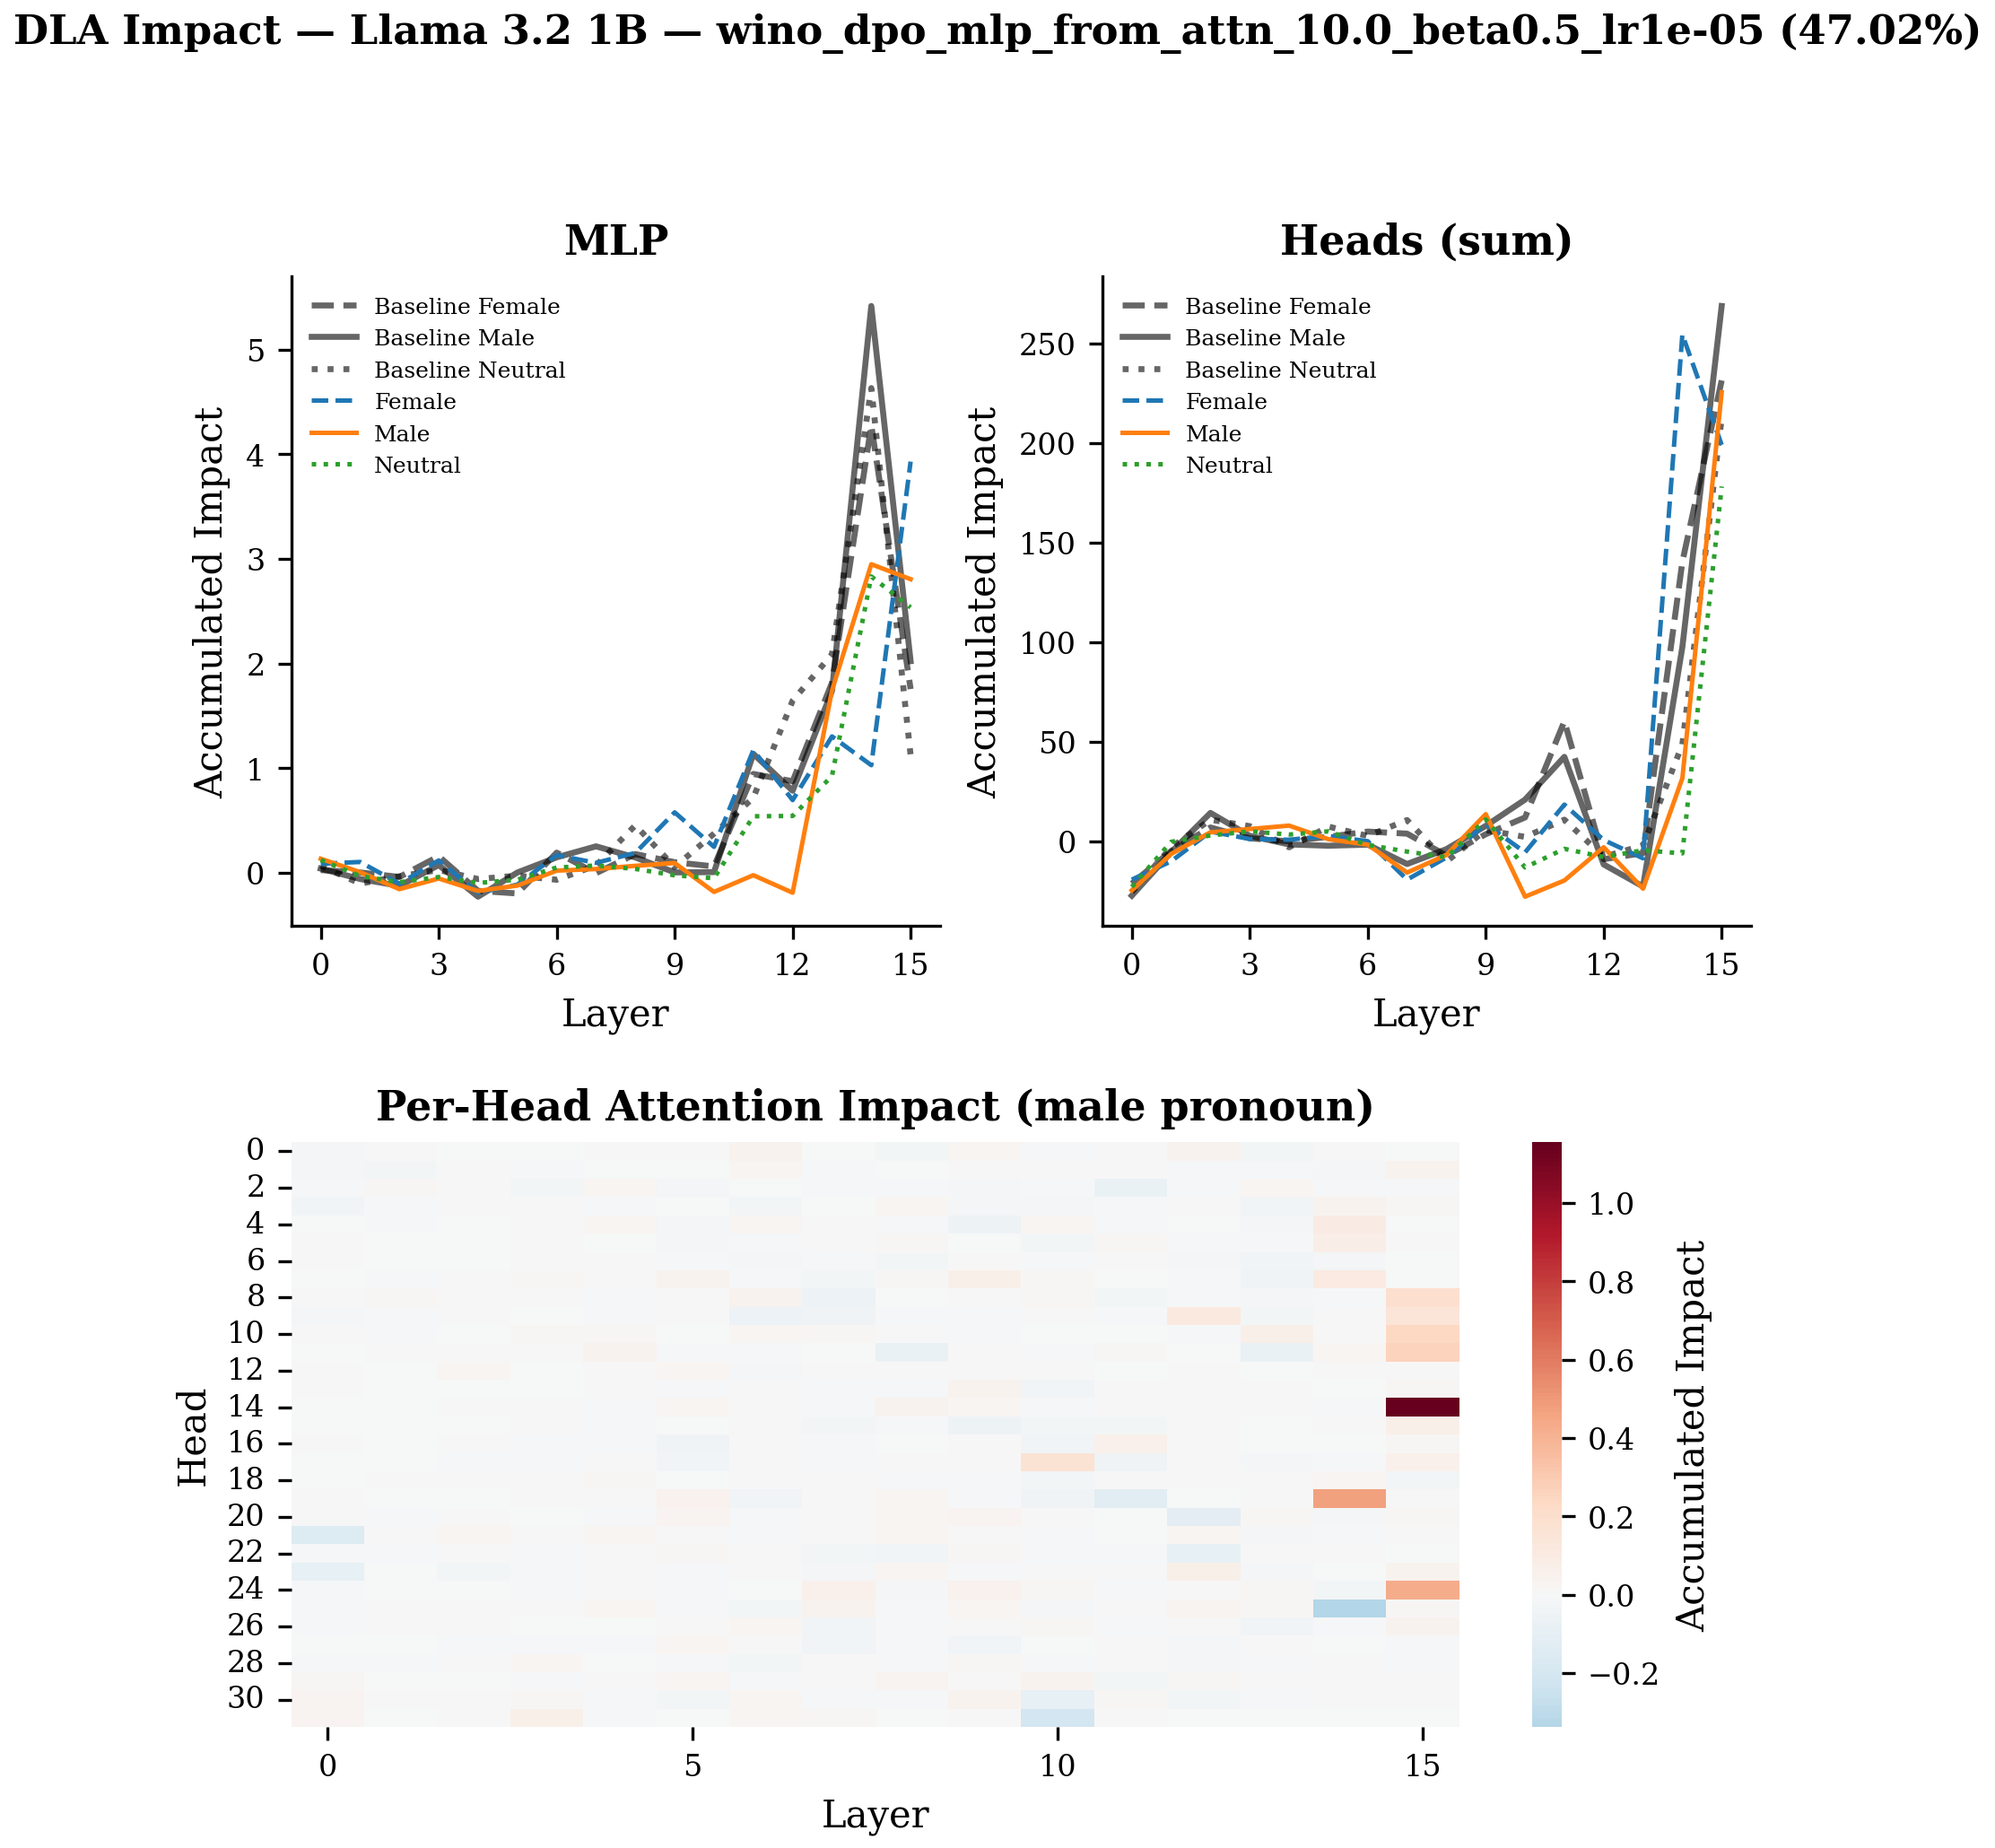

/tmp/ipykernel_603517/2614398281.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


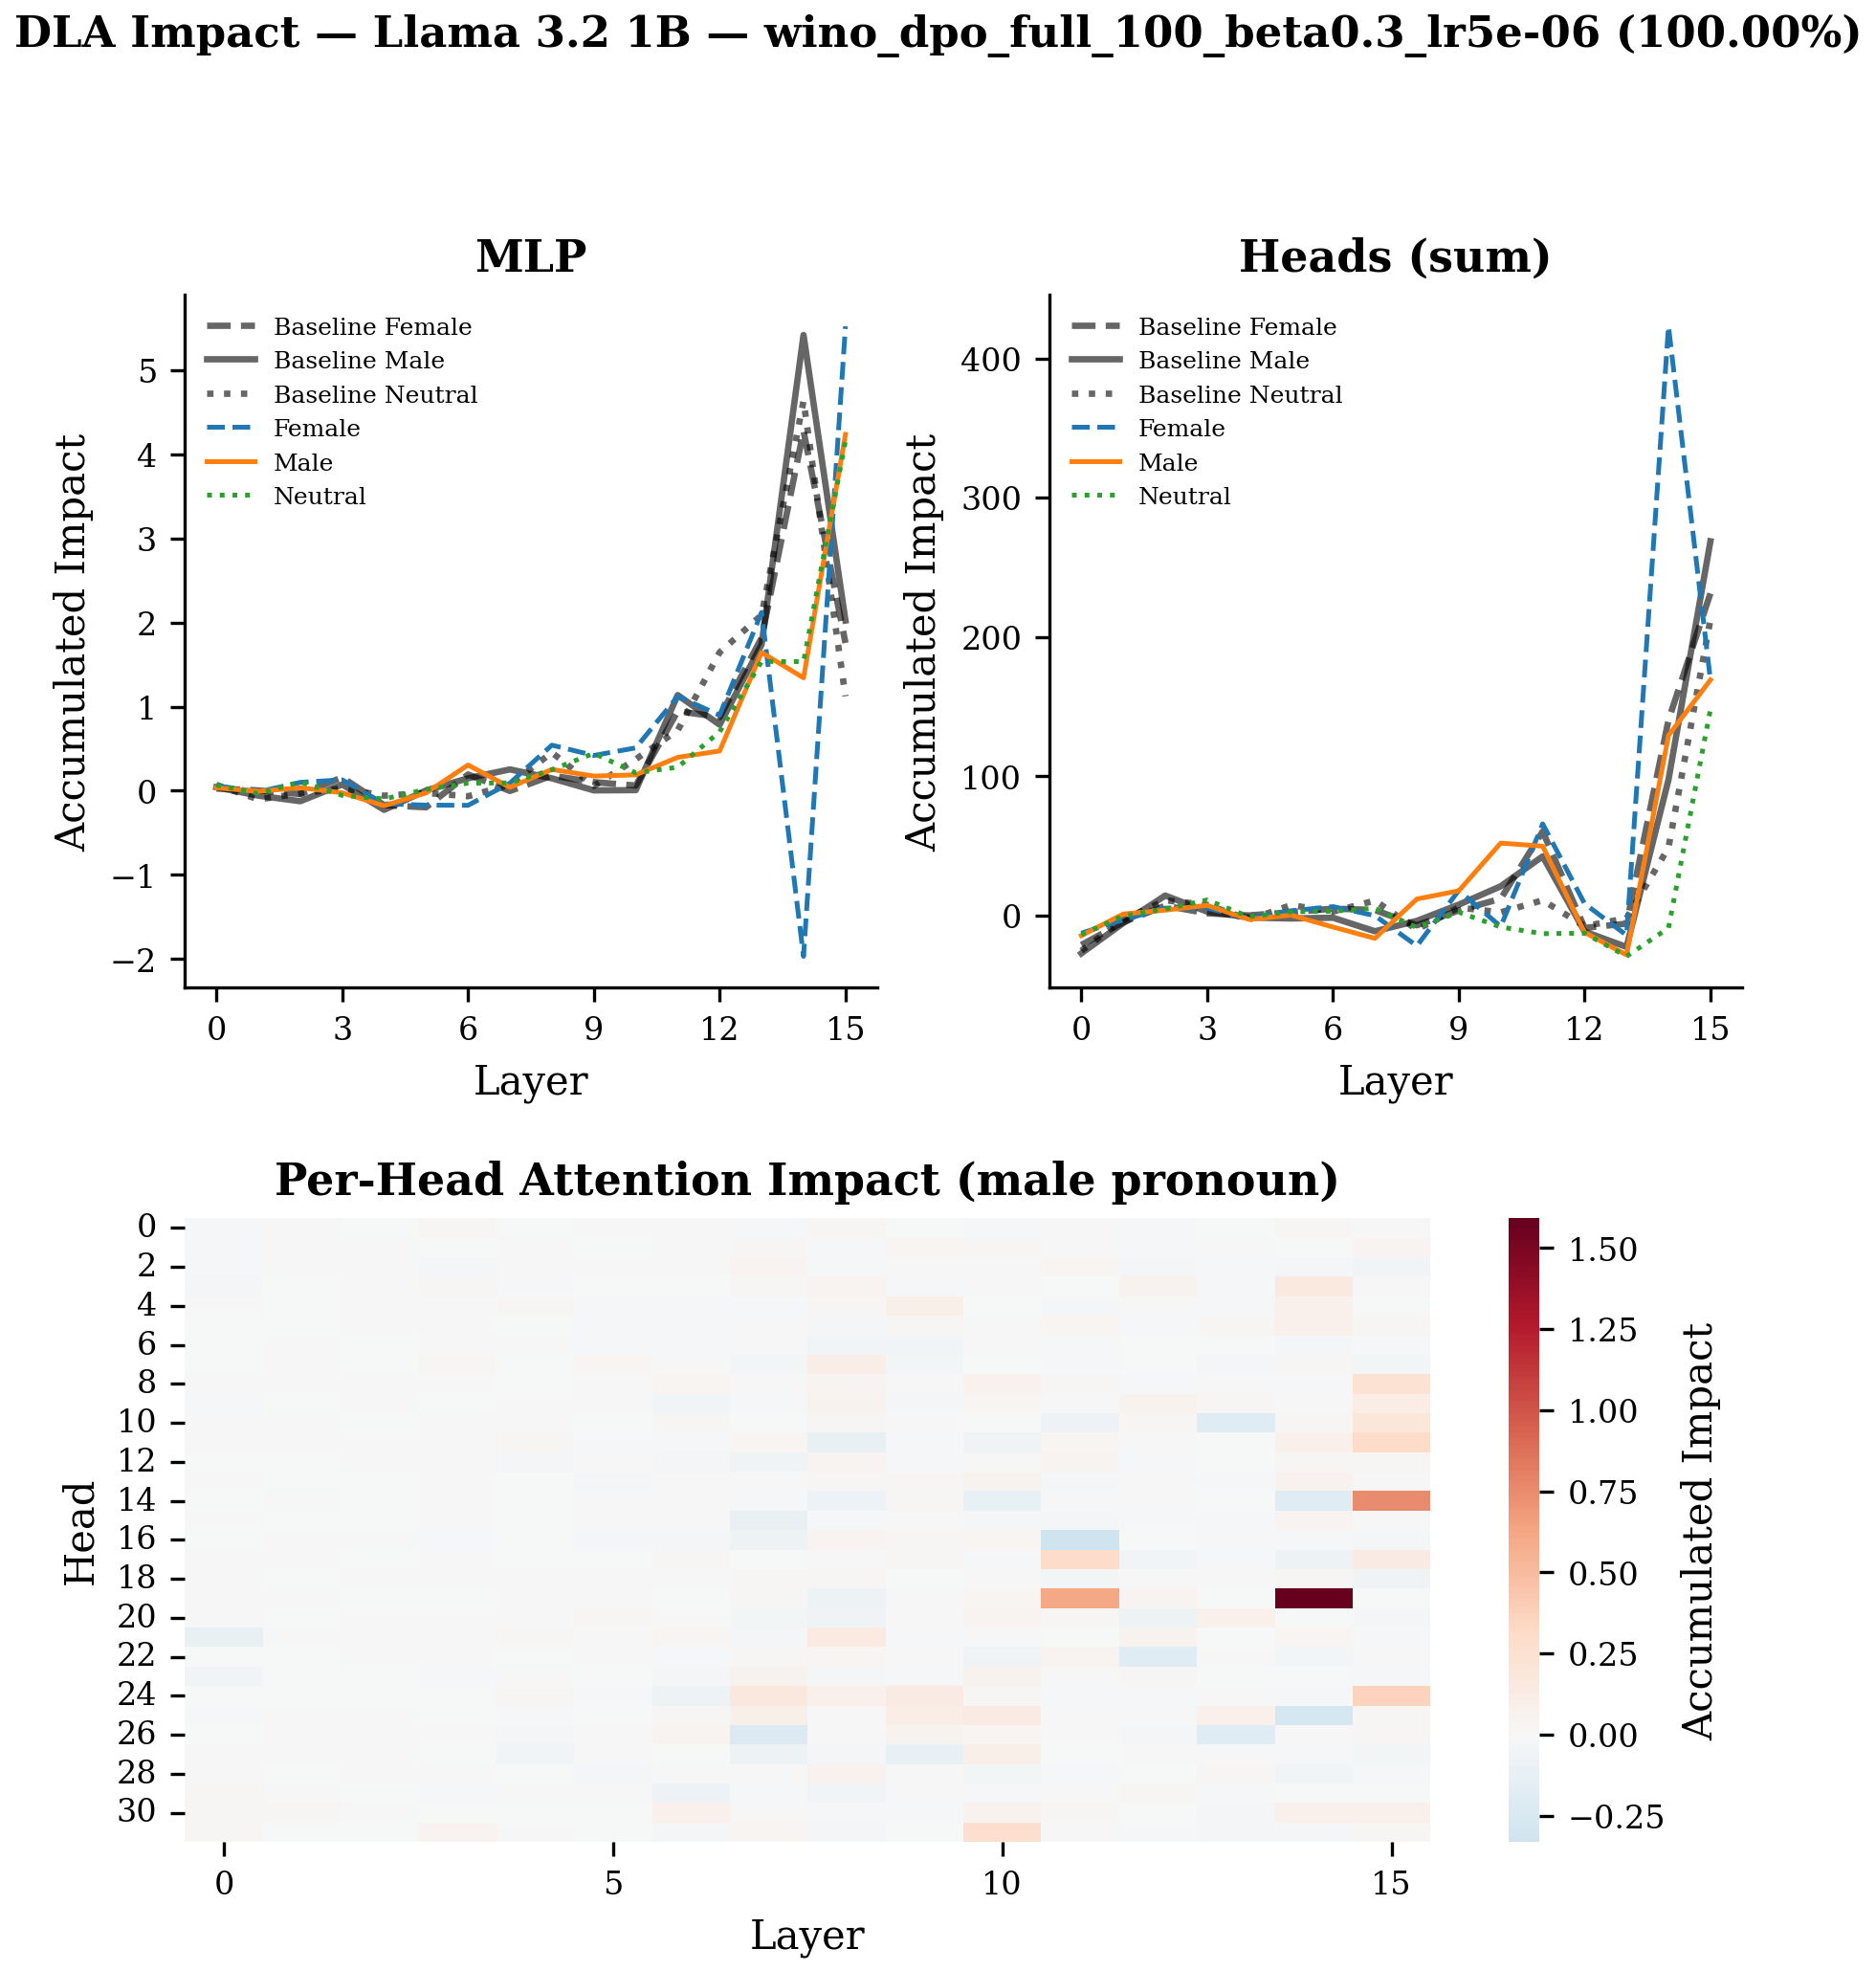

In [46]:
def _impact_summary(impact_df):
    """Aggregate MLP and Head-sum impact per (Layer, Gender)."""
    mlp = impact_df[impact_df["Component"] == "MLP"].copy()
    mlp_agg = mlp.groupby(["Layer", "Gender"])["Accumulated_Impact"].mean().reset_index()
    mlp_agg["Component"] = "MLP"

    heads = impact_df[impact_df["Component"].str.startswith("Head")].copy()
    head_sum = heads.groupby(["Layer", "Gender"])["Accumulated_Impact"].sum().reset_index()
    head_sum["Component"] = "Heads (sum)"

    return pd.concat([mlp_agg, head_sum], ignore_index=True)


def _head_heatmap_matrix(impact_df, gender="male"):
    """Build Head_ID x Layer matrix of mean accumulated impact for one gender."""
    head_df = impact_df[impact_df["Component"].str.startswith("Head")].copy()
    head_df["Head_ID"] = head_df["Component"].str.replace("Head_", "").astype(int)
    subset = head_df[head_df["Gender"] == gender]
    return subset.groupby(["Head_ID", "Layer"])["Accumulated_Impact"].mean().unstack()


for model_name in model_names:
    sel = selections[model_name]
    run_impacts = all_data[model_name]["run_impacts"]
    mdf = all_data[model_name]["metrics"]
    dla_runs = sel["top5_dla"]
    best_full = sel["best_full"]
    safe_key = model_name.replace(" ", "_").replace(".", "")

    baseline_impact = run_impacts.get("original_baseline")
    bl_summary = _impact_summary(baseline_impact) if baseline_impact is not None else None

    best_dla_rid = dla_runs.iloc[0]["run_id"] if not dla_runs.empty else None

    run_ids_to_plot = []
    if best_dla_rid and run_impacts.get(best_dla_rid) is not None:
        r_row = dla_runs.iloc[0]
        run_ids_to_plot.append((best_dla_rid, r_row.get("active_pct")))
    if not best_full.empty:
        frid = best_full.iloc[0]["run_id"]
        if run_impacts.get(frid) is not None:
            run_ids_to_plot.append((frid, best_full.iloc[0].get("active_pct")))

    for rid, active_pct in run_ids_to_plot:
        impact = run_impacts[rid]
        summary = _impact_summary(impact)
        head_matrix = _head_heatmap_matrix(impact, gender="male")

        fig = plt.figure(figsize=(7.0, 7.0))
        gs = fig.add_gridspec(2, 2, height_ratios=[1, 0.9], hspace=0.35, wspace=0.25)
        ax_mlp = fig.add_subplot(gs[0, 0])
        ax_sum = fig.add_subplot(gs[0, 1])
        ax_heat = fig.add_subplot(gs[1, :])

        for ax, comp in zip([ax_mlp, ax_sum], ["MLP", "Heads (sum)"]):
            if bl_summary is not None:
                bl_comp = bl_summary[bl_summary["Component"] == comp]
                for gender, gdf in bl_comp.groupby("Gender"):
                    style = "-" if gender == "male" else ("--" if gender == "female" else ":")
                    ax.plot(gdf["Layer"], gdf["Accumulated_Impact"],
                            linewidth=1.6, linestyle=style, color=BASELINE_COLOR,
                            alpha=0.6, label=f"Baseline {gender.capitalize()}", zorder=2)

            comp_data = summary[summary["Component"] == comp]
            for gender, gdf in comp_data.groupby("Gender"):
                style = "-" if gender == "male" else ("--" if gender == "female" else ":")
                ax.plot(gdf["Layer"], gdf["Accumulated_Impact"],
                        linewidth=1.2, linestyle=style,
                        label=f"{gender.capitalize()}", zorder=3)
            ax.set_xlabel("Layer")
            ax.set_ylabel("Accumulated Impact")
            ax.set_title(comp, fontweight="bold")
            ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True, nbins=8))
            ax.legend(frameon=False, fontsize=6)
            sns.despine(ax=ax)

        if not head_matrix.empty:
            sns.heatmap(head_matrix, cmap="RdBu_r", center=0, ax=ax_heat,
                        xticklabels=5, yticklabels=2,
                        cbar_kws={"label": "Accumulated Impact"})
            ax_heat.set_title("Per-Head Attention Impact (male pronoun)", fontweight="bold")
            ax_heat.set_xlabel("Layer")
            ax_heat.set_ylabel("Head")

        pct_str = f"{active_pct:.2f}" if pd.notna(active_pct) else "?"
        fig.suptitle(f"DLA Impact — {model_name} — {rid} ({pct_str}%)",
                     fontweight="bold", y=1.02)
        plt.tight_layout()
        plt.show()

        safe_rid = rid.replace(" ", "_")
        FIGURES[f"dla_impact_{safe_rid}_{safe_key}"] = fig

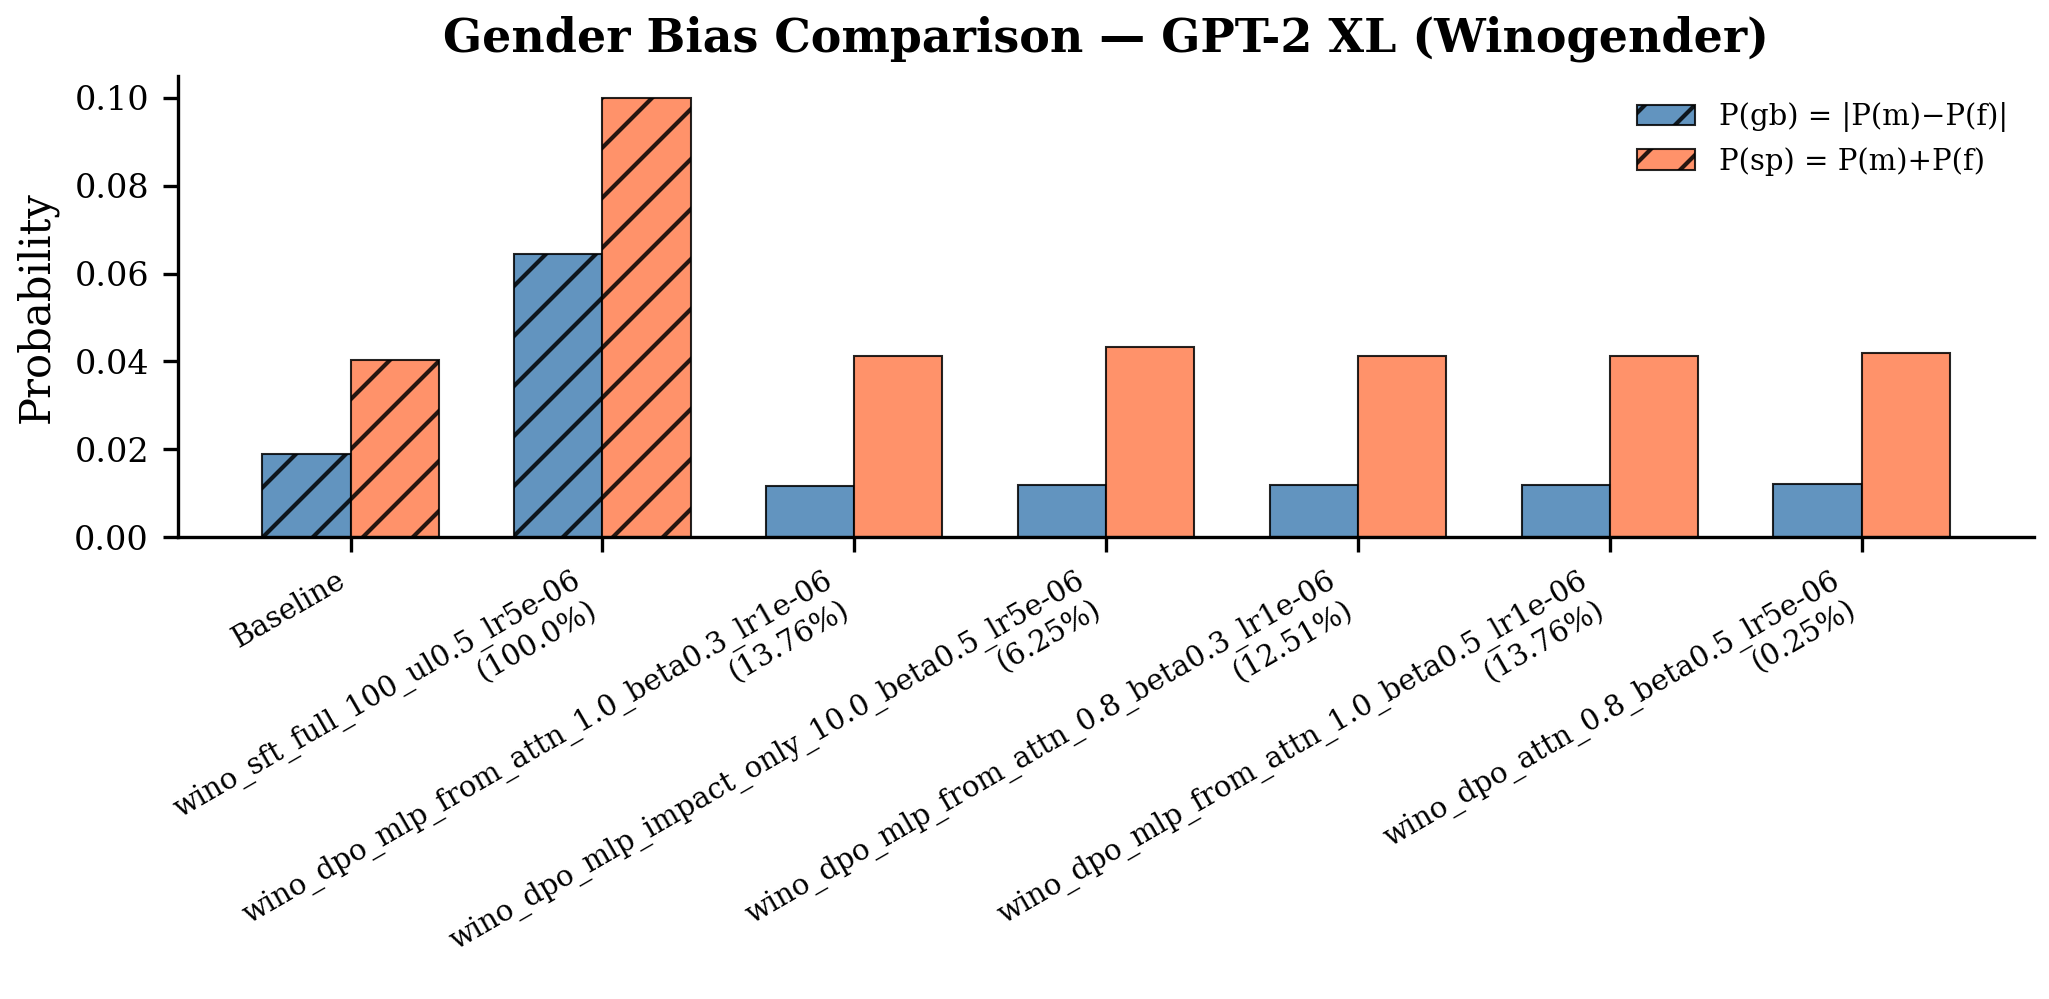

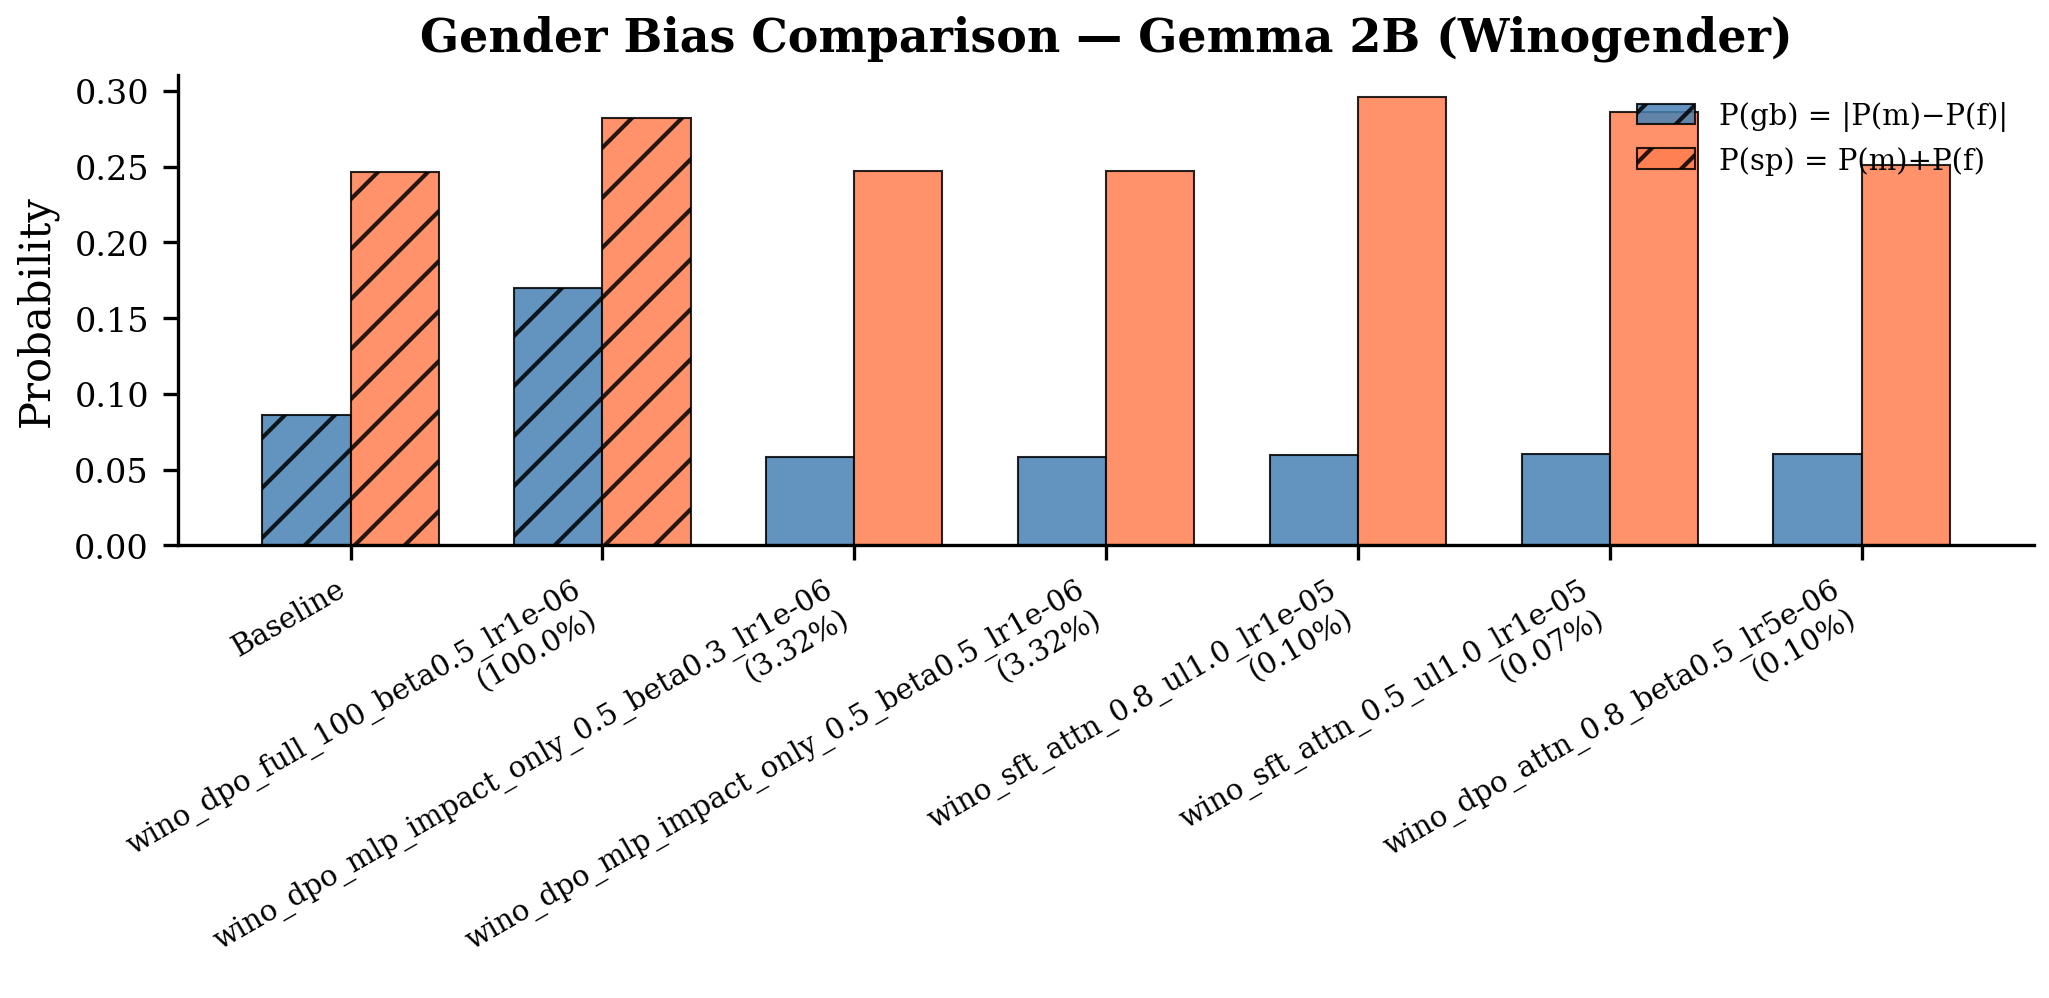

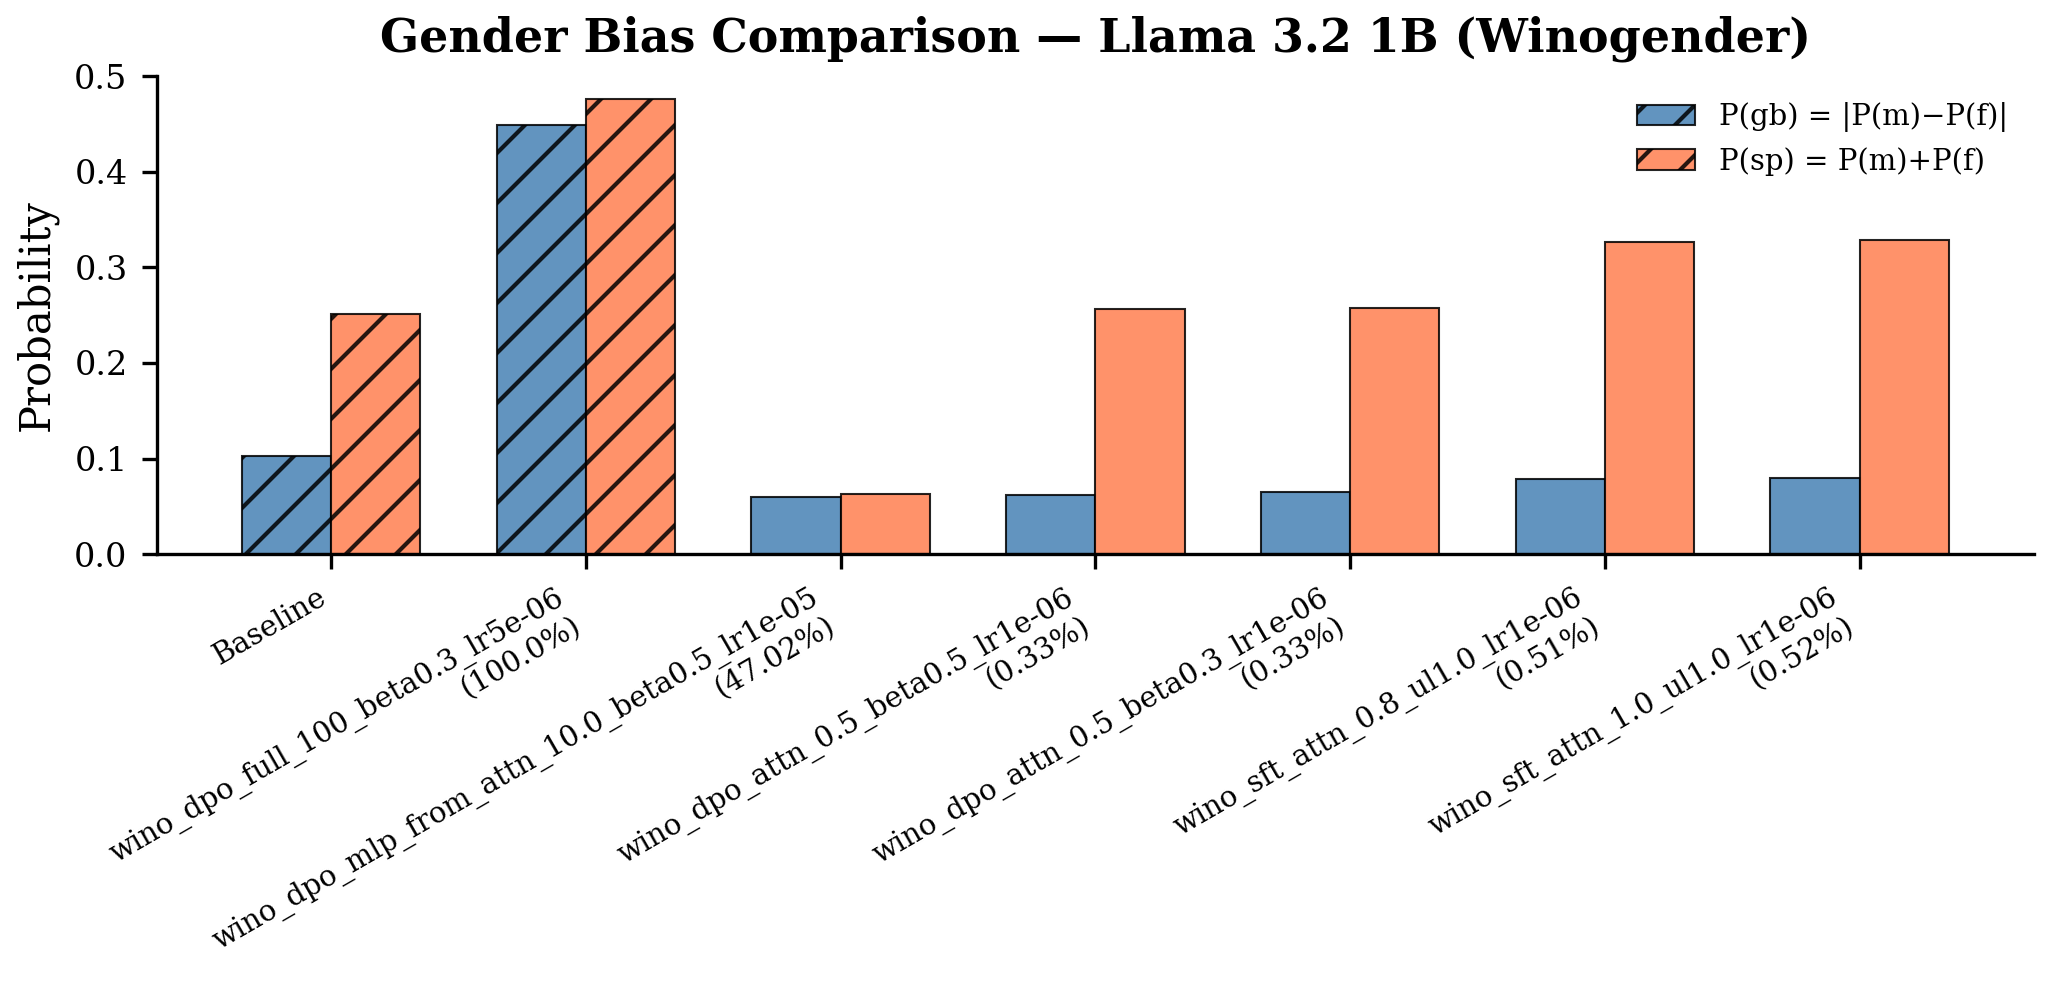

In [47]:
for model_name in model_names:
    sel = selections[model_name]
    run_pgb_dict = sel["run_pgb"]
    dla_runs = sel["top5_dla"]
    best_full = sel["best_full"]
    safe_key = model_name.replace(" ", "_").replace(".", "")

    labels, pgb_vals, psp_vals = [], [], []

    bl = run_pgb_dict["original_baseline"]
    labels.append("Baseline")
    pgb_vals.append(bl["pgb"])
    psp_vals.append(bl["psp"])

    if not best_full.empty:
        r = best_full.iloc[0]
        pct = f"{r['active_pct']:.1f}" if pd.notna(r.get("active_pct")) else "100"
        labels.append(f"{r['run_id']}\n({pct}%)")
        rp = run_pgb_dict.get(r["run_id"], {})
        pgb_vals.append(rp.get("pgb", 0))
        psp_vals.append(rp.get("psp", 0))

    for _, r in dla_runs.iterrows():
        labels.append(f"{r['run_id']}\n({r['active_pct']:.2f}%)")
        rp = run_pgb_dict.get(r["run_id"], {})
        pgb_vals.append(rp.get("pgb", 0))
        psp_vals.append(rp.get("psp", 0))

    x = np.arange(len(labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(7.0, 3.5))

    bars_pgb = ax.bar(x - width / 2, pgb_vals, width, label="P(gb) = |P(m)−P(f)|",
                       color="steelblue", edgecolor="black", linewidth=0.5, alpha=0.85)
    bars_psp = ax.bar(x + width / 2, psp_vals, width, label="P(sp) = P(m)+P(f)",
                       color="coral", edgecolor="black", linewidth=0.5, alpha=0.85)

    bars_pgb[0].set_hatch("//")
    bars_psp[0].set_hatch("//")
    if not best_full.empty and len(bars_pgb) > 1:
        bars_pgb[1].set_hatch("//")
        bars_psp[1].set_hatch("//")

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=7, rotation=30, ha="right")
    ax.set_ylabel("Probability")
    ax.set_title(f"Gender Bias Comparison — {model_name} (Winogender)", fontweight="bold")
    ax.legend(frameon=False, fontsize=7, loc="upper right")
    sns.despine(ax=ax)

    plt.tight_layout()
    plt.show()

    FIGURES[f"pgb_comparison_{safe_key}"] = fig

In [48]:
for model_name in model_names:
    run_probs = all_data[model_name]["run_probs"]
    mdf = all_data[model_name]["metrics"]

    baseline_pgb_val = compute_avg_pgb(run_probs["original_baseline"])

    baseline_psp_val = compute_avg_psp(run_probs["original_baseline"])

    rows = []
    for rid, prob_df in run_probs.items():
        pgb = compute_avg_pgb(prob_df)
        psp = compute_avg_psp(prob_df)
        red = (baseline_pgb_val - pgb) / baseline_pgb_val * 100 if baseline_pgb_val > 0 else 0.0
        meta_match = mdf[mdf["run_id"] == rid]
        meta = meta_match.iloc[0] if not meta_match.empty else None
        r_ppl = meta["ppl"] if meta is not None and pd.notna(meta.get("ppl")) else None
        r_ppl_ratio = meta["ppl_ratio"] if meta is not None and pd.notna(meta.get("ppl_ratio")) else None
        rows.append({
            "Run ID": rid,
            "Active (%)": meta["active_pct"] if meta is not None and pd.notna(meta.get("active_pct")) else None,
            "Avg P(gb)": pgb,
            "Reduction (%)": red,
            "P(sp)": psp,
            "SS_deviation": meta["SS_deviation"] if meta is not None and pd.notna(meta.get("SS_deviation")) else None,
            "PPL": r_ppl,
            "PPL Ratio": r_ppl_ratio,
        })

    pgb_df = pd.DataFrame(rows).sort_values("Reduction (%)", ascending=False).reset_index(drop=True)

    fmt_df = pgb_df.copy()
    fmt_df["Active (%)"] = fmt_df["Active (%)"].apply(lambda v: f"{v:.2f}" if pd.notna(v) else "-")
    fmt_df["Avg P(gb)"] = fmt_df["Avg P(gb)"].apply(lambda v: f"{v:.6f}")
    fmt_df["Reduction (%)"] = fmt_df["Reduction (%)"].apply(lambda v: f"{v:+.2f}")
    fmt_df["P(sp)"] = fmt_df["P(sp)"].apply(lambda v: f"{v:.6f}")
    fmt_df["SS_deviation"] = fmt_df["SS_deviation"].apply(lambda v: f"{v:.2f}" if pd.notna(v) else "-")
    fmt_df["PPL"] = fmt_df["PPL"].apply(lambda v: f"{v:.2f}" if pd.notna(v) else "-")
    fmt_df["PPL Ratio"] = fmt_df["PPL Ratio"].apply(lambda v: f"{v:.3f}" if pd.notna(v) else "-")

    safe_label = model_name.replace(" ", "_").replace(".", "")
    display(fmt_df.style.set_caption(
        f"{model_name} — Average Gender Bias P(gb) = |P(male) - P(female)| (all runs, sorted by reduction)"
    ))
    print(f"\nLaTeX ({model_name}):\n")
    print(fmt_df.to_latex(
        index=False,
        caption=f"{model_name} — Average Gender Bias Reduction (all runs)",
        label=f"tab:wino_pgb_all_{safe_label}",
    ))

,Run ID,Active (%),Avg P(gb),Reduction (%),P(sp),SS_deviation
0,wino_dpo_random_mlp_5.0_beta0.5_lr5e-06_seed42,3.75,0.011551,+39.20,0.041836,28.31
1,wino_dpo_mlp_from_attn_1.0_beta0.3_lr1e-06,13.76,0.011753,+38.14,0.041309,28.31
2,wino_dpo_random_mlp_5.0_beta0.5_lr5e-06_seed789,3.75,0.011756,+38.13,0.044090,24.70
3,wino_dpo_mlp_impact_only_10.0_beta0.5_lr5e-06,6.25,0.011820,+37.79,0.043287,21.08
4,wino_dpo_mlp_from_attn_0.8_beta0.3_lr1e-06,12.51,0.011904,+37.35,0.041252,28.31
5,wino_dpo_random_mlp_5.0_beta0.5_lr5e-06_seed1024,3.75,0.011932,+37.20,0.042557,22.29
6,wino_dpo_mlp_from_attn_1.0_beta0.5_lr1e-06,13.76,0.011961,+37.04,0.041190,28.31
7,wino_dpo_attn_0.8_beta0.5_lr5e-06,0.25,0.012062,+36.51,0.041886,27.11
8,wino_dpo_mlp_from_attn_0.8_beta0.5_lr1e-06,12.51,0.012064,+36.50,0.041089,28.31
9,wino_dpo_attn_1.0_beta0.5_lr5e-06,0.30,0.012068,+36.49,0.041910,27.11



LaTeX (GPT-2 XL):

\begin{table}
\caption{GPT-2 XL — Average Gender Bias Reduction (all runs)}
\label{tab:wino_pgb_all_GPT-2_XL}
\begin{tabular}{llllll}
\toprule
Run ID & Active (%) & Avg P(gb) & Reduction (%) & P(sp) & SS_deviation \\
\midrule
wino_dpo_random_mlp_5.0_beta0.5_lr5e-06_seed42 & 3.75 & 0.011551 & +39.20 & 0.041836 & 28.31 \\
wino_dpo_mlp_from_attn_1.0_beta0.3_lr1e-06 & 13.76 & 0.011753 & +38.14 & 0.041309 & 28.31 \\
wino_dpo_random_mlp_5.0_beta0.5_lr5e-06_seed789 & 3.75 & 0.011756 & +38.13 & 0.044090 & 24.70 \\
wino_dpo_mlp_impact_only_10.0_beta0.5_lr5e-06 & 6.25 & 0.011820 & +37.79 & 0.043287 & 21.08 \\
wino_dpo_mlp_from_attn_0.8_beta0.3_lr1e-06 & 12.51 & 0.011904 & +37.35 & 0.041252 & 28.31 \\
wino_dpo_random_mlp_5.0_beta0.5_lr5e-06_seed1024 & 3.75 & 0.011932 & +37.20 & 0.042557 & 22.29 \\
wino_dpo_mlp_from_attn_1.0_beta0.5_lr1e-06 & 13.76 & 0.011961 & +37.04 & 0.041190 & 28.31 \\
wino_dpo_attn_0.8_beta0.5_lr5e-06 & 0.25 & 0.012062 & +36.51 & 0.041886 & 27.11 \\
wino_d

,Run ID,Active (%),Avg P(gb),Reduction (%),P(sp),SS_deviation
0,wino_dpo_mlp_impact_only_0.5_beta0.3_lr1e-06,3.32,0.058310,+32.25,0.247386,25.90
1,wino_dpo_mlp_impact_only_0.5_beta0.5_lr1e-06,3.32,0.058383,+32.16,0.247049,28.31
2,wino_sft_attn_0.8_ul1.0_lr1e-05,0.10,0.059992,+30.29,0.295717,21.08
3,wino_sft_attn_0.5_ul1.0_lr1e-05,0.07,0.060444,+29.77,0.286409,23.49
4,wino_dpo_attn_0.8_beta0.5_lr5e-06,0.10,0.060476,+29.73,0.251047,21.08
5,wino_dpo_attn_0.8_beta0.3_lr5e-06,0.10,0.060571,+29.62,0.250682,23.49
6,wino_sft_attn_5.0_ul1.0_lr5e-06,0.35,0.060983,+29.14,0.289598,25.90
7,wino_sft_mlp_impact_only_10.0_ul1.0_lr1e-06,6.64,0.061652,+28.36,0.283658,28.31
8,wino_dpo_attn_0.5_beta0.3_lr5e-06,0.07,0.061825,+28.16,0.251530,27.11
9,wino_dpo_attn_0.5_beta0.5_lr5e-06,0.07,0.062173,+27.76,0.252003,25.90



LaTeX (Gemma 2B):

\begin{table}
\caption{Gemma 2B — Average Gender Bias Reduction (all runs)}
\label{tab:wino_pgb_all_Gemma_2B}
\begin{tabular}{llllll}
\toprule
Run ID & Active (%) & Avg P(gb) & Reduction (%) & P(sp) & SS_deviation \\
\midrule
wino_dpo_mlp_impact_only_0.5_beta0.3_lr1e-06 & 3.32 & 0.058310 & +32.25 & 0.247386 & 25.90 \\
wino_dpo_mlp_impact_only_0.5_beta0.5_lr1e-06 & 3.32 & 0.058383 & +32.16 & 0.247049 & 28.31 \\
wino_sft_attn_0.8_ul1.0_lr1e-05 & 0.10 & 0.059992 & +30.29 & 0.295717 & 21.08 \\
wino_sft_attn_0.5_ul1.0_lr1e-05 & 0.07 & 0.060444 & +29.77 & 0.286409 & 23.49 \\
wino_dpo_attn_0.8_beta0.5_lr5e-06 & 0.10 & 0.060476 & +29.73 & 0.251047 & 21.08 \\
wino_dpo_attn_0.8_beta0.3_lr5e-06 & 0.10 & 0.060571 & +29.62 & 0.250682 & 23.49 \\
wino_sft_attn_5.0_ul1.0_lr5e-06 & 0.35 & 0.060983 & +29.14 & 0.289598 & 25.90 \\
wino_sft_mlp_impact_only_10.0_ul1.0_lr1e-06 & 6.64 & 0.061652 & +28.36 & 0.283658 & 28.31 \\
wino_dpo_attn_0.5_beta0.3_lr5e-06 & 0.07 & 0.061825 & +28.16 & 0

,Run ID,Active (%),Avg P(gb),Reduction (%),P(sp),SS_deviation
0,wino_dpo_mlp_from_attn_10.0_beta0.5_lr1e-05,47.02,0.059899,+41.65,0.063172,6.63
1,wino_dpo_attn_0.5_beta0.5_lr1e-06,0.33,0.061997,+39.61,0.256138,25.90
2,wino_dpo_attn_0.5_beta0.3_lr1e-06,0.33,0.064733,+36.94,0.257743,21.08
3,wino_dpo_random_attn_1.0_beta0.3_lr1e-06_seed456,0.66,0.068512,+33.26,0.254420,25.90
4,wino_dpo_random_attn_0.8_beta0.3_lr1e-06_seed456,0.51,0.069405,+32.39,0.255187,24.70
5,wino_dpo_random_attn_0.8_beta0.3_lr1e-06_seed789,0.65,0.069747,+32.06,0.252882,18.67
6,wino_dpo_full_100_beta0.5_lr5e-06,100.00,0.073205,+28.69,0.098558,3.01
7,wino_dpo_random_attn_1.0_beta0.3_lr1e-06_seed1024,0.80,0.073253,+28.64,0.251810,15.06
8,wino_dpo_random_attn_0.8_beta0.3_lr1e-06_seed1024,0.79,0.076195,+25.78,0.251961,13.86
9,wino_sft_attn_0.8_ul1.0_lr1e-06,0.51,0.078959,+23.08,0.326308,18.67



LaTeX (Llama 3.2 1B):

\begin{table}
\caption{Llama 3.2 1B — Average Gender Bias Reduction (all runs)}
\label{tab:wino_pgb_all_Llama_32_1B}
\begin{tabular}{llllll}
\toprule
Run ID & Active (%) & Avg P(gb) & Reduction (%) & P(sp) & SS_deviation \\
\midrule
wino_dpo_mlp_from_attn_10.0_beta0.5_lr1e-05 & 47.02 & 0.059899 & +41.65 & 0.063172 & 6.63 \\
wino_dpo_attn_0.5_beta0.5_lr1e-06 & 0.33 & 0.061997 & +39.61 & 0.256138 & 25.90 \\
wino_dpo_attn_0.5_beta0.3_lr1e-06 & 0.33 & 0.064733 & +36.94 & 0.257743 & 21.08 \\
wino_dpo_random_attn_1.0_beta0.3_lr1e-06_seed456 & 0.66 & 0.068512 & +33.26 & 0.254420 & 25.90 \\
wino_dpo_random_attn_0.8_beta0.3_lr1e-06_seed456 & 0.51 & 0.069405 & +32.39 & 0.255187 & 24.70 \\
wino_dpo_random_attn_0.8_beta0.3_lr1e-06_seed789 & 0.65 & 0.069747 & +32.06 & 0.252882 & 18.67 \\
wino_dpo_full_100_beta0.5_lr5e-06 & 100.00 & 0.073205 & +28.69 & 0.098558 & 3.01 \\
wino_dpo_random_attn_1.0_beta0.3_lr1e-06_seed1024 & 0.80 & 0.073253 & +28.64 & 0.251810 & 15.06 \\
wino_dp

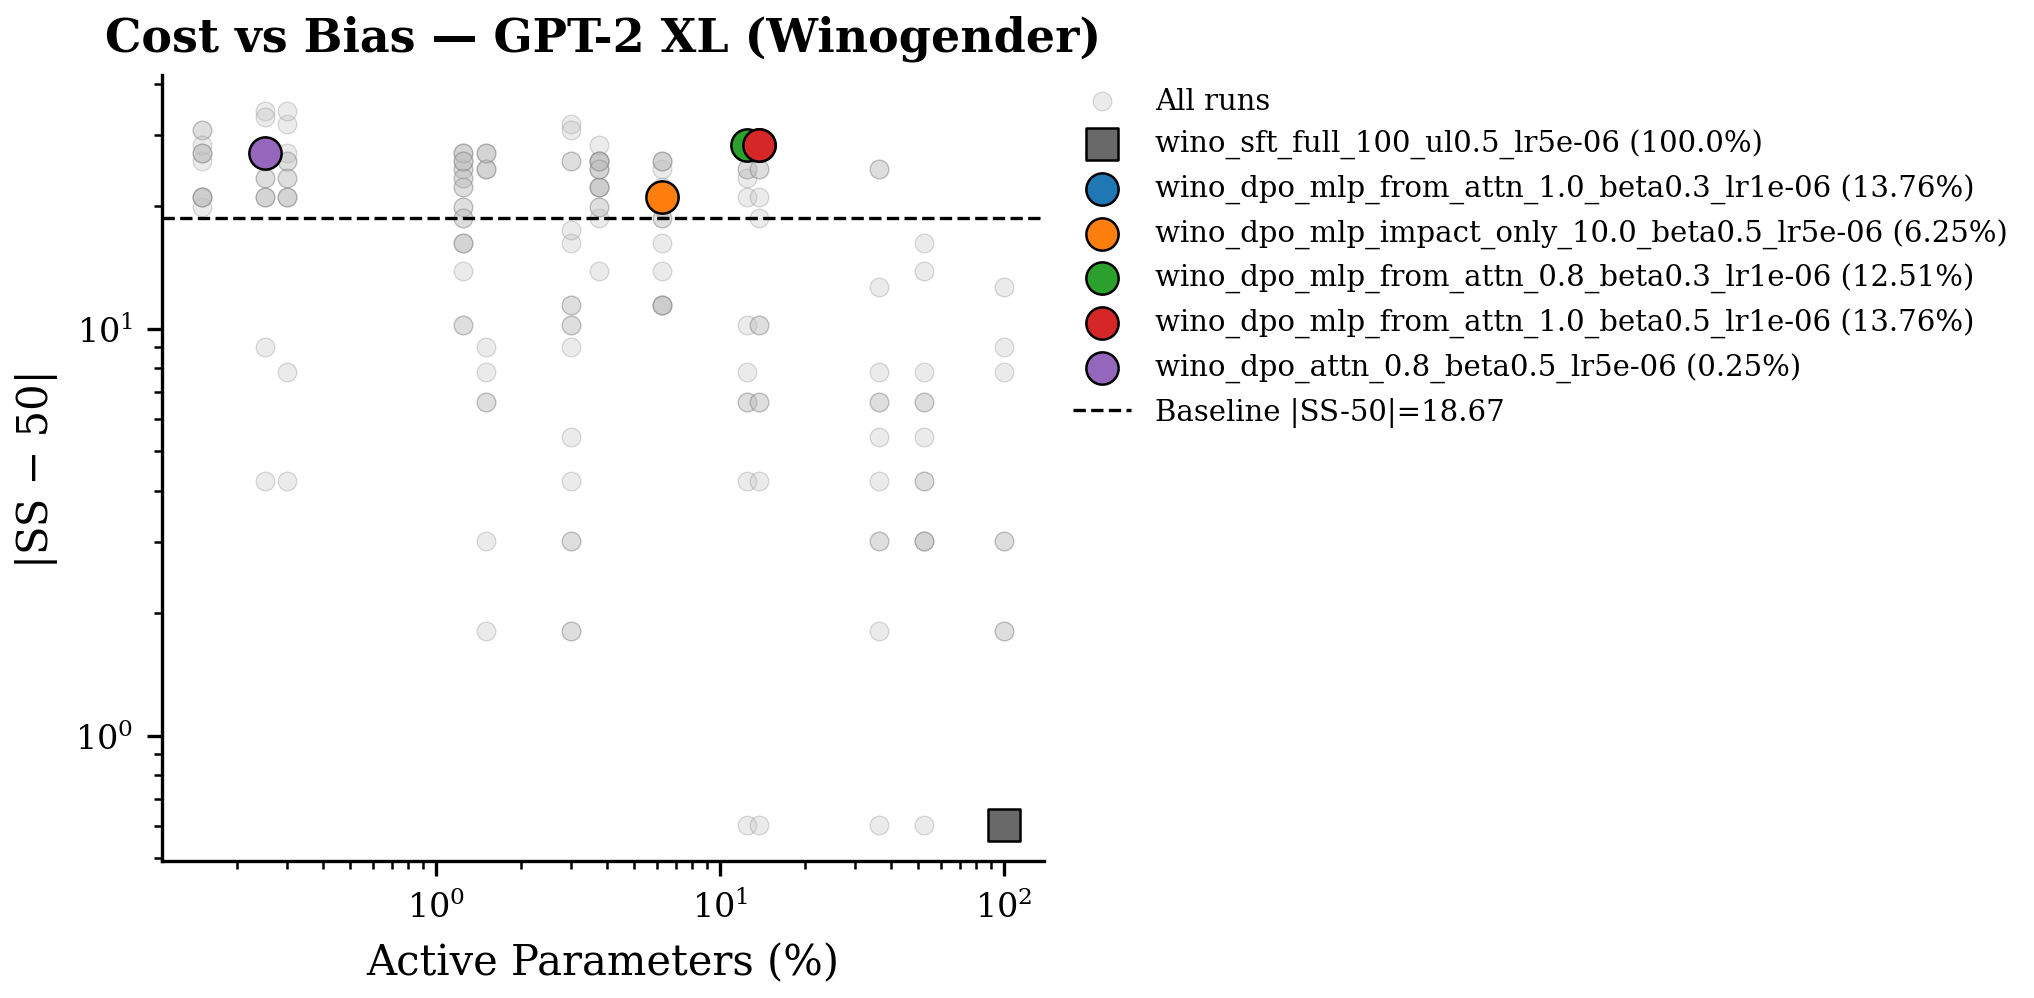

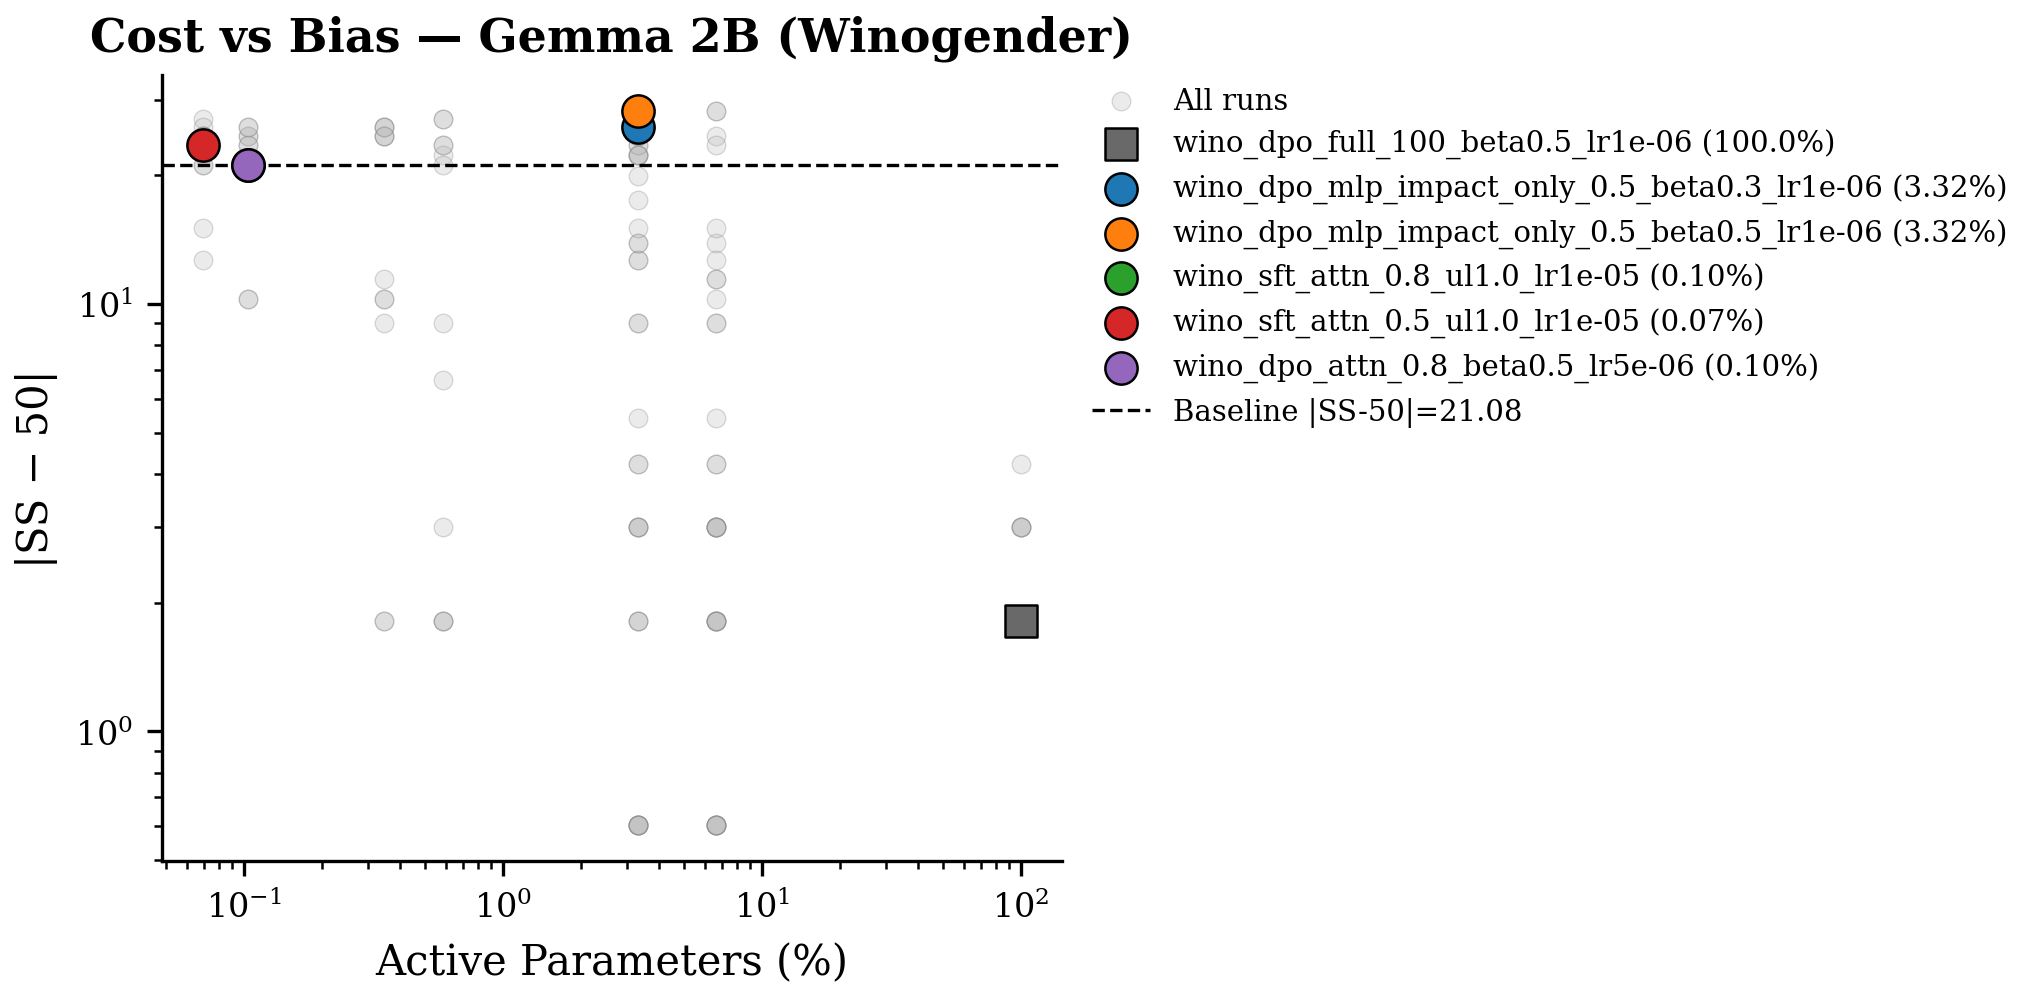

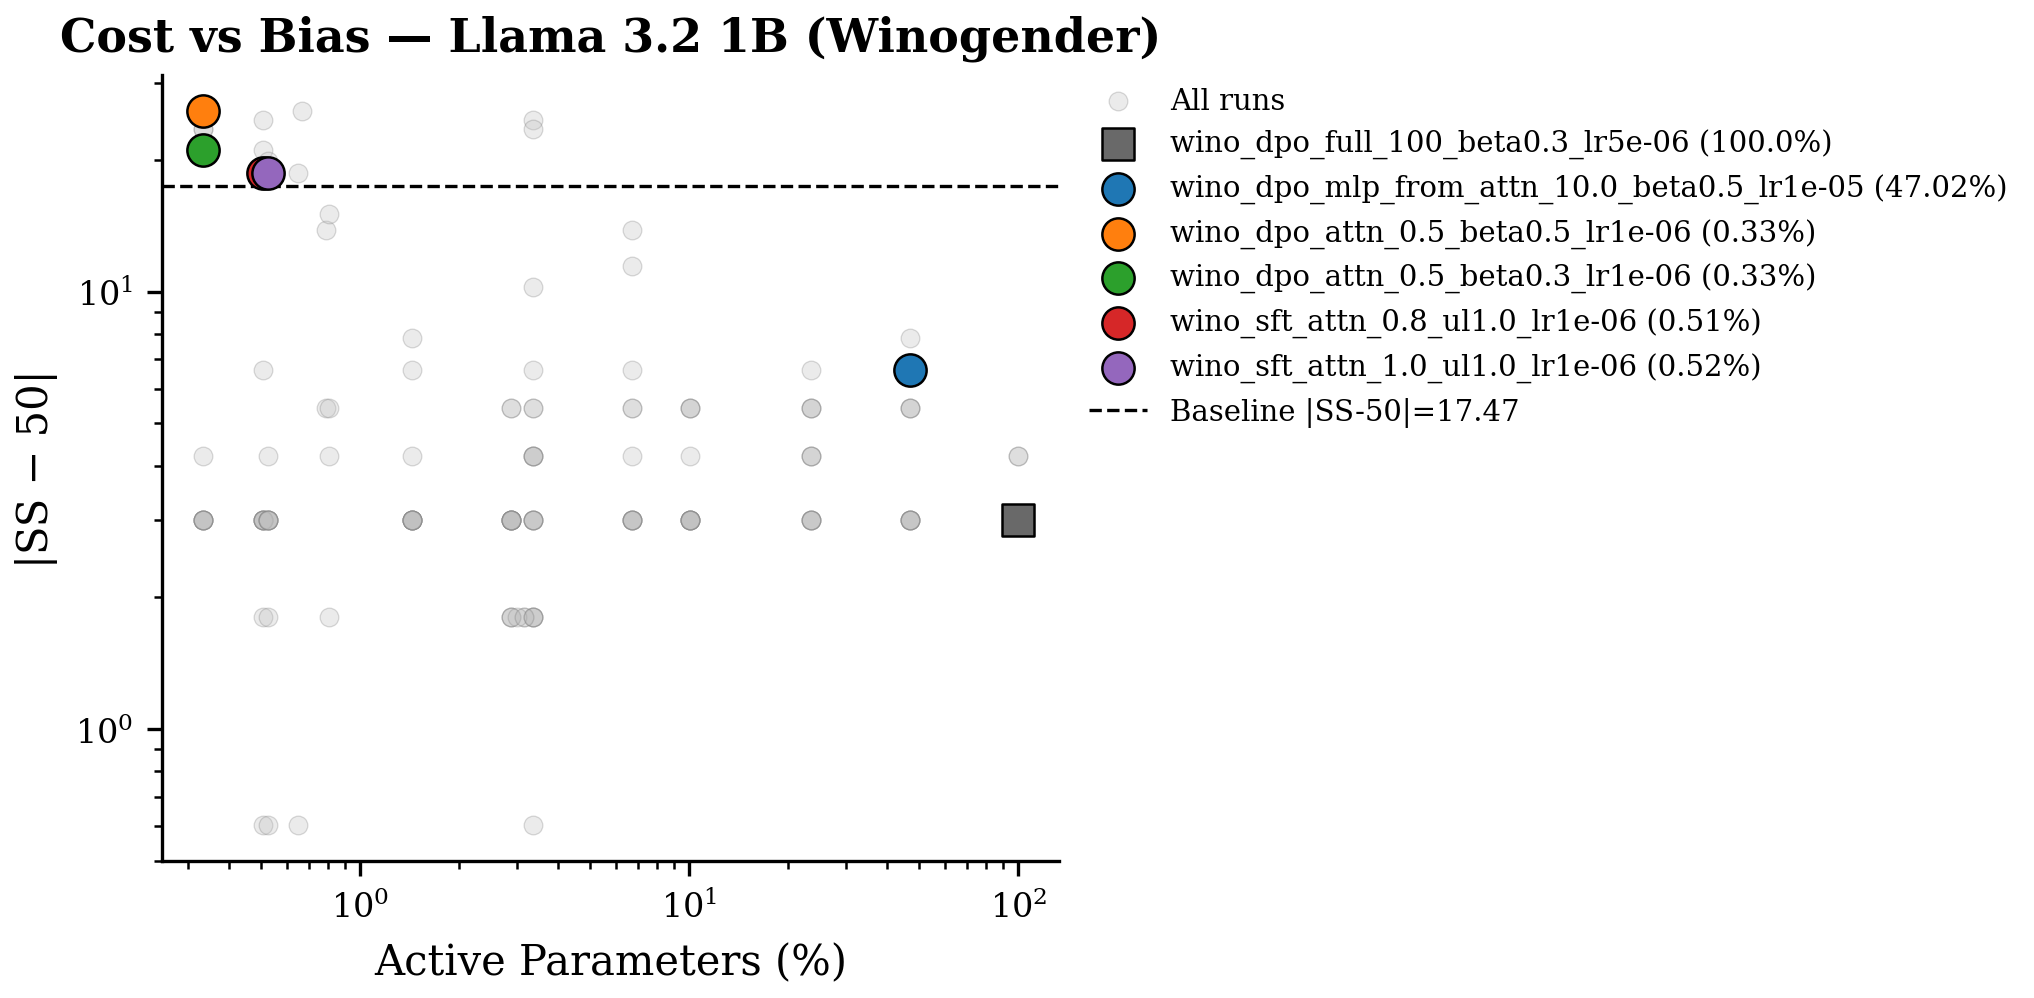

In [49]:
for model_name in model_names:
    sel = selections[model_name]
    mdf = all_data[model_name]["metrics"].copy()
    bm = all_data[model_name]["baseline_metrics"]
    dla_runs = sel["top5_dla"]
    best_full = sel["best_full"]
    safe_key = model_name.replace(" ", "_").replace(".", "")

    mdf["SS_deviation"] = np.abs(mdf["SS"] - 50)
    ft_df = mdf[(mdf["loss_type"] != "none") & (mdf["experiment_type"] != "baseline")].copy()

    fig, ax = plt.subplots(figsize=(7.0, 3.5))

    if not ft_df.empty:
        ax.scatter(ft_df["active_pct"], ft_df["SS_deviation"],
                   s=20, alpha=0.3, color="silver", edgecolors="gray",
                   linewidth=0.3, label="All runs")

    if not best_full.empty:
        r = best_full.iloc[0]
        pct = f"{r['active_pct']:.1f}" if pd.notna(r.get("active_pct")) else "100"
        ax.scatter(r["active_pct"], r["SS_deviation"],
                   s=60, marker="s", color=FULL_COLOR, edgecolors="black", linewidth=0.6,
                   zorder=5, label=f"{r['run_id']} ({pct}%)")

    for i, (_, r) in enumerate(dla_runs.iterrows()):
        ax.scatter(r["active_pct"], r["SS_deviation"],
                   s=60, marker="o", color=DLA_COLORS[i], edgecolors="black", linewidth=0.6,
                   zorder=5, label=f"{r['run_id']} ({r['active_pct']:.2f}%)")

    baseline_ss_dev = abs(bm["SS"] - 50)
    ax.axhline(baseline_ss_dev, color=BASELINE_COLOR, linewidth=0.8, linestyle="--",
               label=f"Baseline |SS-50|={baseline_ss_dev:.2f}")

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Active Parameters (%)")
    ax.set_ylabel("|SS − 50|")
    ax.set_title(f"Cost vs Bias — {model_name} (Winogender)", fontweight="bold")
    ax.legend(bbox_to_anchor=(1.02, 1.0), loc="upper left",
              borderaxespad=0, frameon=False, fontsize=7)
    sns.despine(ax=ax)

    plt.tight_layout()
    plt.show()

    FIGURES[f"cost_vs_bias_{safe_key}"] = fig

In [28]:
saved_paths = []

for fig_name, fig_obj in FIGURES.items():
    saved = False
    for model_name, cfg in MODELS.items():
        safe_key = model_name.replace(" ", "_").replace(".", "")
        if safe_key in fig_name:
            s3_path = f"outputs/{cfg['model_key']}/winogender/.plots/publication/{fig_name}.pdf"
            try:
                s3_utils.save_plot(fig_obj, s3_path)
                full_key = s3_utils.s3_key(s3_path)
                saved_paths.append(full_key)
                print(f"Saved: s3://{s3_utils.S3_BUCKET}/{full_key}")
            except Exception as e:
                print(f"Failed to save {s3_path}: {e}")
            saved = True
            break
    if not saved:
        cfg = list(MODELS.values())[0]
        s3_path = f"outputs/{cfg['model_key']}/winogender/.plots/publication/{fig_name}.pdf"
        try:
            s3_utils.save_plot(fig_obj, s3_path)
            full_key = s3_utils.s3_key(s3_path)
            saved_paths.append(full_key)
            print(f"Saved: s3://{s3_utils.S3_BUCKET}/{full_key}")
        except Exception as e:
            print(f"Failed to save {s3_path}: {e}")

print(f"\nTotal figures saved: {len(saved_paths)}")
for p in saved_paths:
    print(f"  s3://{s3_utils.S3_BUCKET}/{p}")

Saved: s3://modelsfinetuned/experiments/outputs/gpt2-xl/winogender/.plots/publication/layerwise_log_ratio_GPT-2_XL.pdf
Saved: s3://modelsfinetuned/experiments/outputs/gemma-2b/winogender/.plots/publication/layerwise_log_ratio_Gemma_2B.pdf
Saved: s3://modelsfinetuned/experiments/outputs/llama3.2_1b/winogender/.plots/publication/layerwise_log_ratio_Llama_32_1B.pdf
Saved: s3://modelsfinetuned/experiments/outputs/gpt2-xl/winogender/.plots/publication/layerwise_pgb_GPT-2_XL.pdf
Saved: s3://modelsfinetuned/experiments/outputs/gemma-2b/winogender/.plots/publication/layerwise_pgb_Gemma_2B.pdf
Saved: s3://modelsfinetuned/experiments/outputs/llama3.2_1b/winogender/.plots/publication/layerwise_pgb_Llama_32_1B.pdf
Saved: s3://modelsfinetuned/experiments/outputs/gpt2-xl/winogender/.plots/publication/dla_impact_wino_sft_mlp_from_attn_10.0_ul1.0_lr1e-05_GPT-2_XL.pdf
Saved: s3://modelsfinetuned/experiments/outputs/gpt2-xl/winogender/.plots/publication/dla_impact_wino_sft_full_100_ul0.5_lr5e-06_GPT-2_X